In [1]:
import numpy as np
import spacepy
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import joblib
import re
from scipy import stats
from scipy.stats import binned_statistic
from scipy.stats import pearsonr
from matplotlib.ticker import FuncFormatter
import spacepy.seapy as seapy
import scienceplots
from scipy.interpolate import interp1d
import random
import string
from math import sqrt
from scipy.stats import t

plt.style.use(['science','no-latex'])
plt.rc('font', size=18) 

C:\Users\firet\anaconda3\Lib\site-packages\spacepy\omni.py:418: UserWarning: Qin-Denton/OMNI2 data not found in current format. This module has limited functionality. Run spacepy.toolbox.update(QDomni=True) to download data.
  warnings.warn(


In [2]:
# Constants
m_proton = 1.673*1e-27 # kg
m_electron = m_proton/1836
q_proton = 1.602*1e-19 # A.s
mu_0 = 4*np.pi*1e-7 # H/A m
k_boltz = 1.3806*1e-23 # J/K
c0 = 3e8 #m/s
epsilon0 = 1./(mu_0*c0*c0)
amu_in_kg = 1.66053907e-27 # kg

B_0 = 3.12e-5 # mean value of the magnetic field at the magnetic equator on the Earth's surface
r_earth = 6378000 # radius of earth in meters

In [3]:
# Elemental mass in kg (neglecting ion variation since it should be roughly negligible)
H_in_kg = 1.00784 * amu_in_kg
He_in_kg = 4.002602 * amu_in_kg
O_in_kg = 15.999 * amu_in_kg
Fe_in_kg = 55.845 * amu_in_kg
C_in_kg = 12.011 * amu_in_kg
Ne_in_kg = 20.1797 * amu_in_kg
Mg_in_kg = 24.305 * amu_in_kg
Si_in_kg = 28.085 * amu_in_kg

In [4]:
# Loading in data
ace_data_1999_2005 = np.loadtxt('./Data/1999-2005/ACE_SWICS_Data_1999_2005.txt', skiprows=49) #beginning of 1999 - end of 2005

## Different indices
ICMEs = pd.read_csv('./Data/Compilation of ICMEs (UTF8).csv')

## Different indices
proton_info_1999_2005 = np.loadtxt('./Data/1999-2005/ACE_SWICS_Proton_Data_1999_2005.txt', skiprows=26) 

# SWICS Quality Flag Data
quality_1999_2005 = np.loadtxt('./Data/1999-2005/ACE_SWICS_Quality_Data_1999_2005.txt', skiprows=49) 

# OMNI Data (diff indices) - 1 hr time resolution
OMNI = np.loadtxt('./Data/OMNI/OMNI2_H0_MRG1HR_1999_2005.txt', skiprows = 83)

# OMNI 1 min time resolution
OMNI_1MIN = joblib.load('./Data/OMNI/OMNI_HRO2_1MIN_1999_2005.joblib') # DATAFRAME OBJECT
OMNI_AE_Index = joblib.load('./Data/OMNI/OMNI_AE_Index.joblib') # DATAFRAME OBJECT
OMNI_1MIN_updated = joblib.load('./Data/OMNI/OMNI_1MIN_updated.joblib') # DATAFRAME OBJECT

# MAG 16 second time resolution
MAG = joblib.load('./Data/MAG/MAG_updated/MAG_updated_1999_2005.joblib') # DATAFRAME OBJECT

## Different instrument/indices
SWEPAM = joblib.load('./Data/SWEPAM/SWEPAM_1999_2005.joblib') # DATAFRAME OBJECT - 64 second time resolution
SWEPAM_1hr_1999_2011 = np.loadtxt('./Data/SWEPAM/ACE_SWEPAM_Data_1998_2011.txt', skiprows = 31) # 1 hr time resolution
SWEPAM_1hr_1999_2005 = joblib.load('./Data/SWEPAM 1 HR/ACE_SWEPAM_1hr_1999_2005.joblib') # 1 hr time resolution

# SWICS & SWEPAM Merged Averaged Solar Wind Proton Parameters
SWICS_SWEPAM = np.loadtxt('./Data/SWICS & SWEPAM/ACE_SW_Data_1999_2005.txt', skiprows=35) # 12 min time res

# SWE
WI_H1_SWE = joblib.load('./Data/SWE/WI_H1_SWE/WI_H1_SWE_1999_2005.joblib') # DATAFRAME OBJECT - 92 second time resolution

In [5]:
def decimal_year_to_datetime(decimal_year):
    year = int(decimal_year)
    days_in_year = 366 if year % 4 == 0 else 365
    fractional_year = decimal_year - year
    day_of_year = int(fractional_year * days_in_year) 
    remaining_fraction = (fractional_year * days_in_year) - day_of_year
    total_seconds_in_day = 86400
    seconds = remaining_fraction * total_seconds_in_day
    date = datetime(year, 1, 1) + timedelta(days=day_of_year, seconds=seconds)
    return date

def datetime_to_decimal_year(dt):
    year = dt.year
    start_of_year = pd.Timestamp(f"{year}-01-01")
    end_of_year = pd.Timestamp(f"{year+1}-01-01")
    year_length = (end_of_year - start_of_year).total_seconds()
    seconds_since_start = (dt - start_of_year).total_seconds()
    return year + seconds_since_start / year_length

dates = [2001.29, 2001.302]
converted_dates = [decimal_year_to_datetime(date) for date in dates]
for date in converted_dates:
    print(date)

2001-04-16 20:23:59.999999
2001-04-21 05:31:11.999997


In [6]:
# Defining variables
He_bulk_vel = ace_data_1999_2005[:,2]; He_bulk_vel[np.where(np.abs(He_bulk_vel)>5e3)] = np.NaN # in km/s
Fe_avq = ace_data_1999_2005[:,3]

# Converting to m/s
He_bulk_vel = He_bulk_vel * 1000 # in m/s

# Converting to 1/m^3
He_dens = ace_data_1999_2005[:,1]; He_dens[np.where(np.abs(He_dens)>5e3)] = np.NaN;  # in 1/cm^3
He_dens = He_dens * 1e6
He_mass_dens = He_dens * He_in_kg

# SWICS 12-Minute Averaged Solar Wind Proton Parameters
proton_dens = proton_info_1999_2005[:,1]; proton_dens[np.where(np.abs(proton_dens)>5e3)] = np.NaN
proton_dens = proton_dens * 1e6 # Converting to 1/m^3
proton_mass_dens = proton_dens * H_in_kg
proton_velocity_1999_2005 = proton_info_1999_2005[:,2]; proton_velocity_1999_2005[np.where(np.abs(proton_velocity_1999_2005)>5e3)] = np.NaN
proton_velocity_1999_2005 = proton_velocity_1999_2005 * 1000 # in m/s

In [7]:
# Defining Variables
time_in_days = ace_data_1999_2005[:,0]

# Interpolating proton time scale onto heavy ion time scale (diff time resolution)
interpolated_proton_dens = np.interp(time_in_days, proton_info_1999_2005[:, 0], proton_dens)
interpolated_proton_mass_dens = np.interp(time_in_days, proton_info_1999_2005[:, 0], proton_mass_dens)
interpolated_proton_velocity = np.interp(time_in_days, proton_info_1999_2005[:, 0], proton_velocity_1999_2005)

# SWICS 1.1 2-Hour Averaged Solar Wind Parameters
Fe_to_O = ace_data_1999_2005[:,4]; Fe_to_O[np.where(np.abs(Fe_to_O)>5e3)] = np.NaN #removing outliers
He_to_O = ace_data_1999_2005[:,5]; He_to_O[np.where(np.abs(He_to_O)>5e3)] = np.NaN
C_to_O = ace_data_1999_2005[:,6]; C_to_O[np.where(np.abs(C_to_O)>5e3)] = np.NaN
Ne_to_O = ace_data_1999_2005[:,7]; Ne_to_O[np.where(np.abs(Ne_to_O)>5e3)] = np.NaN
Mg_to_O = ace_data_1999_2005[:,8]; Mg_to_O[np.where(np.abs(Mg_to_O)>5e3)] = np.NaN
Si_to_O = ace_data_1999_2005[:,9]; Si_to_O[np.where(np.abs(Si_to_O)>5e3)] = np.NaN

In [8]:
# Converting to Absolute Abundances, not Relative
O_dens = He_dens/He_to_O; O_mass_dens = O_dens * O_in_kg

Fe_dens = O_dens * Fe_to_O; Fe_mass_dens = Fe_dens * Fe_in_kg # First eq is num dens, second eq is mass dens
C_dens = O_dens * C_to_O; C_mass_dens = C_dens * C_in_kg
Ne_dens = O_dens * Ne_to_O; Ne_mass_dens = Ne_dens * Ne_in_kg
Mg_dens = O_dens * Mg_to_O; Mg_mass_dens = Mg_dens * Mg_in_kg
Si_dens = O_dens * Si_to_O; Si_mass_dens = Si_dens * Si_in_kg

heavy_elements_mass_dens = He_mass_dens + Fe_mass_dens + O_mass_dens + C_mass_dens + Ne_mass_dens + Mg_mass_dens + Si_mass_dens #including helium
heavy_elements_num_dens = He_dens + Fe_dens + O_dens + C_dens + Ne_dens + Mg_dens + Si_dens #including helium

# Defining dynamic pressure
proton_dyn_pressure = 0.5 * proton_mass_dens * proton_velocity_1999_2005**2 # kg/(m*s^2)
proton_dyn_pressure[np.where(np.abs(proton_dyn_pressure)>1e-7)] = np.NaN
interp_proton_dyn_pressure = 0.5 * interpolated_proton_mass_dens * interpolated_proton_velocity**2
He_dyn_pressure = 0.5 * He_mass_dens * He_bulk_vel**2
Fe_dyn_pressure = 0.5 * Fe_mass_dens * He_bulk_vel**2 
O_dyn_pressure = 0.5 * O_mass_dens * He_bulk_vel**2
C_dyn_pressure = 0.5 * C_mass_dens * He_bulk_vel**2
Ne_dyn_pressure = 0.5 * Ne_mass_dens * He_bulk_vel**2
Mg_dyn_pressure = 0.5 * Mg_mass_dens * He_bulk_vel**2
Si_dyn_pressure = 0.5 * Si_mass_dens * He_bulk_vel**2

heavy_elements_dyn_pressure = He_dyn_pressure + Fe_dyn_pressure + O_dyn_pressure + C_dyn_pressure + Ne_dyn_pressure + Mg_dyn_pressure + Si_dyn_pressure
all_elements_dyn_pressure = interp_proton_dyn_pressure + heavy_elements_dyn_pressure

In [9]:
# SWEPAM Data
SWEPAM_proton_temp = SWEPAM['proton_temp']
SWEPAM_he_proton = SWEPAM['He4toprotons'] # Ratio of Alpha Density to proton Density (nHe/nP)

SWEPAM_proton_temp = SWEPAM_proton_temp.where(SWEPAM_proton_temp > 0, np.NaN)
SWEPAM_he_proton = SWEPAM_he_proton.where(np.abs(SWEPAM_he_proton) <= 5e3, np.NaN)

SWEPAM_1hr_1999_2011_he_proton = SWEPAM_1hr_1999_2011[:,2]; SWEPAM_1hr_1999_2011_he_proton[np.where(np.abs(SWEPAM_1hr_1999_2011_he_proton)>5e3)] = np.NaN;

# SWEPAM 1 HR V_r, V_t, V_n, V_total
SWEPAM_decimal_year = SWEPAM_1hr_1999_2005['fp_year'] 
SWEPAM_V_total = SWEPAM_1hr_1999_2005['proton_speed'] # proton speed in km/s
SWEPAM_V_r = SWEPAM_1hr_1999_2005['x_dot_RTN'] # R-component of proton velocity in RTN coordinates (km/s)
SWEPAM_V_t = SWEPAM_1hr_1999_2005['y_dot_RTN'] # T-component of proton velocity in RTN coordinates (km/s)
SWEPAM_V_n = SWEPAM_1hr_1999_2005['z_dot_RTN'] # N-component of proton velocity in RTN coordinates (km/s)

SWEPAM_R_total_frac = np.abs(SWEPAM_V_r / SWEPAM_V_total)
SWEPAM_T_total_frac = np.abs(SWEPAM_V_t / SWEPAM_V_total)
SWEPAM_N_total_frac = np.abs(SWEPAM_V_n / SWEPAM_V_total)

# SWICS/SWEPAM
SWICS_SWEPAM_he_proton = SWICS_SWEPAM[:,3]; SWICS_SWEPAM_he_proton[np.where(np.abs(SWICS_SWEPAM_he_proton)>5e3)] = np.NaN;

In [10]:
# Converting OMNI into dataframe and defining variables

# Function to determine if a year is a leap year
def is_leap_year(year):
    return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

# Function to get the number of seconds in a given year
def seconds_in_year(year):
    if is_leap_year(year):
        return 366 * 24 * 60 * 60  # Leap year
    else:
        return 365 * 24 * 60 * 60  # Regular year

# Extract the relevant columns
OMNI_date = OMNI[:, 0].astype(int)
OMNI_seconds = OMNI[:, 1]
OMNI_B_avg_mag = OMNI[:, 2] * 1e-9  # Converting from nT to T
OMNI_temp = OMNI[:, 3]  # in Kelvin
OMNI_num_dens = OMNI[:, 4] * 1e6  # Converting to 1/m^3
OMNI_vel = OMNI[:, 5] * 1000  # Converting to m/s
OMNI_he_proton = OMNI[:, 6]  # Alpha/proton ratio
OMNI_flow_pressure = OMNI[:, 7]  # in nPa
OMNI_electric_field = OMNI[:, 8]  # in mV/m
OMNI_sunspot = OMNI[:, 9]
OMNI_Dst = OMNI[:, 10]
OMNI_mag_divide_kinetic = OMNI[:, 11]

# Filtering error values
OMNI_B_avg_mag[np.abs(OMNI_B_avg_mag) > 0.8e-5] = np.NaN
OMNI_temp[np.abs(OMNI_temp) > 0.8e7] = np.NaN
OMNI_num_dens[np.abs(OMNI_num_dens) > 0.8e10] = np.NaN
OMNI_vel[np.abs(OMNI_vel) > 0.8e7] = np.NaN
OMNI_he_proton[np.abs(OMNI_he_proton) > 8] = np.NaN
OMNI_flow_pressure[np.abs(OMNI_flow_pressure) > 90] = np.NaN
OMNI_electric_field[np.abs(OMNI_electric_field) > 800] = np.NaN
OMNI_mag_divide_kinetic[np.abs(OMNI_mag_divide_kinetic) > 8] = np.NaN

# Create a DataFrame
df_OMNI = pd.DataFrame({
    'Year': OMNI_date,
    'Secs-of-year': OMNI_seconds,
    '1AU_IP_MAG_AVG_B': OMNI_B_avg_mag, # Average B Field Magnitude
    '1AU_IP_PLASMA_TEMP': OMNI_temp,
    '1AU_IP_N_(ION)': OMNI_num_dens,
    '1AU_IP_PLASMA_SPEED': OMNI_vel, # flow velocity
    '1AU_IP_ALPHA/PROTON': OMNI_he_proton, # Alpha/Proton ratio
    '1AU_IP_FLOW_PRESSURE': OMNI_flow_pressure,
    '1AU_IP_ELECTRIC_FIELD': OMNI_electric_field,
    'DAILY_SUNSPOT_NO': OMNI_sunspot,
    '1-H_DST': OMNI_Dst,
    'PROTON_QI': OMNI_mag_divide_kinetic #(magnetic energy density)/(kinetic energy density)
})

# Calculate the decimal year
df_OMNI['Seconds_in_Year'] = df_OMNI['Year'].apply(seconds_in_year)
df_OMNI['Decimal_Year'] = df_OMNI['Year'] + df_OMNI['Secs-of-year'] / df_OMNI['Seconds_in_Year']

# Drop the 'Seconds_in_Year' column as it is no longer needed
df_OMNI = df_OMNI.drop(columns=['Seconds_in_Year'])

# Display the first few rows of the updated DataFrame
# print(df_OMNI.head())

In [11]:
# Calculate the decimal year
OMNI_1MIN_updated['Seconds_in_Year'] = OMNI_1MIN_updated['Year'].apply(seconds_in_year)
OMNI_1MIN_updated['Decimal_Year'] = OMNI_1MIN_updated['Year'] + OMNI_1MIN_updated['Secs-of-year'] / OMNI_1MIN_updated['Seconds_in_Year']

# Defining OMNI AE variables

# Extract the relevant columns
OMNI_1MIN_AE_date = OMNI_AE_Index['EPOCH']
OMNI_1MIN_AE = OMNI_AE_Index['1-M_AE'] 

# Filter out values where 'AE' is less than 10000
OMNI_AE_Index = OMNI_AE_Index.loc[OMNI_AE_Index['1-M_AE'] < 10000]

# Calculate the decimal year
OMNI_AE_Index['Seconds_in_Year'] = OMNI_AE_Index['Year'].apply(seconds_in_year)
OMNI_AE_Index['Decimal_Year'] = OMNI_AE_Index['Year'] + OMNI_AE_Index['Secs-of-year'] / OMNI_AE_Index['Seconds_in_Year']

# print(OMNI_AE_Index)

# Display the first few rows of the updated DataFrame
# print(OMNI_1MIN_updated)

In [12]:
# Defining MAG variables
MAG_Br = MAG['Br'] * 1e-9 # Converting from nT to T
MAG_Bmag = MAG['Bmag'] * 1e-9 # Converting from nT to T
MAG_Bgse_z = MAG['Bgse_z'] * 1e-9 # Converting from nT to T - GSE coords
MAG_Bgsm_z = MAG['Bgsm_z'] * 1e-9 # Converting from nT to T - GSM coords

MAG_Br[np.abs(MAG_Br) > 800e-9] = np.NaN
MAG_Bmag[MAG_Bmag < 0] = np.NaN
MAG_Bgse_z[np.abs(MAG_Bgse_z) > 800e-9] = np.NaN
MAG_Bgsm_z[np.abs(MAG_Bgsm_z) > 800e-9] = np.NaN

In [13]:
# Defining WI_H1_SWE variables
WI_H1_SWE_proton_vel = WI_H1_SWE['PROTON_BULK_SPEED'] # Obtained from non-linear fitting to the ion current distribution function (CDF).
WI_H1_SWE_proton_dens = WI_H1_SWE['P+_DENSITY'] # Obtained from non-linear fitting to the ion current distribution function (CDF).
WI_H1_SWE_he_vel = WI_H1_SWE['ALPHA_BULK_SPEED'] # Obtained from non-linear fitting to the ion current distribution function (CDF).
WI_H1_SWE_he_dens = WI_H1_SWE['HE++_DENSITY_NONLIN'] # Obtained from non-linear fitting to the ion current distribution function (CDF).

# Filtering error values
WI_H1_SWE_proton_vel = WI_H1_SWE_proton_vel.where(np.abs(WI_H1_SWE_proton_vel) < 1e4, np.NaN)
WI_H1_SWE_proton_dens = WI_H1_SWE_proton_dens.where(np.abs(WI_H1_SWE_proton_dens) < 1e3, np.NaN)
WI_H1_SWE_he_vel = WI_H1_SWE_he_vel.where(np.abs(WI_H1_SWE_he_vel) < 1e4, np.NaN)
WI_H1_SWE_he_dens = WI_H1_SWE_he_dens.where(np.abs(WI_H1_SWE_he_dens) < 1e3, np.NaN)

WI_H1_SWE_proton_vel = WI_H1_SWE_proton_vel * 1000 # Converting from km/s to m/s
WI_H1_SWE_proton_dens = WI_H1_SWE_proton_dens * 1e6 # Converting from 1/cm^3 to 1/m^3
WI_H1_SWE_he_vel = WI_H1_SWE_he_vel * 1000 # Converting from km/s to m/s
WI_H1_SWE_he_dens = WI_H1_SWE_he_dens * 1e6 # Converting from 1/cm^3 to 1/m^3

WI_H1_SWE_proton_dyn_pressure = 0.5 * WI_H1_SWE_proton_dens * H_in_kg * WI_H1_SWE_proton_vel**2
WI_H1_SWE_he_dyn_pressure = 0.5 * WI_H1_SWE_he_dens * He_in_kg * WI_H1_SWE_he_vel**2

In [14]:
# SWE conversions
WI_H1_SWE['datetime'] = pd.to_datetime(WI_H1_SWE['EPOCH'], format='%m:%d:%Y %H:%M:%S')
WI_H1_SWE.set_index('datetime', inplace=True, drop=False)

# Filter out extreme values
WI_H1_SWE_filtered = WI_H1_SWE[WI_H1_SWE['HE++_DENSITY_NONLIN'] < 100]
WI_H1_SWE_filtered1 = WI_H1_SWE[WI_H1_SWE['ALPHA_BULK_SPEED'] < 1000]

# Compute the 2-hour average
SWE_he_dens_2hr_avg = WI_H1_SWE_filtered['HE++_DENSITY_NONLIN'].resample('2h').mean() # in 1/cm^3
SWE_he_vel_2hr_avg = WI_H1_SWE_filtered1['ALPHA_BULK_SPEED'].resample('2h').mean()

# ACE conversions
ACE_datetime = [decimal_year_to_datetime(dy) for dy in ace_data_1999_2005[:, 0]]

ACE_df = pd.DataFrame({
    'He_dens': ace_data_1999_2005[:,1],
    'He_vel': ace_data_1999_2005[:,2],
}, index=ACE_datetime)

ACE_2hr_avg = ACE_df.resample('2h').mean() # TECHNICALLY ACE DATA NOT PERFECTLY IN SYNC WITH SWE (around 40 minutes off)

combined_df = pd.concat([
    SWE_he_dens_2hr_avg.rename('wind_dens'),
    SWE_he_vel_2hr_avg.rename('wind_vel'),
    ACE_2hr_avg['He_dens'].rename('ace_dens'),
    ACE_2hr_avg['He_vel'].rename('ace_vel')
], axis=1)

# Drop rows with missing data
combined_df.dropna(inplace=True)

# Compute ACE/WIND alpha density ratio
combined_df['dens_ratio'] = combined_df['ace_dens'] / combined_df['wind_dens']

# Filter out extreme values
combined_df = combined_df[
    (combined_df['ace_vel'] >= 300) & (combined_df['ace_vel'] <= 800) &
    (combined_df['wind_vel'] >= 300) & (combined_df['wind_vel'] <= 800) &
    (combined_df['dens_ratio'] > 0)    & (combined_df['dens_ratio'] < 1.5)
]

# Apply to index
combined_df['decimal_year'] = [datetime_to_decimal_year(ts) for ts in combined_df.index]
ACE_SWE_alpha_dens_ratio = combined_df['dens_ratio'].values
ACE_SWE_alpha_dens_ratio_decimal_years = combined_df['decimal_year'].reset_index(drop=True)

# print(combined_df)

In [15]:
### Finding dates/indices of only INTENSE (Dst < -100) recorded ICMEs from 1999-2005 ###

# Convert the Dst column to numeric, converting non-numeric values to NaN
ICMEs['Dst (nT) (m)'] = pd.to_numeric(ICMEs['Dst (nT) (m)'], errors='coerce')

Dst = ICMEs['Dst (nT) (m)'] # some values of Dst (esp after 2017 will not be included due to the formatting... will need to fix later)

# Identify intense storms
intense_storm = Dst <= -100 # in nT

# Extract datetime strings for intense storms
intense_storm_dates = ICMEs[intense_storm]['Disturbance Y/M/D (UT) (a)']
intense_storm_indices = ICMEs[intense_storm].index

# Define a reference date
reference_date = datetime(1999, 1, 1)

# Function to clean and parse datetime strings
def parse_date(date_str):
    try:
        # Ensure date_str is a string
        if not isinstance(date_str, str):
            date_str = str(date_str)
        # Remove annotations and parentheses
        clean_date_str = date_str.split('(')[0].strip()
        # Parse the cleaned date string
        return datetime.strptime(clean_date_str, '%Y/%m/%d %H%M')
    except ValueError:
        # Handle the exception for invalid date strings
        # print(f"Skipping invalid date string: {date_str}")
        return None

# Convert datetime strings to days (float) since reference_date and get indices
intense_storm_days_1999_2005 = []
intense_storm_indices_1999_2005 = []

for date_str, index in zip(intense_storm_dates, intense_storm_indices):
    date_obj = parse_date(date_str)
    if date_obj is None:
        continue
    days_since_start = (date_obj - reference_date).days + (date_obj - reference_date).seconds / 86400.0
    
    if 0 < days_since_start < 2564:  # includes dates from 1999 to 2005
        intense_storm_days_1999_2005.append(days_since_start)
        intense_storm_indices_1999_2005.append(index)

# Adjust days for leap years and convert to fractional years
adjusted_intense_days = []
for days in intense_storm_days_1999_2005:
    current_date = reference_date + timedelta(days=days)
    year = current_date.year
    days_in_year = 366 if is_leap_year(year) else 365
    start_of_year = datetime(year, 1, 1)
    day_of_year = (current_date - start_of_year).days + (current_date - start_of_year).seconds / 86400.0
    adjusted_day = year + day_of_year / days_in_year
    adjusted_intense_days.append(adjusted_day)

print('Intense storm days from 1999 to 2005:', *[f"{day:.6f}" for day in adjusted_intense_days])
print('Indices of intense storm days from 1999 to 2005: ' + str(intense_storm_indices_1999_2005)) #these index values not the same indices of density/vel arrays

Intense storm days from 1999 to 2005: 1999.034121 1999.131823 1999.724699 1999.803016 1999.867123 2000.114739 2000.264191 2000.393408 2000.537183 2000.607128 2000.611424 2000.712312 2000.754201 2000.759954 2000.781246 2000.823531 2000.848110 2000.907730 2001.212241 2001.243935 2001.275538 2001.293238 2001.303198 2001.625919 2001.747420 2001.750371 2001.752055 2001.804658 2001.822296 2001.831712 2001.846788 2001.896682 2002.223244 2002.291680 2002.296870 2002.357333 2002.390278 2002.583465 2002.629540 2002.684087 2002.746147 2002.753215 2003.407582 2003.456849 2003.626296 2003.825363 2003.829260 2003.885850 2004.057561 2004.255123 2004.560817 2004.568171 2004.659512 2004.851827 2004.857288 2005.367424 2005.406606 2005.444720 2005.644545 2005.693291
Indices of intense storm days from 1999 to 2005: [66, 71, 90, 91, 93, 101, 107, 116, 129, 134, 135, 138, 139, 140, 141, 142, 143, 147, 153, 156, 160, 163, 164, 177, 184, 185, 186, 189, 191, 192, 194, 196, 203, 205, 206, 207, 209, 214, 215, 21

In [16]:
# Magnetopause standoff distance equation
def L_mp_equation(total_dens, vel): 
    top_frac = 4 * B_0**2
    bot_frac = mu_0 * total_dens * vel**2
    L_mp = (top_frac/bot_frac)**(1/6)
    return L_mp

def L_mp_equation_dyn_pressure(dyn_pressure): 
    top_frac = 4 * B_0**2
    bot_frac = mu_0 * 2 * dyn_pressure
    L_mp = (top_frac/bot_frac)**(1/6)
    return L_mp

In [17]:
df_heavy_elements = pd.DataFrame(ace_data_1999_2005)
df_proton = pd.DataFrame(proton_info_1999_2005)
df_proton_interp = pd.DataFrame(interp_proton_dyn_pressure)

# Create the DataFrame with the proton dynamic pressure values without changing the index
df_proton_interp = pd.DataFrame({
    "Time (Days)": time_in_days,
    "interp_proton_dyn_pressure": interp_proton_dyn_pressure
})

def find_closest(value, array):
    idx = np.abs(np.asarray(array) - value).argmin()
    return array[idx], idx

closest_values_heavy_elements = [find_closest(day, df_heavy_elements.iloc[:,0]) for day in adjusted_intense_days]
# print('Closest values (heavy elements) to intense storm days in 2005 (with indices):', closest_values_heavy_elements)

closest_values_proton = [find_closest(day, df_proton.iloc[:,0]) for day in adjusted_intense_days]
# print('Closest values (proton) to intense storm days in 2005 (with indices):', closest_values_proton)

In [18]:
# Finding dates/indices of ALL recorded ICMEs from 1999-2005

# Extract datetime strings for all ICMEs
ICMEs_dates = ICMEs['Disturbance Y/M/D (UT) (a)']
ICMEs_indices = ICMEs.index

# Define a reference date
reference_date = datetime(1999, 1, 1)

# Convert datetime strings to days (float) since reference_date and get indices
ICMEs_days_1999_2005 = []
ICMEs_indices_1999_2005 = []

for date_str, index in zip(ICMEs_dates, ICMEs_indices):
    date_obj = parse_date(date_str)
    if date_obj:
        days_since_start = (date_obj - reference_date).days + (date_obj - reference_date).seconds / 86400
        
        # Check if the date is within the range from 1999 to 2005
        if 0 <= (date_obj - reference_date).days < 2564:
            ICMEs_days_1999_2005.append(days_since_start)
            ICMEs_indices_1999_2005.append(index)

# Adjust days for leap years and convert to fractional years
adjusted_days_1999_2005 = []
for days in ICMEs_days_1999_2005:
    current_date = reference_date + timedelta(days=days)
    year = current_date.year
    days_in_year = 366 if is_leap_year(year) else 365
    start_of_year = datetime(year, 1, 1)
    day_of_year = (current_date - start_of_year).days + (current_date - start_of_year).seconds / 86400 
    adjusted_day = year + day_of_year / days_in_year
    adjusted_days_1999_2005.append(adjusted_day)

# print('ICMEs days from 1999 to 2005:', *[f"{day:.6f}" for day in adjusted_days_1999_2005])
# print('Indices of ICMEs from 1999 to 2005: ' + str(ICMEs_indices_1999_2005))

In [19]:
# Finding dates/indices of ALL recorded ICMEs from 1999-2005

# Extract datetime strings for all ICMEs
ICMEs_dates = ICMEs['Disturbance Y/M/D (UT) (a)']
ICMEs_plasma_start = ICMEs['ICME Plasma/Field Start, End Y/M/D (UT) (b)']
ICMEs_plasma_end = ICMEs['ICME Plasma/Field End']
ICMEs_indices = ICMEs.index

# Define a reference date
reference_date = datetime(1999, 1, 1)

# Convert datetime strings to days (float) since reference_date and get indices
ICMEs_days_1999_2005 = []
ICMEs_plasma_start_1999_2005 = []
ICMEs_plasma_end_1999_2005 = []
ICMEs_indices_1999_2005 = []

# Iterate through the rows and filter the dates
for index, date_str in zip(ICMEs_indices, ICMEs_dates):
    date_obj = parse_date(date_str)
    plasma_start_obj = parse_date(ICMEs_plasma_start[index])
    plasma_end_obj = parse_date(ICMEs_plasma_end[index])

    if date_obj and plasma_start_obj and plasma_end_obj:
        days_since_start = (date_obj - reference_date).days + (date_obj - reference_date).seconds / 86400
        plasma_start_days = (plasma_start_obj - reference_date).days + (plasma_start_obj - reference_date).seconds / 86400
        plasma_end_days = (plasma_end_obj - reference_date).days + (plasma_end_obj - reference_date).seconds / 86400

        # Check if the date is within the range from 1999 to 2005
        if 0 <= (date_obj - reference_date).days < 2564:
            ICMEs_days_1999_2005.append(days_since_start)
            ICMEs_plasma_start_1999_2005.append(plasma_start_days)
            ICMEs_plasma_end_1999_2005.append(plasma_end_days)
            ICMEs_indices_1999_2005.append(index)

# Adjust days for leap years and convert to fractional years
def adjust_days(days):
    current_date = reference_date + timedelta(days=days)
    year = current_date.year
    days_in_year = 366 if is_leap_year(year) else 365
    start_of_year = datetime(year, 1, 1)
    day_of_year = (current_date - start_of_year).days + (current_date - start_of_year).seconds / 86400 
    return year + day_of_year / days_in_year #+ 12*0.000114 # ADD THIS NUMBER TO DO TIME DELAY ANALYSIS

adjusted_days_1999_2005 = [adjust_days(days) for days in ICMEs_days_1999_2005]
adjusted_plasma_start_1999_2005 = [adjust_days(days) for days in ICMEs_plasma_start_1999_2005]
adjusted_plasma_end_1999_2005 = [adjust_days(days) for days in ICMEs_plasma_end_1999_2005]

# print('ICMEs days from 1999 to 2005:', *[f"{day:.6f}" for day in adjusted_days_1999_2005])
# print('ICME Plasma Start days from 1999 to 2005:', *[f"{day:.6f}" for day in adjusted_plasma_start_1999_2005])
# print('ICME Plasma End days from 1999 to 2005:', *[f"{day:.6f}" for day in adjusted_plasma_end_1999_2005])
# print('Indices of ICMEs from 1999 to 2005: ' + str(ICMEs_indices_1999_2005))

print(len(adjusted_days_1999_2005))

232


In [20]:
def find_min_dst_within_icme(Dst, ICMEs, adjusted_days_1999_2005, adjusted_plasma_end_1999_2005, ICMEs_indices_1999_2005, ICMEs_dates):
    Dst_mismatch_dates = []
    min_Dst_mismatch_values = []
    min_Dst_mismatch_dates = []
    min_Dst_values = []
    min_Dst_dates = []

    for start_day, end_day, index in zip(adjusted_days_1999_2005, adjusted_plasma_end_1999_2005, ICMEs_indices_1999_2005):
        Dst_filtered = df_OMNI[
            (df_OMNI['Decimal_Year'] >= start_day) &
            (df_OMNI['Decimal_Year'] <= end_day + 0.000114)] # including 1 hr after plasma_end since min value of Dst may be generated by storm trailing edge
        min_Dst_value = Dst_filtered['1-H_DST'].min()
        min_Dst_date = Dst_filtered[Dst_filtered['1-H_DST'] == min_Dst_value]['Decimal_Year'].values[0]

        Richardson_Dst_value = ICMEs['Dst (nT) (m)'][index]
        
        min_Dst_values.append(min_Dst_value)
        min_Dst_dates.append(min_Dst_date)

        if abs(min_Dst_value - Richardson_Dst_value) > 5:
            Dst_mismatch_dates.append(ICMEs_dates[index])
            min_Dst_mismatch_values.append(min_Dst_value)
            min_Dst_mismatch_dates.append(min_Dst_date)
            # print(f"Disturbance Date: {ICMEs_dates[index]}")
            # print(f"Richardson Dst Value: {Richardson_Dst_value}")
            # print(f"OMNI Min Dst Value: {min_Dst_value}")
            # print(f"Date of Actual Min Dst: {min_Dst_date}\n")

    # Find dates with no mismatch
    min_Dst_dates_no_mismatch = [date for date in min_Dst_dates if date not in min_Dst_mismatch_dates]

    return Dst_mismatch_dates, min_Dst_values, min_Dst_dates, min_Dst_mismatch_values, min_Dst_mismatch_dates, min_Dst_dates_no_mismatch

Dst_mismatch_dates, min_Dst_values, min_Dst_dates, min_Dst_mismatch_values, min_Dst_mismatch_dates, min_Dst_dates_no_mismatch = find_min_dst_within_icme(Dst, ICMEs, adjusted_days_1999_2005, adjusted_plasma_end_1999_2005, ICMEs_indices_1999_2005, ICMEs_dates)

# Print the results
print("Length of Dst_mismatch_dates:", len(Dst_mismatch_dates))
print("Length of min_Dst_dates:", len(min_Dst_dates))
print("Length of min_Dst_dates_no_mismatch:", len(min_Dst_dates_no_mismatch))

## The reason lengths are different is because some min Dst dates are duplicates

Length of Dst_mismatch_dates: 19
Length of min_Dst_dates: 232
Length of min_Dst_dates_no_mismatch: 208


In [21]:
# Finding closests days/indices for ALL ICME Disturbances 1999 - 2005
closest_values_heavy_elements = [find_closest(day, df_heavy_elements.iloc[:,0]) for day in adjusted_days_1999_2005]
# print('Closest values (heavy elements) to ICMEs days from 1999 to 2005 (with indices):', closest_values_heavy_elements)

closest_values_proton = [find_closest(day, df_proton.iloc[:,0]) for day in adjusted_days_1999_2005]
# print('Closest values (proton) to ICMEs days from 1999 to 2005 (with indices):', closest_values_proton)

closest_values_MAG = [find_closest(day, MAG.iloc[:,0]) for day in adjusted_days_1999_2005]

# Defining indices of the ICMEs with respect to each dataset
closest_values_heavy_elements_indices = [pair[1] for pair in closest_values_heavy_elements]
closest_values_proton_indices = [pair[1] for pair in closest_values_proton]
closest_values_MAG_indices = [pair[1] for pair in closest_values_MAG]

# Finding closests days/indices for ALL ICME Plasma End 1999 - 2005
closest_values_heavy_elements_plasma_end = [find_closest(day, df_heavy_elements.iloc[:,0]) for day in adjusted_plasma_end_1999_2005]
closest_values_heavy_elements_plasma_end_indices = [pair[1] for pair in closest_values_heavy_elements_plasma_end]

# print(closest_values_heavy_elements_indices)
# print(closest_values_heavy_elements_plasma_end)

In [22]:
def calculate_10hr_window_average_and_check(values, indices, time_range=10):
    averages = []
    below_zero_50pct = []

    # Calculate the number of data points for 10 hours
    # Assuming the data is in minutes, 10 hours = 10 * 60 minutes
    num_points_10hr = int(time_range * 60 * 4) 

    for index in indices:
        start_index = max(0, index)
        end_index = min(len(values), index + num_points_10hr)
        window_values = values[start_index:end_index]

        if len(window_values) > 0:
            avg_value = np.mean(window_values)
            averages.append(avg_value)

            below_zero_count = np.sum(window_values < 0)
            below_zero_50pct.append(below_zero_count >= 0.5 * len(window_values))
        else:
            averages.append(np.nan)
            below_zero_50pct.append(False)

    return averages, below_zero_50pct

# Calculate the averages and check for below zero values
MAG_Bgse_z_avg, MAG_Bgse_z_below_zero_50pct = calculate_10hr_window_average_and_check(MAG_Bgse_z, closest_values_MAG_indices)
MAG_Bgsm_z_avg, MAG_Bgsm_z_below_zero_50pct = calculate_10hr_window_average_and_check(MAG_Bgsm_z, closest_values_MAG_indices)

# print(len(MAG_Bgse_z_below_zero_50pct))

In [23]:
# Define a dictionary with all the data arrays
data_dict = {
    'date': ICMEs['Disturbance Y/M/D (UT) (a)'][ICMEs_indices_1999_2005].values,
    'ICMEs_Dst': ICMEs['Dst (nT) (m)'][ICMEs_indices_1999_2005].values,
    'Fe_ICMEs_mass_dens': [Fe_mass_dens[value] for value in closest_values_heavy_elements_indices],
    'O_ICMEs_mass_dens': [O_mass_dens[value] for value in closest_values_heavy_elements_indices],
    'C_ICMEs_mass_dens': [C_mass_dens[value] for value in closest_values_heavy_elements_indices],
    'Ne_ICMEs_mass_dens': [Ne_mass_dens[value] for value in closest_values_heavy_elements_indices],
    'Mg_ICMEs_mass_dens': [Mg_mass_dens[value] for value in closest_values_heavy_elements_indices],
    'Si_ICMEs_mass_dens': [Si_mass_dens[value] for value in closest_values_heavy_elements_indices],
    'He_ICMEs_mass_dens': [He_mass_dens[value] for value in closest_values_heavy_elements_indices],
    'proton_ICMEs_mass_dens': [proton_mass_dens[value] for value in closest_values_proton_indices],
    'heavy_ion_ICMEs_mass_dens': [
        Fe_mass_dens[value] + O_mass_dens[value] + C_mass_dens[value] + Ne_mass_dens[value] +
        Mg_mass_dens[value] + Si_mass_dens[value] + He_mass_dens[value]
        for value in closest_values_heavy_elements_indices
    ],
    'Fe_ICMEs_dyn_pressure': [Fe_dyn_pressure[value] for value in closest_values_heavy_elements_indices],
    'O_ICMEs_dyn_pressure': [O_dyn_pressure[value] for value in closest_values_heavy_elements_indices],
    'C_ICMEs_dyn_pressure': [C_dyn_pressure[value] for value in closest_values_heavy_elements_indices],
    'Ne_ICMEs_dyn_pressure': [Ne_dyn_pressure[value] for value in closest_values_heavy_elements_indices],
    'Mg_ICMEs_dyn_pressure': [Mg_dyn_pressure[value] for value in closest_values_heavy_elements_indices],
    'Si_ICMEs_dyn_pressure': [Si_dyn_pressure[value] for value in closest_values_heavy_elements_indices],
    'He_ICMEs_dyn_pressure': [He_dyn_pressure[value] for value in closest_values_heavy_elements_indices],
    'proton_ICMEs_dyn_pressure': [proton_dyn_pressure[value] for value in closest_values_proton_indices],
    'Fe_ICMEs_avq': [Fe_avq[value] for value in closest_values_heavy_elements_indices],
    'He_ICMEs_vel': [He_bulk_vel[value] for value in closest_values_heavy_elements_indices],
    'proton_ICMEs_vel': [proton_velocity_1999_2005[value] for value in closest_values_proton_indices],
    'MAG_ICMEs_Bgse_z': [MAG_Bgse_z[value] for value in closest_values_MAG_indices],
    'MAG_ICMEs_Bgsm_z': [MAG_Bgsm_z[value] for value in closest_values_MAG_indices],
    'MAG_ICMEs_Bgse_z_avg': MAG_Bgse_z_avg,
    'MAG_ICMEs_Bgsm_z_avg': MAG_Bgsm_z_avg,
    'MAG_ICMEs_Bgse_z_below_zero_50pct': MAG_Bgse_z_below_zero_50pct,
    'MAG_ICMEs_Bgsm_z_below_zero_50pct': MAG_Bgsm_z_below_zero_50pct,
}

# Create a DataFrame from the dictionary
df = pd.DataFrame(data_dict)

# Remove rows with any NaN values
df_clean = df.dropna()

# Extract the cleaned data back into separate arrays
dates_clean = df_clean['date'].values
ICMEs_Dst_clean = df_clean['ICMEs_Dst'].values
Fe_ICMEs_mass_dens_clean = df_clean['Fe_ICMEs_mass_dens'].values
O_ICMEs_mass_dens_clean = df_clean['O_ICMEs_mass_dens'].values
C_ICMEs_mass_dens_clean = df_clean['C_ICMEs_mass_dens'].values
Ne_ICMEs_mass_dens_clean = df_clean['Ne_ICMEs_mass_dens'].values
Mg_ICMEs_mass_dens_clean = df_clean['Mg_ICMEs_mass_dens'].values
Si_ICMEs_mass_dens_clean = df_clean['Si_ICMEs_mass_dens'].values
He_ICMEs_mass_dens_clean = df_clean['He_ICMEs_mass_dens'].values
proton_ICMEs_mass_dens_clean = df_clean['proton_ICMEs_mass_dens'].values
heavy_ion_ICMEs_mass_dens_clean = df_clean['heavy_ion_ICMEs_mass_dens'].values
Fe_ICMEs_dyn_pressure_clean = df_clean['Fe_ICMEs_dyn_pressure'].values
O_ICMEs_dyn_pressure_clean = df_clean['O_ICMEs_dyn_pressure'].values
C_ICMEs_dyn_pressure_clean = df_clean['C_ICMEs_dyn_pressure'].values
Ne_ICMEs_dyn_pressure_clean = df_clean['Ne_ICMEs_dyn_pressure'].values
Mg_ICMEs_dyn_pressure_clean = df_clean['Mg_ICMEs_dyn_pressure'].values
Si_ICMEs_dyn_pressure_clean = df_clean['Si_ICMEs_dyn_pressure'].values
He_ICMEs_dyn_pressure_clean = df_clean['He_ICMEs_dyn_pressure'].values
proton_ICMEs_dyn_pressure_clean = df_clean['proton_ICMEs_dyn_pressure'].values
Fe_ICMEs_avq_clean = df_clean['Fe_ICMEs_avq'].values
He_ICMEs_vel_clean = df_clean['He_ICMEs_vel'].values
proton_ICMEs_vel_clean = df_clean['proton_ICMEs_vel'].values
MAG_ICMEs_Bgse_z_clean = df_clean['MAG_ICMEs_Bgse_z'].values
MAG_ICMEs_Bgsm_z_clean = df_clean['MAG_ICMEs_Bgsm_z'].values
MAG_ICMEs_Bgse_z_avg_clean = df_clean['MAG_ICMEs_Bgse_z_avg'].values
MAG_ICMEs_Bgsm_z_avg_clean = df_clean['MAG_ICMEs_Bgsm_z_avg'].values
MAG_ICMEs_Bgse_z_below_zero_50pct_clean = df_clean['MAG_ICMEs_Bgse_z_below_zero_50pct'].values
MAG_ICMEs_Bgsm_z_below_zero_50pct_clean = df_clean['MAG_ICMEs_Bgsm_z_below_zero_50pct'].values

print(len(proton_ICMEs_vel_clean))

207


In [24]:
# Use list comprehensions to perform the operations
# sheath_start_time = [day - (2 * 0.000114) for day in adjusted_days_1999_2005]
# sheath_end_time = [day + (8 * 0.000114) for day in adjusted_days_1999_2005]

sheath_start_time = [day for day in adjusted_days_1999_2005] # Disturbance (ICME shock) time
sheath_end_time = [day for day in adjusted_plasma_start_1999_2005] # ICME plasma start

In [25]:
# Define the start and end times for sheath
start_times = sheath_start_time
end_times = sheath_end_time

def sheath_values_in_window(start_time, end_time, data_array, time_array):
    # Create a mask to filter the time array based on the given window
    mask = (time_array >= start_time) & (time_array <= end_time)
    if np.any(mask):
        # Return the data within the time window
        masked_data = data_array[mask]
        return masked_data
    else:
        return np.array([])  # Return an empty array if no data is found in the window

def safe_sum(arrays):
    # Filter out any empty arrays
    non_empty_arrays = [arr for arr in arrays if arr.size > 0]
    if non_empty_arrays:
        return np.sum(non_empty_arrays, axis=0)  # Sum along the first axis if arrays are non-empty
    else:
        return np.array([])  # Return an empty array if all arrays are empty

# Now we update the dictionary creation process to store values:
data_dict_sheath_values = {
    'Fe_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_mass_dens': [
        sheath_values_in_window(start_time, end_time, proton_mass_dens, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_mass_dens': [
        safe_sum([
            sheath_values_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'interp_proton_ICMEs_dyn_pressure': [
        sheath_values_in_window(start_time, end_time, interp_proton_dyn_pressure, df_proton_interp.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_dyn_pressure': [
        safe_sum([
            sheath_values_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            sheath_values_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ]
}

# Convert the dictionary to a DataFrame and proceed as usual
df_sheath_values = pd.DataFrame(data_dict_sheath_values)

df_sheath_values_clean = df_sheath_values.dropna()

# Extract the cleaned data back into separate arrays using df_values
Fe_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['Fe_ICMEs_mass_dens'].values
O_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['O_ICMEs_mass_dens'].values
C_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['C_ICMEs_mass_dens'].values
Ne_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['Ne_ICMEs_mass_dens'].values
Mg_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['Mg_ICMEs_mass_dens'].values
Si_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['Si_ICMEs_mass_dens'].values
He_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['He_ICMEs_mass_dens'].values
proton_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['proton_ICMEs_mass_dens'].values
heavy_ion_ICMEs_mass_dens_clean_sheath_values = df_sheath_values_clean['heavy_ion_ICMEs_mass_dens'].values
Fe_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['Fe_ICMEs_dyn_pressure'].values
O_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['O_ICMEs_dyn_pressure'].values
C_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['C_ICMEs_dyn_pressure'].values
Ne_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['Ne_ICMEs_dyn_pressure'].values
Mg_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['Mg_ICMEs_dyn_pressure'].values
Si_ICMEs_dyn_pressure_clean_values = df_sheath_values_clean['Si_ICMEs_dyn_pressure'].values
He_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['He_ICMEs_dyn_pressure'].values
proton_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['proton_ICMEs_dyn_pressure'].values
interp_proton_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['interp_proton_ICMEs_dyn_pressure'].values
heavy_ion_ICMEs_dyn_pressure_clean_sheath_values = df_sheath_values_clean['heavy_ion_ICMEs_dyn_pressure'].values

# print(heavy_ion_ICMEs_dyn_pressure_clean_sheath_values)

In [26]:
# Define the start and end times for non-sheath
start_times = sheath_end_time
end_times = adjusted_plasma_end_1999_2005

def non_sheath_values_in_window(start_time, end_time, data_array, time_array):
    # Create a mask to filter the time array based on the given window
    mask = (time_array > start_time) & (time_array <= end_time)
    if np.any(mask):
        # Return the data within the time window
        masked_data = data_array[mask]
        return masked_data
    else:
        return np.array([])  # Return an empty array if no data is found in the window
        
# Now we update the dictionary creation process to store values:
data_dict_non_sheath_values = {
    'Fe_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_mass_dens': [
        non_sheath_values_in_window(start_time, end_time, proton_mass_dens, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_mass_dens': [
        safe_sum([
            non_sheath_values_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'interp_proton_ICMEs_dyn_pressure': [
        non_sheath_values_in_window(start_time, end_time, interp_proton_dyn_pressure, df_proton_interp.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_dyn_pressure': [
        safe_sum([
            non_sheath_values_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_sheath_values_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWE_alpha_dens_ratio': [
        non_sheath_values_in_window(start_time, end_time, ACE_SWE_alpha_dens_ratio, ACE_SWE_alpha_dens_ratio_decimal_years)
        for start_time, end_time in zip(start_times, end_times)
    ]
}

# Convert the dictionary to a DataFrame and proceed as usual
df_non_sheath_values = pd.DataFrame(data_dict_non_sheath_values)

df_non_sheath_values_clean = df_non_sheath_values.dropna()

# Extract the cleaned data back into separate arrays using df_values
Fe_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['Fe_ICMEs_mass_dens'].values
O_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['O_ICMEs_mass_dens'].values
C_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['C_ICMEs_mass_dens'].values
Ne_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['Ne_ICMEs_mass_dens'].values
Mg_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['Mg_ICMEs_mass_dens'].values
Si_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['Si_ICMEs_mass_dens'].values
He_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['He_ICMEs_mass_dens'].values
proton_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['proton_ICMEs_mass_dens'].values
heavy_ion_ICMEs_mass_dens_clean_non_sheath_values = df_non_sheath_values_clean['heavy_ion_ICMEs_mass_dens'].values
Fe_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['Fe_ICMEs_dyn_pressure'].values
O_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['O_ICMEs_dyn_pressure'].values
C_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['C_ICMEs_dyn_pressure'].values
Ne_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['Ne_ICMEs_dyn_pressure'].values
Mg_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['Mg_ICMEs_dyn_pressure'].values
Si_ICMEs_dyn_pressure_clean_values = df_non_sheath_values_clean['Si_ICMEs_dyn_pressure'].values
He_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['He_ICMEs_dyn_pressure'].values
proton_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['proton_ICMEs_dyn_pressure'].values
interp_proton_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['interp_proton_ICMEs_dyn_pressure'].values
heavy_ion_ICMEs_dyn_pressure_clean_non_sheath_values = df_non_sheath_values_clean['heavy_ion_ICMEs_dyn_pressure'].values
ACE_SWE_alpha_dens_ratio_clean_non_sheath_values = df_non_sheath_values_clean['ACE_SWE_alpha_dens_ratio'].values

# print(heavy_ion_ICMEs_dyn_pressure_clean_non_sheath_values)

In [27]:
##### Define the start and end times for each ICME event
start_times = sheath_start_time
end_times = adjusted_plasma_end_1999_2005

def non_icme_values_combined(start_times, end_times, data_array, time_array):
    """
    Exclude all ICME intervals from the data at once using a combined mask.
    
    Parameters:
    start_times (list or array): List of ICME start times.
    end_times (list or array): List of ICME end times.
    data_array (numpy array): The array of data (e.g., mass density, dynamic pressure).
    time_array (numpy array): The array of time values corresponding to data_array.
    
    Returns:
    numpy array: Data points corresponding to non-ICME intervals.
    """
    # Create an initial mask with all values set to True (i.e., everything is included)
    combined_mask = np.ones(len(time_array), dtype=bool)
    
    # Iterate over all ICME start and end times and modify the mask to exclude ICME intervals
    for start_time, end_time in zip(start_times, end_times):
        icme_mask = (time_array >= start_time) & (time_array <= end_time)
        combined_mask &= ~icme_mask  # Exclude ICME intervals by setting those times to False

    # Return the data outside the ICME intervals (non-ICME)
    return data_array[combined_mask]

# Now we update the dictionary creation process to store values by excluding all ICME events at once
data_dict_non_icme_values = {
    'Fe_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, Fe_mass_dens, df_heavy_elements.iloc[:, 0])
    ],
    'O_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, O_mass_dens, df_heavy_elements.iloc[:, 0])
    ],
    'C_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, C_mass_dens, df_heavy_elements.iloc[:, 0])
    ],
    'Ne_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, Ne_mass_dens, df_heavy_elements.iloc[:, 0])
    ],
    'Mg_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, Mg_mass_dens, df_heavy_elements.iloc[:, 0])
    ],
    'Si_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, Si_mass_dens, df_heavy_elements.iloc[:, 0])
    ],
    'He_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, He_mass_dens, df_heavy_elements.iloc[:, 0])
    ],
    'proton_ICMEs_mass_dens': [
        non_icme_values_combined(start_times, end_times, proton_mass_dens, df_proton.iloc[:, 0])
    ],
    'heavy_ion_ICMEs_mass_dens': [
        safe_sum([
            non_icme_values_combined(start_times, end_times, Fe_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, O_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, C_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, Ne_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, Mg_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, Si_mass_dens, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, He_mass_dens, df_heavy_elements.iloc[:, 0])
        ])
    ],
    'Fe_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])
    ],
    'O_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, O_dyn_pressure, df_heavy_elements.iloc[:, 0])
    ],
    'C_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, C_dyn_pressure, df_heavy_elements.iloc[:, 0])
    ],
    'Ne_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])
    ],
    'Mg_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])
    ],
    'Si_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])
    ],
    'He_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
    ],
    'proton_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, proton_dyn_pressure, df_proton.iloc[:, 0])
    ],
    'interp_proton_ICMEs_dyn_pressure': [
        non_icme_values_combined(start_times, end_times, interp_proton_dyn_pressure, df_proton_interp.iloc[:, 0])
    ],
    'heavy_ion_ICMEs_dyn_pressure': [
        safe_sum([
            non_icme_values_combined(start_times, end_times, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, O_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, C_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, Si_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            non_icme_values_combined(start_times, end_times, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        ])
    ],
    'proton_ICMEs_vel': [
        non_icme_values_combined(start_times, end_times, proton_velocity_1999_2005, df_proton.iloc[:, 0])],
    'proton_interp_ICMEs_vel': [
        non_icme_values_combined(start_times, end_times, interpolated_proton_velocity, df_proton_interp.iloc[:, 0])],
    'ACE_SWE_alpha_dens_ratio': [
        non_icme_values_combined(start_times, end_times, ACE_SWE_alpha_dens_ratio, ACE_SWE_alpha_dens_ratio_decimal_years)
    ]
}

# Convert the dictionary to a DataFrame and proceed as usual
df_non_icme_values = pd.DataFrame(data_dict_non_icme_values)

df_non_icme_values_clean = df_non_icme_values.dropna()

# Extract the cleaned data back into separate arrays using df_values
Fe_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['Fe_ICMEs_mass_dens'].values
O_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['O_ICMEs_mass_dens'].values
C_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['C_ICMEs_mass_dens'].values
Ne_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['Ne_ICMEs_mass_dens'].values
Mg_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['Mg_ICMEs_mass_dens'].values
Si_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['Si_ICMEs_mass_dens'].values
He_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['He_ICMEs_mass_dens'].values
proton_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['proton_ICMEs_mass_dens'].values
heavy_ion_ICMEs_mass_dens_clean_non_icme_values = df_non_icme_values_clean['heavy_ion_ICMEs_mass_dens'].values
Fe_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['Fe_ICMEs_dyn_pressure'].values
O_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['O_ICMEs_dyn_pressure'].values
C_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['C_ICMEs_dyn_pressure'].values
Ne_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['Ne_ICMEs_dyn_pressure'].values
Mg_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['Mg_ICMEs_dyn_pressure'].values
Si_ICMEs_dyn_pressure_clean_values = df_non_icme_values_clean['Si_ICMEs_dyn_pressure'].values
He_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['He_ICMEs_dyn_pressure'].values
proton_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['proton_ICMEs_dyn_pressure'].values
interp_proton_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['interp_proton_ICMEs_dyn_pressure'].values
heavy_ion_ICMEs_dyn_pressure_clean_non_icme_values = df_non_icme_values_clean['heavy_ion_ICMEs_dyn_pressure'].values
proton_ICMEs_vel_clean_non_icme_values = df_non_icme_values_clean['proton_ICMEs_vel'].values
proton_interp_ICMEs_vel_clean_non_icme_values = df_non_icme_values_clean['proton_interp_ICMEs_vel'].values
ACE_SWE_alpha_dens_ratio_clean_non_icme_values = df_non_icme_values_clean['ACE_SWE_alpha_dens_ratio'].values

# print(proton_ICMEs_vel_clean_non_icme_values)

In [28]:
def avg_in_window(start_time, end_time, data_array, time_array):
    mask = (time_array >= start_time - (2 * 0.000114)) & (time_array <= end_time - (2 * 0.000114)) # 0.000114 is 1 hr
    if np.any(mask):
        masked_data = data_array[mask]
        masked_time = time_array[mask]
        avg_value = np.nanmean(masked_data)
    else:
        avg_value = np.nan
    return avg_value

# Define the start and end times for each ICME event
start_times = adjusted_days_1999_2005
end_times = min_Dst_dates 

data_dict_avg = {
    'date': ICMEs['Disturbance Y/M/D (UT) (a)'][ICMEs_indices_1999_2005].values,
    'date_float64': adjusted_days_1999_2005,
    'ICMEs_Dst': ICMEs['Dst (nT) (m)'][ICMEs_indices_1999_2005].values,
    'Fe_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_mass_dens': [
        avg_in_window(start_time, end_time, proton_mass_dens, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_mass_dens': [
        sum([
            avg_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure': [
        avg_in_window(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_dyn_pressure': [
        sum([
            avg_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ]
}

# Convert the dictionary to a DataFrame
df_avg = pd.DataFrame(data_dict_avg)

# Drop rows with NaN values
df_clean_avg = df_avg.dropna()

# Extract the cleaned data back into separate arrays
dates_clean_avg = df_clean_avg['date'].values
dates_float64_avg = df_clean_avg['date_float64'].values
ICMEs_Dst_clean_avg = df_clean_avg['ICMEs_Dst'].values
Fe_ICMEs_mass_dens_clean_avg = df_clean_avg['Fe_ICMEs_mass_dens'].values
O_ICMEs_mass_dens_clean_avg = df_clean_avg['O_ICMEs_mass_dens'].values
C_ICMEs_mass_dens_clean_avg = df_clean_avg['C_ICMEs_mass_dens'].values
Ne_ICMEs_mass_dens_clean_avg = df_clean_avg['Ne_ICMEs_mass_dens'].values
Mg_ICMEs_mass_dens_clean_avg = df_clean_avg['Mg_ICMEs_mass_dens'].values
Si_ICMEs_mass_dens_clean_avg = df_clean_avg['Si_ICMEs_mass_dens'].values
He_ICMEs_mass_dens_clean_avg = df_clean_avg['He_ICMEs_mass_dens'].values
proton_ICMEs_mass_dens_clean_avg = df_clean_avg['proton_ICMEs_mass_dens'].values
heavy_ion_ICMEs_mass_dens_clean_avg = df_clean_avg['heavy_ion_ICMEs_mass_dens'].values
Fe_ICMEs_dyn_pressure_clean_avg = df_clean_avg['Fe_ICMEs_dyn_pressure'].values
O_ICMEs_dyn_pressure_clean_avg = df_clean_avg['O_ICMEs_dyn_pressure'].values
C_ICMEs_dyn_pressure_clean_avg = df_clean_avg['C_ICMEs_dyn_pressure'].values
Ne_ICMEs_dyn_pressure_clean_avg = df_clean_avg['Ne_ICMEs_dyn_pressure'].values
Mg_ICMEs_dyn_pressure_clean_avg = df_clean_avg['Mg_ICMEs_dyn_pressure'].values
Si_ICMEs_dyn_pressure_clean_avg = df_clean_avg['Si_ICMEs_dyn_pressure'].values
He_ICMEs_dyn_pressure_clean_avg = df_clean_avg['He_ICMEs_dyn_pressure'].values
proton_ICMEs_dyn_pressure_clean_avg = df_clean_avg['proton_ICMEs_dyn_pressure'].values
heavy_ion_ICMEs_dyn_pressure_clean_avg = df_clean_avg['heavy_ion_ICMEs_dyn_pressure'].values

print(len(ICMEs_Dst_clean_avg))

# Print specific values for detailed checks
for i in range(5):
    print(f"Entry {i}: Date: {dates_clean_avg[i]}, proton_ICMEs_dyn_pressure_clean_avg: {proton_ICMEs_dyn_pressure_clean_avg[i]}")

C:\Users\firet\AppData\Local\Temp\ipykernel_8408\1072720695.py:6: RuntimeWarning: Mean of empty slice
  avg_value = np.nanmean(masked_data)


213
Entry 0: Date: 1999/01/04 0000, proton_ICMEs_dyn_pressure_clean_avg: 1.066176039747844e-09
Entry 1: Date: 1999/01/13 1054, proton_ICMEs_dyn_pressure_clean_avg: 4.484057893577401e-09
Entry 2: Date: 1999/02/13 1900, proton_ICMEs_dyn_pressure_clean_avg: 1.3029418576986087e-09
Entry 3: Date: 1999/02/16 1500, proton_ICMEs_dyn_pressure_clean_avg: 1.2529433954223842e-09
Entry 4: Date: 1999/02/17 0709, proton_ICMEs_dyn_pressure_clean_avg: 1.7684759135442326e-09


In [29]:
def max_in_window(start_time, end_time, data_array, time_array):
    mask = (time_array >= start_time- (2 * 0.000114)) & (time_array <= end_time - (2 * 0.000114)) # 0.000114 is 1 hr
    if np.any(mask):
        masked_data = data_array[mask]
        masked_time = time_array[mask]
        max_value = np.nanmax(masked_data)
        max_date = masked_time.iloc[np.argmax(masked_data)]
    else:
        max_value = np.nan
        max_date = np.nan
    return max_value, max_date

# Define the start and end times for each ICME event
start_times = adjusted_days_1999_2005
end_times = min_Dst_dates

data_dict_max = {
    'date': ICMEs['Disturbance Y/M/D (UT) (a)'][ICMEs_indices_1999_2005].values,
    'date_float64': adjusted_days_1999_2005,
    'ICMEs_Dst': ICMEs['Dst (nT) (m)'][ICMEs_indices_1999_2005].values,
    'Fe_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_mass_dens': [
        max_in_window(start_time, end_time, proton_mass_dens, df_proton.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_mass_dens_date': [
        max_in_window(start_time, end_time, proton_mass_dens, df_proton.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_mass_dens': [
        sum([
            max_in_window(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure': [
        max_in_window(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure_date': [
        max_in_window(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_dyn_pressure': [
        sum([
            max_in_window(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        ]) for start_time, end_time in zip(start_times, end_times)
    ]
}

df_max = pd.DataFrame(data_dict_max)

# Find the top 5 variables with the most NaN values
top_5_most_nans = df_max.isna().sum().nlargest(5)
print("Top 5 variables with most NaNs:")
for variable, nans in top_5_most_nans.items():
    print(f"{variable}: {nans} NaNs")

df_clean_max = df_max.dropna()

# Extract the cleaned data back into separate arrays
dates_clean_max = df_clean_max['date'].values
dates_float64 = df_clean_max['date_float64'].values
ICMEs_Dst_clean_max = df_clean_max['ICMEs_Dst'].values
Fe_ICMEs_mass_dens_clean_max = df_clean_max['Fe_ICMEs_mass_dens'].values
Fe_ICMEs_mass_dens_clean_max_date = df_clean_max['Fe_ICMEs_mass_dens_date'].values
O_ICMEs_mass_dens_clean_max = df_clean_max['O_ICMEs_mass_dens'].values
O_ICMEs_mass_dens_clean_max_date = df_clean_max['O_ICMEs_mass_dens_date'].values
C_ICMEs_mass_dens_clean_max = df_clean_max['C_ICMEs_mass_dens'].values
C_ICMEs_mass_dens_clean_max_date = df_clean_max['C_ICMEs_mass_dens_date'].values
Ne_ICMEs_mass_dens_clean_max = df_clean_max['Ne_ICMEs_mass_dens'].values
Ne_ICMEs_mass_dens_clean_max_date = df_clean_max['Ne_ICMEs_mass_dens_date'].values
Mg_ICMEs_mass_dens_clean_max = df_clean_max['Mg_ICMEs_mass_dens'].values
Mg_ICMEs_mass_dens_clean_max_date = df_clean_max['Mg_ICMEs_mass_dens_date'].values
Si_ICMEs_mass_dens_clean_max = df_clean_max['Si_ICMEs_mass_dens'].values
Si_ICMEs_mass_dens_clean_max_date = df_clean_max['Si_ICMEs_mass_dens_date'].values
He_ICMEs_mass_dens_clean_max = df_clean_max['He_ICMEs_mass_dens'].values
He_ICMEs_mass_dens_clean_max_date = df_clean_max['He_ICMEs_mass_dens_date'].values
proton_ICMEs_mass_dens_clean_max = df_clean_max['proton_ICMEs_mass_dens'].values
proton_ICMEs_mass_dens_clean_max_date = df_clean_max['proton_ICMEs_mass_dens_date'].values
heavy_ion_ICMEs_mass_dens_clean_max = df_clean_max['heavy_ion_ICMEs_mass_dens'].values
Fe_ICMEs_dyn_pressure_clean_max = df_clean_max['Fe_ICMEs_dyn_pressure'].values
Fe_ICMEs_dyn_pressure_clean_max_date = df_clean_max['Fe_ICMEs_dyn_pressure_date'].values
O_ICMEs_dyn_pressure_clean_max = df_clean_max['O_ICMEs_dyn_pressure'].values
O_ICMEs_dyn_pressure_clean_max_date = df_clean_max['O_ICMEs_dyn_pressure_date'].values
C_ICMEs_dyn_pressure_clean_max = df_clean_max['C_ICMEs_dyn_pressure'].values
C_ICMEs_dyn_pressure_clean_max_date = df_clean_max['C_ICMEs_dyn_pressure_date'].values
Ne_ICMEs_dyn_pressure_clean_max = df_clean_max['Ne_ICMEs_dyn_pressure'].values
Ne_ICMEs_dyn_pressure_clean_max_date = df_clean_max['Ne_ICMEs_dyn_pressure_date'].values
Mg_ICMEs_dyn_pressure_clean_max = df_clean_max['Mg_ICMEs_dyn_pressure'].values
Mg_ICMEs_dyn_pressure_clean_max_date = df_clean_max['Mg_ICMEs_dyn_pressure_date'].values
Si_ICMEs_dyn_pressure_clean_max = df_clean_max['Si_ICMEs_dyn_pressure'].values
Si_ICMEs_dyn_pressure_clean_max_date = df_clean_max['Si_ICMEs_dyn_pressure_date'].values
He_ICMEs_dyn_pressure_clean_max = df_clean_max['He_ICMEs_dyn_pressure'].values
He_ICMEs_dyn_pressure_clean_max_date = df_clean_max['He_ICMEs_dyn_pressure_date'].values
proton_ICMEs_dyn_pressure_clean_max = df_clean_max['proton_ICMEs_dyn_pressure'].values
proton_ICMEs_dyn_pressure_clean_max_date = df_clean_max['proton_ICMEs_dyn_pressure_date'].values
heavy_ion_ICMEs_dyn_pressure_clean_max = df_clean_max['heavy_ion_ICMEs_dyn_pressure'].values

print(len(ICMEs_Dst_clean_max))

# Print specific values for detailed checks
for i in range(5):
    print(f"Entry {i}: Date: {dates_clean_max[i]}, proton_ICMEs_dyn_pressure_clean_max: {proton_ICMEs_dyn_pressure_clean_max[i]}, proton_ICMEs_mass_dens_clean_max_date: {proton_ICMEs_mass_dens_clean_max_date[i]}")

C:\Users\firet\AppData\Local\Temp\ipykernel_8408\3374198580.py:6: RuntimeWarning: All-NaN slice encountered
  max_value = np.nanmax(masked_data)


Top 5 variables with most NaNs:
Fe_ICMEs_mass_dens: 15 NaNs
O_ICMEs_mass_dens: 15 NaNs
C_ICMEs_mass_dens: 15 NaNs
Ne_ICMEs_mass_dens: 15 NaNs
Mg_ICMEs_mass_dens: 15 NaNs
213
Entry 0: Date: 1999/01/04 0000, proton_ICMEs_dyn_pressure_clean_max: 1.5674192253733373e-09, proton_ICMEs_mass_dens_clean_max_date: 1999.00817068
Entry 1: Date: 1999/01/13 1054, proton_ICMEs_dyn_pressure_clean_max: 8.565408503976744e-09, proton_ICMEs_mass_dens_clean_max_date: 1999.03522521
Entry 2: Date: 1999/02/13 1900, proton_ICMEs_dyn_pressure_clean_max: 2.326387001713096e-09, proton_ICMEs_mass_dens_clean_max_date: 1999.11998055
Entry 3: Date: 1999/02/16 1500, proton_ICMEs_dyn_pressure_clean_max: 4.4531558683281695e-09, proton_ICMEs_mass_dens_clean_max_date: 1999.12797671
Entry 4: Date: 1999/02/17 0709, proton_ICMEs_dyn_pressure_clean_max: 6.1568247098505826e-09, proton_ICMEs_mass_dens_clean_max_date: 1999.12991863


In [30]:
def max_in_window_plasma_end(start_time, end_time, data_array, time_array):
    mask = (time_array >= start_time - (2 * 0.000114)) & (time_array <= end_time)
    if np.any(mask):
        masked_data = data_array[mask]
        masked_time = time_array[mask]
        max_value = np.nanmax(masked_data)
        max_date = masked_time.iloc[np.argmax(masked_data)]
    else:
        max_value = np.nan
        max_date = np.nan
    return max_value, max_date

def avg_in_window_plasma_end(start_time, end_time, data_array, time_array):
    mask = (time_array >= start_time) & (time_array <= end_time)
    if np.any(mask):
        masked_data = data_array[mask]
        masked_time = time_array[mask]
        avg_value = np.nanmean(masked_data)
    else:
        avg_value = np.nan
    return avg_value

# Define the start and end times for each ICME event
start_times = adjusted_days_1999_2005
end_times = adjusted_plasma_end_1999_2005

data_dict_AE = {
    'date': ICMEs['Disturbance Y/M/D (UT) (a)'][ICMEs_indices_1999_2005].values,
    'date_float64': adjusted_days_1999_2005,
    'AE_max': [
        max_in_window_plasma_end(start_time, end_time, OMNI_1MIN_AE, OMNI_AE_Index.iloc[:,5])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'AE_max_date': [
        max_in_window_plasma_end(start_time, end_time, OMNI_1MIN_AE, OMNI_AE_Index.iloc[:,5])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_mass_dens_max': [
        max_in_window_plasma_end(start_time, end_time, proton_mass_dens, df_proton.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_mass_dens_max': [
        sum([
            max_in_window_plasma_end(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])[0]
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure_max': [
        max_in_window_plasma_end(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_dyn_pressure_max': [
        sum([
            max_in_window_plasma_end(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_plasma_end(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'AE_avg': [
        avg_in_window_plasma_end(start_time, end_time, OMNI_1MIN_AE, OMNI_AE_Index.iloc[:,5])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_mass_dens': [
        avg_in_window_plasma_end(start_time, end_time, proton_mass_dens, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_mass_dens': [
        sum([
            avg_in_window_plasma_end(start_time, end_time, Fe_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, O_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, C_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, Ne_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, Mg_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, Si_mass_dens, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, He_mass_dens, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure': [
        avg_in_window_plasma_end(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_dyn_pressure': [
        sum([
            avg_in_window_plasma_end(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0]),
            avg_in_window_plasma_end(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])
        ]) for start_time, end_time in zip(start_times, end_times)
    ]
}

df_AE = pd.DataFrame(data_dict_AE)

# Find the top 5 variables with the most NaN values
top_5_most_nans = df_AE.isna().sum().nlargest(5)
print("Top 5 variables with most NaNs:")
for variable, nans in top_5_most_nans.items():
    print(f"{variable}: {nans} NaNs")

df_clean_AE = df_AE.dropna()

# Extract the cleaned data back into separate arrays
dates_clean_AE = df_clean_AE['date'].values
dates_float64_AE = df_clean_AE['date_float64'].values

ICMEs_AE_clean_max = df_clean_AE['AE_max'].values
ICMEs_AE_clean_max_date = df_clean_AE['AE_max_date'].values
Fe_ICMEs_AE_mass_dens_clean_max = df_clean_AE['Fe_ICMEs_mass_dens_max'].values
O_ICMEs_AE_mass_dens_clean_max = df_clean_AE['O_ICMEs_mass_dens_max'].values
C_ICMEs_AE_mass_dens_clean_max = df_clean_AE['C_ICMEs_mass_dens_max'].values
Ne_ICMEs_AE_mass_dens_clean_max = df_clean_AE['Ne_ICMEs_mass_dens_max'].values
Mg_ICMEs_AE_mass_dens_clean_max = df_clean_AE['Mg_ICMEs_mass_dens_max'].values
Si_ICMEs_AE_mass_dens_clean_max = df_clean_AE['Si_ICMEs_mass_dens_max'].values
He_ICMEs_AE_mass_dens_clean_max = df_clean_AE['He_ICMEs_mass_dens_max'].values
proton_ICMEs_AE_mass_dens_clean_max = df_clean_AE['proton_ICMEs_mass_dens_max'].values
heavy_ion_ICMEs_AE_mass_dens_clean_max = df_clean_AE['heavy_ion_ICMEs_mass_dens_max'].values
Fe_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Fe_ICMEs_dyn_pressure_max'].values
O_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['O_ICMEs_dyn_pressure_max'].values
C_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['C_ICMEs_dyn_pressure_max'].values
Ne_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Ne_ICMEs_dyn_pressure_max'].values
Mg_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Mg_ICMEs_dyn_pressure_max'].values
Si_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Si_ICMEs_dyn_pressure_max'].values
He_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['He_ICMEs_dyn_pressure_max'].values
proton_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['proton_ICMEs_dyn_pressure_max'].values
heavy_ion_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['heavy_ion_ICMEs_dyn_pressure_max'].values

ICMEs_AE_clean_avg = df_clean_AE['AE_avg'].values
Fe_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['Fe_ICMEs_mass_dens'].values
O_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['O_ICMEs_mass_dens'].values
C_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['C_ICMEs_mass_dens'].values
Ne_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['Ne_ICMEs_mass_dens'].values
Mg_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['Mg_ICMEs_mass_dens'].values
Si_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['Si_ICMEs_mass_dens'].values
He_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['He_ICMEs_mass_dens'].values
proton_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['proton_ICMEs_mass_dens'].values
heavy_ion_ICMEs_AE_mass_dens_clean_avg = df_clean_AE['heavy_ion_ICMEs_mass_dens'].values
Fe_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['Fe_ICMEs_dyn_pressure'].values
O_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['O_ICMEs_dyn_pressure'].values
C_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['C_ICMEs_dyn_pressure'].values
Ne_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['Ne_ICMEs_dyn_pressure'].values
Mg_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['Mg_ICMEs_dyn_pressure'].values
Si_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['Si_ICMEs_dyn_pressure'].values
He_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['He_ICMEs_dyn_pressure'].values
proton_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['proton_ICMEs_dyn_pressure'].values
heavy_ion_ICMEs_AE_dyn_pressure_clean_avg = df_clean_AE['heavy_ion_ICMEs_dyn_pressure'].values

print(len(ICMEs_AE_clean_avg))

C:\Users\firet\AppData\Local\Temp\ipykernel_8408\2967933296.py:6: RuntimeWarning: All-NaN slice encountered
  max_value = np.nanmax(masked_data)
C:\Users\firet\AppData\Local\Temp\ipykernel_8408\2967933296.py:18: RuntimeWarning: Mean of empty slice
  avg_value = np.nanmean(masked_data)


Top 5 variables with most NaNs:
Fe_ICMEs_mass_dens_max: 6 NaNs
O_ICMEs_mass_dens_max: 6 NaNs
C_ICMEs_mass_dens_max: 6 NaNs
Ne_ICMEs_mass_dens_max: 6 NaNs
Mg_ICMEs_mass_dens_max: 6 NaNs
226


In [31]:
def max_in_window_AE_max(start_time, end_time, data_array, time_array):
    mask = (time_array >= start_time - (2 * 0.000114)) & (time_array <= end_time)
    if np.any(mask):
        masked_data = data_array[mask]
        masked_time = time_array[mask]
        max_value = np.nanmax(masked_data)
        max_date = masked_time.iloc[np.argmax(masked_data)]
    else:
        max_value = np.nan
        max_date = np.nan
    return max_value, max_date

# Define the start and end times for each ICME event
start_times = dates_float64_AE 
end_times = ICMEs_AE_clean_max_date

data_dict_AE_max = {
    'AE_max': [
        max_in_window_AE_max(start_time, end_time, OMNI_1MIN_AE, OMNI_AE_Index.iloc[:,5])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'AE_max_date': [
        max_in_window_AE_max(start_time, end_time, OMNI_1MIN_AE, OMNI_AE_Index.iloc[:,5])[1]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Fe_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'O_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'C_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Ne_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Mg_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'Si_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'He_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'proton_ICMEs_dyn_pressure_max': [
        max_in_window_AE_max(start_time, end_time, proton_dyn_pressure, df_proton.iloc[:, 0])[0]
        for start_time, end_time in zip(start_times, end_times)
    ],
    'heavy_ion_ICMEs_dyn_pressure_max': [
        sum([
            max_in_window_AE_max(start_time, end_time, Fe_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_AE_max(start_time, end_time, O_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_AE_max(start_time, end_time, C_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_AE_max(start_time, end_time, Ne_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_AE_max(start_time, end_time, Mg_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_AE_max(start_time, end_time, Si_dyn_pressure, df_heavy_elements.iloc[:, 0])[0],
            max_in_window_AE_max(start_time, end_time, He_dyn_pressure, df_heavy_elements.iloc[:, 0])[0]
        ]) for start_time, end_time in zip(start_times, end_times)
    ],
}

df_AE = pd.DataFrame(data_dict_AE_max)

df_clean_AE = df_AE.dropna()

# Extract the cleaned data back into separate arrays
ICMEs_AE_clean_max = df_clean_AE['AE_max'].values
ICMEs_AE_clean_max_date = df_clean_AE['AE_max_date'].values
Fe_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Fe_ICMEs_dyn_pressure_max'].values
O_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['O_ICMEs_dyn_pressure_max'].values
C_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['C_ICMEs_dyn_pressure_max'].values
Ne_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Ne_ICMEs_dyn_pressure_max'].values
Mg_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Mg_ICMEs_dyn_pressure_max'].values
Si_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['Si_ICMEs_dyn_pressure_max'].values
He_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['He_ICMEs_dyn_pressure_max'].values
proton_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['proton_ICMEs_dyn_pressure_max'].values
heavy_ion_ICMEs_AE_dyn_pressure_clean_max = df_clean_AE['heavy_ion_ICMEs_dyn_pressure_max'].values

print(len(heavy_ion_ICMEs_AE_dyn_pressure_clean_max))

226


In [32]:
# Interp ACE_SWE onto SWEPAM timeframe
ACE_SWE_alpha_dens_ratio_interp = np.interp(
    x     = SWEPAM_decimal_year,
    xp    = ACE_SWE_alpha_dens_ratio_decimal_years,
    fp    = ACE_SWE_alpha_dens_ratio,
    left  = np.nan,
    right = np.nan
)

# Define the start and end times for sheath
start_times = sheath_start_time
end_times = sheath_end_time

# Now we update the dictionary creation process to store values:
data_dict_sheath_values_updated = {
    'ACE_SWE_alpha_dens_ratio': [
        sheath_values_in_window(start_time, end_time, ACE_SWE_alpha_dens_ratio, ACE_SWE_alpha_dens_ratio_decimal_years)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWE_alpha_dens_ratio_interp': [
        sheath_values_in_window(start_time, end_time, ACE_SWE_alpha_dens_ratio_interp, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWEPAM_R_total_frac': [
        sheath_values_in_window(start_time, end_time, SWEPAM_R_total_frac, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWEPAM_T_total_frac': [
        sheath_values_in_window(start_time, end_time, SWEPAM_T_total_frac, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWEPAM_N_total_frac': [
        sheath_values_in_window(start_time, end_time, SWEPAM_N_total_frac, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ]
}

# Convert the dictionary to a DataFrame and proceed as usual
df_sheath_values_non_SWICS = pd.DataFrame(data_dict_sheath_values_updated)
df_sheath_values_clean_non_SWICS = df_sheath_values_non_SWICS.dropna()

# Extract the cleaned data back into separate arrays using df_values
ACE_SWE_alpha_dens_ratio_clean_sheath_values = df_sheath_values_clean_non_SWICS['ACE_SWE_alpha_dens_ratio'].values
ACE_SWE_alpha_dens_ratio_interp_clean_sheath_values = df_sheath_values_clean_non_SWICS['ACE_SWE_alpha_dens_ratio_interp'].values
ACE_SWEPAM_R_total_frac_clean_sheath_values = df_sheath_values_clean_non_SWICS['ACE_SWEPAM_R_total_frac'].values
ACE_SWEPAM_T_total_frac_clean_sheath_values = df_sheath_values_clean_non_SWICS['ACE_SWEPAM_T_total_frac'].values
ACE_SWEPAM_N_total_frac_clean_sheath_values = df_sheath_values_clean_non_SWICS['ACE_SWEPAM_N_total_frac'].values

##-----------------------------------------------------------------------------------------------------------------------------------------------##
# Define the start and end times for non-sheath
start_times = sheath_end_time
end_times = adjusted_plasma_end_1999_2005
        
# Now we update the dictionary creation process to store values:
data_dict_non_sheath_values_updated = {
    'ACE_SWE_alpha_dens_ratio': [
        non_sheath_values_in_window(start_time, end_time, ACE_SWE_alpha_dens_ratio, ACE_SWE_alpha_dens_ratio_decimal_years)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWE_alpha_dens_ratio_interp': [
        non_sheath_values_in_window(start_time, end_time, ACE_SWE_alpha_dens_ratio_interp, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWEPAM_R_total_frac': [
        non_sheath_values_in_window(start_time, end_time, SWEPAM_R_total_frac, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWEPAM_T_total_frac': [
        non_sheath_values_in_window(start_time, end_time, SWEPAM_T_total_frac, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ],
    'ACE_SWEPAM_N_total_frac': [
        non_sheath_values_in_window(start_time, end_time, SWEPAM_N_total_frac, SWEPAM_decimal_year)
        for start_time, end_time in zip(start_times, end_times)
    ]
}

# Convert the dictionary to a DataFrame and proceed as usual
df_non_sheath_values_non_SWICS = pd.DataFrame(data_dict_non_sheath_values_updated)
df_non_sheath_values_clean_non_SWICS = df_non_sheath_values_non_SWICS.dropna()

# Extract the cleaned data back into separate arrays using df_values
ACE_SWE_alpha_dens_ratio_clean_non_sheath_values = df_non_sheath_values_clean_non_SWICS['ACE_SWE_alpha_dens_ratio'].values
ACE_SWE_alpha_dens_ratio_interp_clean_non_sheath_values = df_non_sheath_values_clean_non_SWICS['ACE_SWE_alpha_dens_ratio_interp'].values
ACE_SWEPAM_R_total_frac_clean_non_sheath_values = df_non_sheath_values_clean_non_SWICS['ACE_SWEPAM_R_total_frac'].values
ACE_SWEPAM_T_total_frac_clean_non_sheath_values = df_non_sheath_values_clean_non_SWICS['ACE_SWEPAM_T_total_frac'].values
ACE_SWEPAM_N_total_frac_clean_non_sheath_values = df_non_sheath_values_clean_non_SWICS['ACE_SWEPAM_N_total_frac'].values

##-----------------------------------------------------------------------------------------------------------------------------------------------##
##### Define the start and end times for each ICME event
start_times = sheath_start_time
end_times = adjusted_plasma_end_1999_2005

# Now we update the dictionary creation process to store values by excluding all ICME events at once
data_dict_non_icme_values_updated = {
    'ACE_SWE_alpha_dens_ratio': [
        non_icme_values_combined(start_times, end_times, ACE_SWE_alpha_dens_ratio, ACE_SWE_alpha_dens_ratio_decimal_years)
    ],
    'ACE_SWE_alpha_dens_ratio_interp': [
        non_icme_values_combined(start_times, end_times, ACE_SWE_alpha_dens_ratio_interp, SWEPAM_decimal_year)
    ],
    'ACE_SWEPAM_R_total_frac': [
        non_icme_values_combined(start_times, end_times, SWEPAM_R_total_frac, SWEPAM_decimal_year)
    ],
    'ACE_SWEPAM_T_total_frac': [
        non_icme_values_combined(start_times, end_times, SWEPAM_T_total_frac, SWEPAM_decimal_year)
    ],
    'ACE_SWEPAM_N_total_frac': [
        non_icme_values_combined(start_times, end_times, SWEPAM_N_total_frac, SWEPAM_decimal_year)
    ]
}

# Convert the dictionary to a DataFrame and proceed as usual
df_non_icme_values_non_SWICS = pd.DataFrame(data_dict_non_icme_values_updated)
df_non_icme_values_clean_non_SWICS = df_non_icme_values_non_SWICS.dropna()

# Extract the cleaned data back into separate arrays using df_values
ACE_SWE_alpha_dens_ratio_clean_non_icme_values = df_non_icme_values_clean_non_SWICS['ACE_SWE_alpha_dens_ratio'].values
ACE_SWE_alpha_dens_ratio_interp_clean_non_icme_values = df_non_icme_values_clean_non_SWICS['ACE_SWE_alpha_dens_ratio_interp'].values
ACE_SWEPAM_R_total_frac_clean_non_icme_values = df_non_icme_values_clean_non_SWICS['ACE_SWEPAM_R_total_frac'].values
ACE_SWEPAM_T_total_frac_clean_non_icme_values = df_non_icme_values_clean_non_SWICS['ACE_SWEPAM_T_total_frac'].values
ACE_SWEPAM_N_total_frac_clean_non_icme_values = df_non_icme_values_clean_non_SWICS['ACE_SWEPAM_N_total_frac'].values

In [33]:
## Calculating Dyn Pressure for Heavy Ions WITH Helium (MAX VALUES WITHIN CERTAIN TIME INTERVAL) ###

## Calculating Dyn Pressure for Heavy Ions NO Helium (Disturbance - 1 hr before min Dst)###
# heavy_element_dyn_pressure_clean_no_he_total = heavy_ion_ICMEs_dyn_pressure_clean - He_ICMEs_dyn_pressure_clean
heavy_element_dyn_pressure_clean_max_no_he_total = heavy_ion_ICMEs_dyn_pressure_clean_max - He_ICMEs_dyn_pressure_clean_max
heavy_element_dyn_pressure_clean_avg_no_he_total = heavy_ion_ICMEs_dyn_pressure_clean_avg - He_ICMEs_dyn_pressure_clean_avg
### (AVG VALUES WITHIN CERTAIN TIME INTERVAL Disturbance - Plasma End, AE Indices) ###
heavy_element_AE_dyn_pressure_clean_avg_no_he_total = heavy_ion_ICMEs_AE_dyn_pressure_clean_avg - He_ICMEs_AE_dyn_pressure_clean_avg
heavy_element_AE_dyn_pressure_clean_max_no_he_total = heavy_ion_ICMEs_AE_dyn_pressure_clean_max - He_ICMEs_AE_dyn_pressure_clean_max
    
### Calculating Dyn Pressure for ALL Ions (Disturbance - 1 hr before min Dst) ###
# all_element_ICMEs_dyn_pressure_clean_total = heavy_ion_ICMEs_dyn_pressure_clean + proton_ICMEs_dyn_pressure_clean
all_element_ICMEs_dyn_pressure_clean_max_total = heavy_ion_ICMEs_dyn_pressure_clean_max + proton_ICMEs_dyn_pressure_clean_max
all_element_ICMEs_dyn_pressure_clean_avg_total = heavy_ion_ICMEs_dyn_pressure_clean_avg + proton_ICMEs_dyn_pressure_clean_avg
### (AVG VALUES WITHIN CERTAIN TIME INTERVAL Disturbance - Plasma End, AE Indices) ###
all_element_AE_ICMEs_dyn_pressure_clean_avg_total = heavy_ion_ICMEs_AE_dyn_pressure_clean_avg + proton_ICMEs_AE_dyn_pressure_clean_avg
all_element_AE_ICMEs_dyn_pressure_clean_max_total = heavy_ion_ICMEs_AE_dyn_pressure_clean_max + proton_ICMEs_AE_dyn_pressure_clean_max

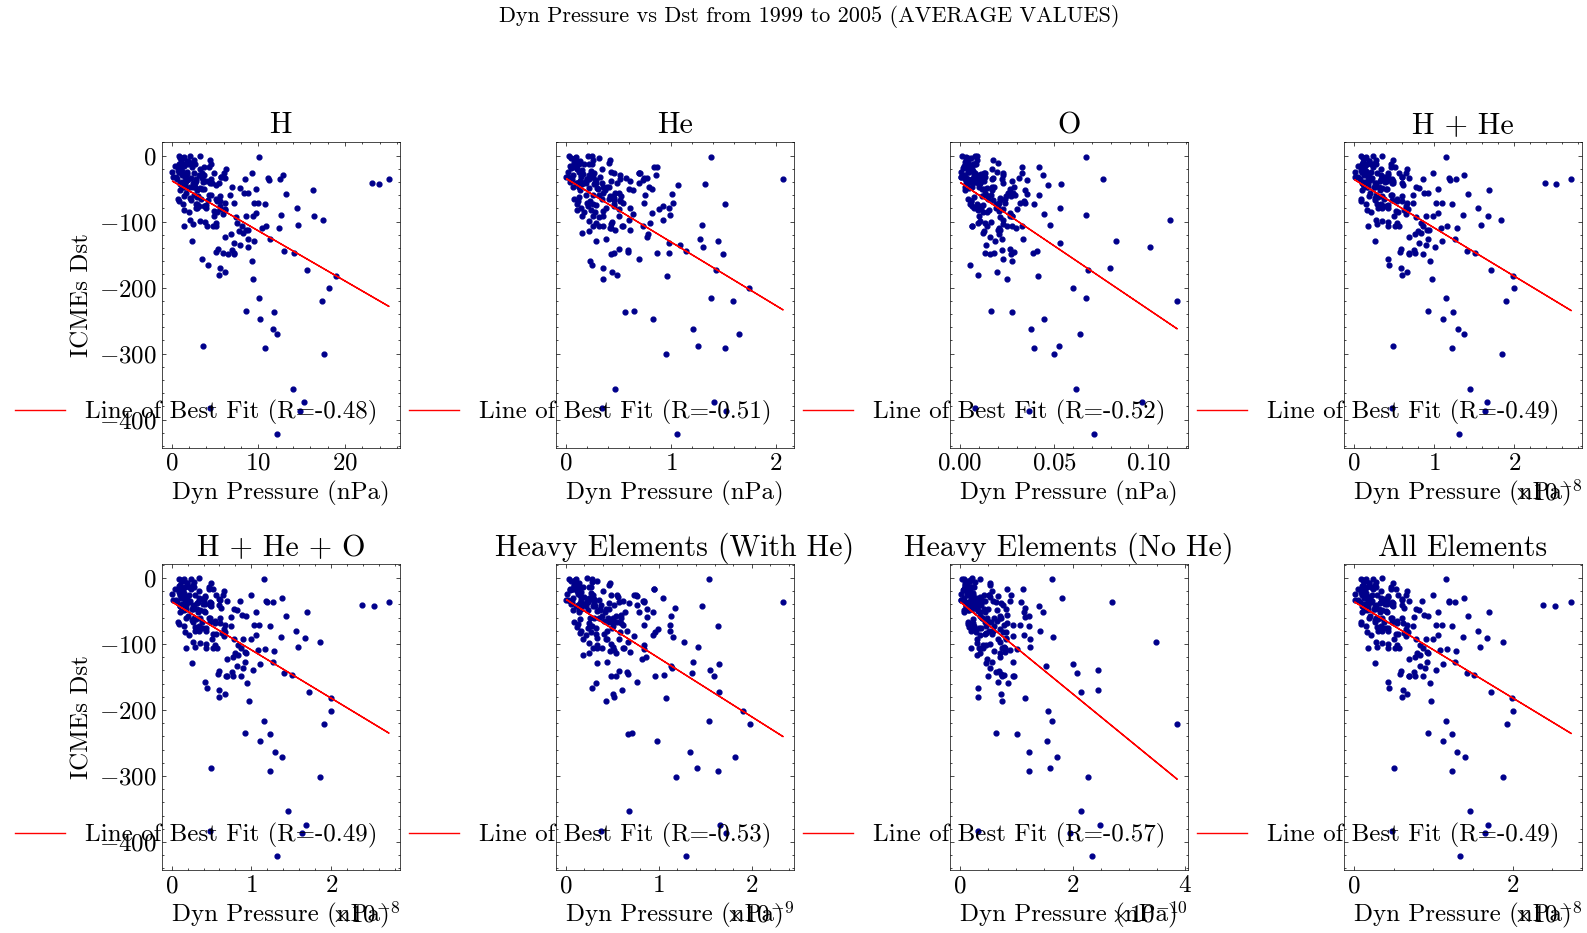

In [34]:
# Variables for plotting MAX VALUE WITHIN INTERVAL

variables = {
    'H': proton_ICMEs_dyn_pressure_clean_max / 1e-9,
    'He': He_ICMEs_dyn_pressure_clean_max / 1e-9,
    'O': O_ICMEs_dyn_pressure_clean_max / 1e-9,
    'H + He': proton_ICMEs_dyn_pressure_clean_max + He_ICMEs_dyn_pressure_clean_max,
    'H + He + O': proton_ICMEs_dyn_pressure_clean_max + He_ICMEs_dyn_pressure_clean_max + O_ICMEs_dyn_pressure_clean_max,
    'Heavy Elements (With He)': heavy_ion_ICMEs_dyn_pressure_clean_max,
    'Heavy Elements (No He)': heavy_element_dyn_pressure_clean_max_no_he_total,
    'All Elements': all_element_ICMEs_dyn_pressure_clean_max_total,
    # 'Fe': Fe_ICMEs_dyn_pressure_clean_max / 1e-9,
    # 'C': C_ICMEs_dyn_pressure_clean_max / 1e-9,
    # 'Ne': Ne_ICMEs_dyn_pressure_clean_max / 1e-9,
    # 'Mg': Mg_ICMEs_dyn_pressure_clean_max / 1e-9,
    # 'Si': Si_ICMEs_dyn_pressure_clean_max / 1e-9
}

# Creating subplots
fig, axs = plt.subplots(2, 4, figsize=(16, 10), sharey=True)
fig.suptitle('Dyn Pressure vs Dst from 1999 to 2005 (AVERAGE VALUES)', fontsize=16)

# Scatter plots with line of best fit and correlation coefficient
for idx, (var, data) in enumerate(variables.items()):
    # Determine subplot position
    row = idx // 4
    col = idx % 4
    
    # Convert data to numerical array
    data = np.array(data)

    # Scatter plot
    axs[row, col].scatter(data, ICMEs_Dst_clean_avg, color = 'darkblue', s = 12)
    
    # Fit a polynomial (line) to the data
    coeffs = np.polyfit(data, ICMEs_Dst_clean_avg, 1)
    poly = np.poly1d(coeffs)
    
    # Plot the line of best fit
    axs[row, col].plot(data, poly(data), color='red', label=f'Line of Best Fit (R={np.corrcoef(data, ICMEs_Dst_clean_avg)[0,1]:.2f})')
    
    # Add labels and legend
    axs[row, col].set_xlabel(f'Dyn Pressure (nPa)')
    axs[0, 0].set_ylabel('ICMEs Dst')
    axs[1, 0].set_ylabel('ICMEs Dst')
    axs[row, col].set_title(f'{var}')
    axs[row, col].legend(loc = 'lower right')

# Adjust layout to make room for rotated labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Saving figure
# plt.savefig("./Plots/Dyn Pressure vs DST (Average Values).jpg", format="jpg", dpi = 300)

# Show plot
plt.show()

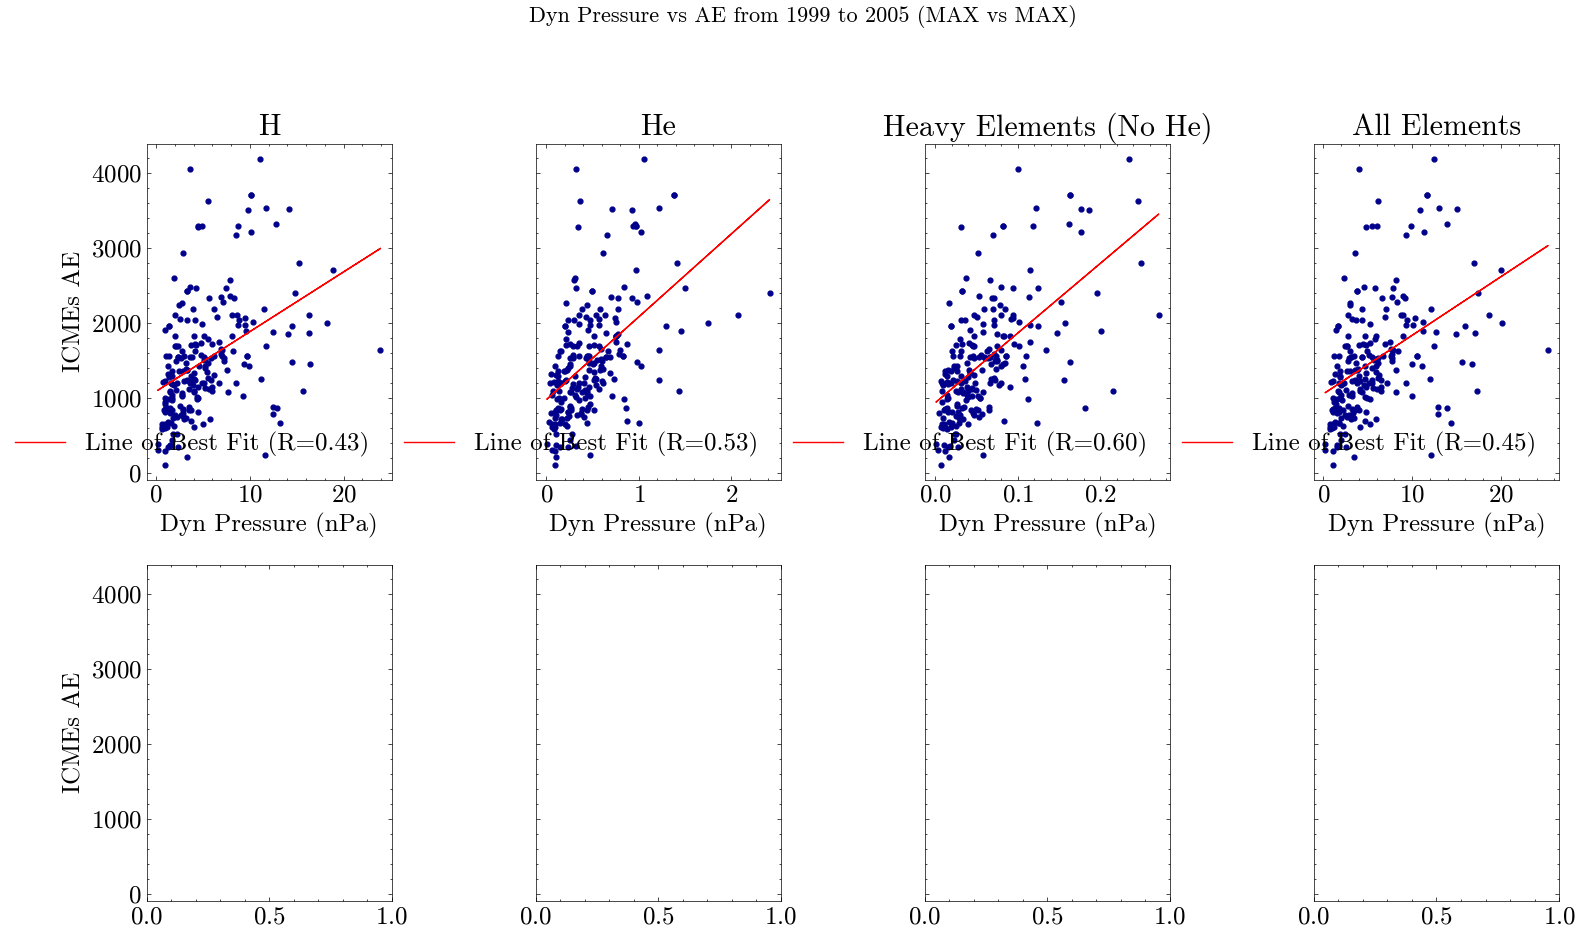

In [35]:
# Variables for plotting
variables = {
    'H': proton_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    'He': He_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    # 'O': O_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    # 'H + He': proton_ICMEs_AE_dyn_pressure_clean_max + He_ICMEs_AE_dyn_pressure_clean_max,
    # 'H + He + O': proton_ICMEs_AE_dyn_pressure_clean_max + He_ICMEs_AE_dyn_pressure_clean_max + O_ICMEs_AE_dyn_pressure_clean_max,
    # 'Heavy Elements (With He)': heavy_ion_ICMEs_AE_dyn_pressure_clean_max,
    'Heavy Elements (No He)': heavy_element_AE_dyn_pressure_clean_max_no_he_total / 1e-9,
    'All Elements': all_element_AE_ICMEs_dyn_pressure_clean_max_total / 1e-9,
    # 'Fe': Fe_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    # 'C': C_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    # 'Ne': Ne_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    # 'Mg': Mg_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    # 'Si': Si_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
}

# Creating subplots
fig, axs = plt.subplots(2, 4, figsize=(16, 10), sharey=True)
fig.suptitle('Dyn Pressure vs AE from 1999 to 2005 (MAX vs MAX)', fontsize=16)

# Scatter plots with line of best fit and correlation coefficient
for idx, (var, data) in enumerate(variables.items()):
    # Determine subplot position
    row = idx // 4
    col = idx % 4
    
    # Convert data to numerical array
    data = np.array(data)

    # Scatter plot
    axs[row, col].scatter(data, ICMEs_AE_clean_max, color = 'darkblue', s=12)
    
    # Fit a polynomial (line) to the data
    coeffs = np.polyfit(data, ICMEs_AE_clean_max, 1)
    poly = np.poly1d(coeffs)
    
    # Plot the line of best fit
    axs[row, col].plot(data, poly(data), color='red', label=f'Line of Best Fit (R={np.corrcoef(data, ICMEs_AE_clean_max)[0,1]:.2f})')
    
    # Add labels and legend
    axs[row, col].set_xlabel(f'Dyn Pressure (nPa)')
    #axs[1, 2].set_xlabel('Density (kg/m^3)')
    axs[0, 0].set_ylabel('ICMEs AE')
    axs[1, 0].set_ylabel('ICMEs AE')
    axs[row, col].set_title(f'{var}')
    axs[row, col].legend(loc = 'lower right')

# Adjust layout to make room for rotated labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Saving figure
# plt.savefig("./Plots/Dyn Pressure vs AE (Average vs Average) All Elements.jpg", format="jpg", dpi = 300)

# Show plot
plt.show()

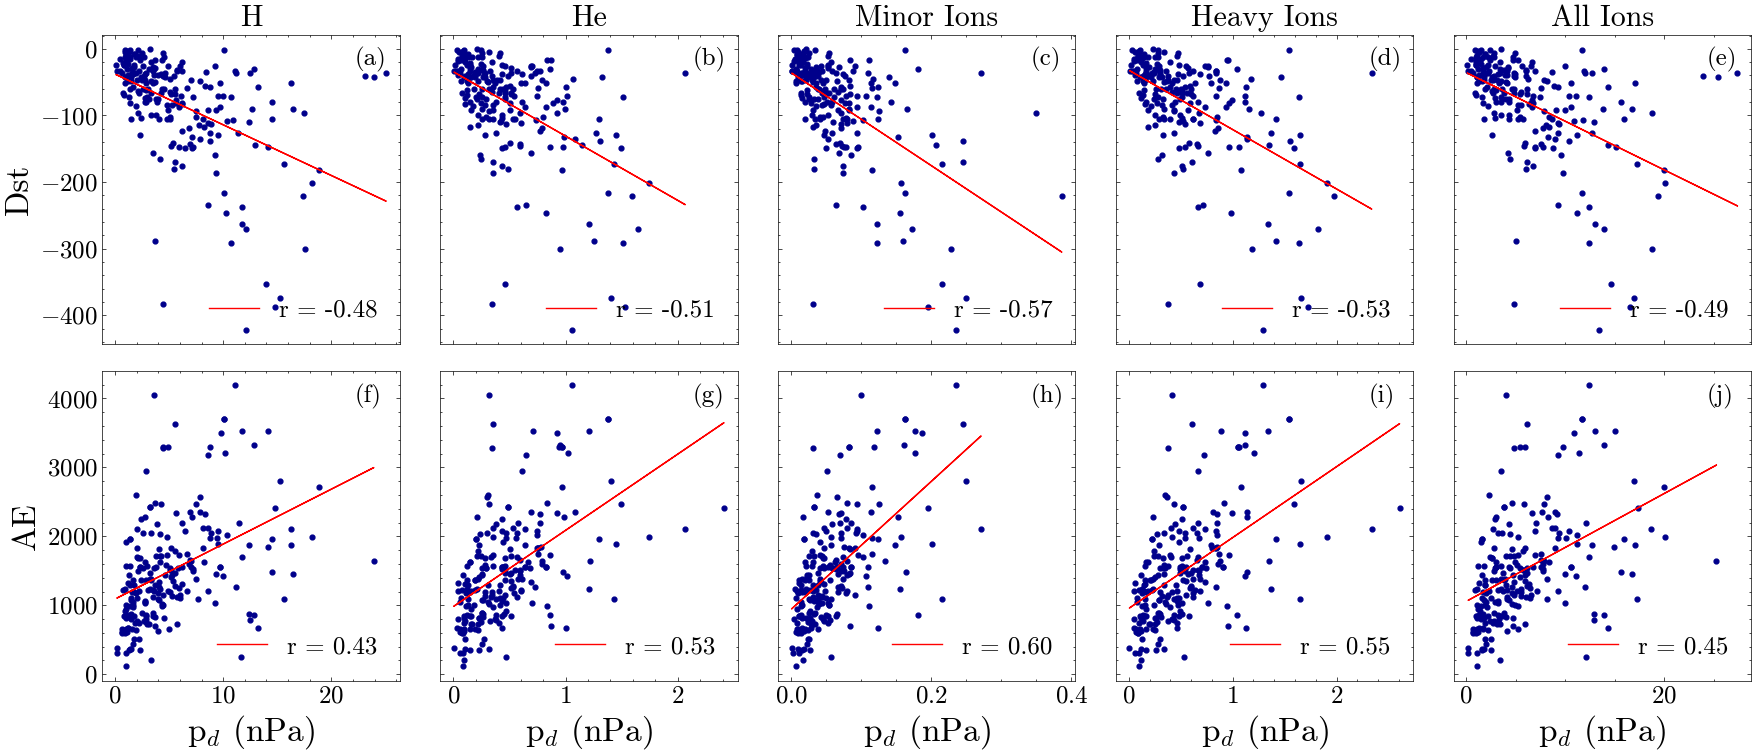

In [36]:
# Variables for plotting Dst (top row)
variables_dst = {
    'H': proton_ICMEs_dyn_pressure_clean_max / 1e-9,
    'He': He_ICMEs_dyn_pressure_clean_max / 1e-9,
    'Minor Ions': heavy_element_dyn_pressure_clean_max_no_he_total / 1e-9,
    'Heavy Ions': heavy_ion_ICMEs_dyn_pressure_clean_max / 1e-9,
    'All Ions': all_element_ICMEs_dyn_pressure_clean_max_total / 1e-9,
}

# Variables for plotting AE (bottom row)
variables_ae = {
    'H': proton_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    'He': He_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    'Minor Ions': heavy_element_AE_dyn_pressure_clean_max_no_he_total / 1e-9,
    'Heavy Ions': heavy_ion_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    'All Ions': all_element_AE_ICMEs_dyn_pressure_clean_max_total / 1e-9,
}

# Create subplots with shared y-axes for each row and shared x-axes for each column
fig, axs = plt.subplots(2, 5, figsize=(18, 8), sharey='row', sharex='col')

# Letters for subplot labels (a) through (j)
subplot_labels = list(string.ascii_lowercase[:10])

# Scatter plots with line of best fit and correlation coefficient for Dst (top row)
for idx, (var, data) in enumerate(variables_dst.items()):
    # Convert data to numerical array
    data = np.array(data)
    
    # Scatter plot
    axs[0, idx].scatter(data, ICMEs_Dst_clean_max, color='darkblue', s=12)
    
    # Fit a polynomial (line) to the data
    coeffs = np.polyfit(data, ICMEs_Dst_clean_max, 1)
    poly = np.poly1d(coeffs)
    
    # Plot the line of best fit
    axs[0, idx].plot(data, poly(data), color='red', label=f'r = {np.corrcoef(data, ICMEs_Dst_clean_max)[0,1]:.2f}')
    
    # Add labels and legend
    # axs[0, idx].set_xlabel('p$_d$ (nPa)')
    if idx == 0:
        axs[0, idx].set_ylabel('Dst', fontsize = 24)
    axs[0, idx].set_title(f'{var}')
    axs[0, idx].legend(loc='lower right', fontsize = 18)
    axs[0, idx].text(0.85, 0.90, f'({subplot_labels[idx]})', transform=axs[0, idx].transAxes,
                     fontsize=18, fontweight='bold')

# Scatter plots with line of best fit and correlation coefficient for AE (bottom row)
for idx, (var, data) in enumerate(variables_ae.items()):
    # Convert data to numerical array
    data = np.array(data)
    
    # Scatter plot
    axs[1, idx].scatter(data, ICMEs_AE_clean_max, color='darkblue', s=12)
    
    # Fit a polynomial (line) to the data
    coeffs = np.polyfit(data, ICMEs_AE_clean_max, 1)
    poly = np.poly1d(coeffs)
    
    # Plot the line of best fit
    axs[1, idx].plot(data, poly(data), color='red', label=f'r = {np.corrcoef(data, ICMEs_AE_clean_max)[0,1]:.2f}')
    
    # Add labels and legend
    axs[1, idx].set_xlabel('p$_d$ (nPa)', fontsize = 24)
    if idx == 0:
        axs[1, idx].set_ylabel('AE', fontsize = 24)
    # axs[1, idx].set_title(f'{var}')
    axs[1, idx].legend(loc= 'lower right', fontsize = 18)
    axs[1, idx].text(0.85, 0.90, f'({subplot_labels[idx + 5]})', transform=axs[1, idx].transAxes,
                     fontsize=18, fontweight='bold')

# Adjust layout to make room for all labels and titles
plt.tight_layout()

# Saving figure
plt.savefig("./Plots/Dyn Pressure vs Dst and AE (Max Values).png", format="png", dpi=300)

# Show plot
plt.show()

In [37]:
def steiger_test(r_xy, r_xz, r_yz, n):
    """
    Perform Steiger's Z-test for two correlations sharing one variable.
    Parameters:
        r_xy: correlation between X and Y (e.g., index and proton pressure).
        r_xz: correlation between X and Z (e.g., index and other ion pressure).
        r_yz: correlation between Y and Z (correlation between proton and ion pressure).
        n:    sample size (number of observations).
    Returns:
        t_value: t statistic for the difference (approximately Z for large n).
        p_value: two-tailed p-value for the significance of the difference.
    """
    # Calculate components of Steiger's formula&#8203;:contentReference[oaicite:5]{index=5}:
    d = r_xy - r_xz  # difference between the two correlations
    determin = 1 - r_xy**2 - r_xz**2 - r_yz**2 + 2 * r_xy * r_xz * r_yz
    av = (r_xy + r_xz) / 2
    cube = (1 - r_yz)**3
    # Compute t statistic (Steiger's Z-test)
    t_value = d * sqrt((n - 1) * (1 + r_yz) / (((2 * (n - 1) / (n - 3)) * determin) + (av**2 * cube)))
    # Degrees of freedom ≈ (n - 2). Compute two-tailed p-value:
    p_value = 2 * (1 - t.cdf(abs(t_value), df=n - 3))
    return t_value, p_value

Dst_ion_pressures = {
    "Helium":    He_ICMEs_dyn_pressure_clean_max / 1e-9,
    "Minor Ions": heavy_element_dyn_pressure_clean_max_no_he_total / 1e-9,
    "Heavy Ions": heavy_ion_ICMEs_dyn_pressure_clean_max / 1e-9,
    "All Ions":   all_element_ICMEs_dyn_pressure_clean_max_total / 1e-9
}

AE_ion_pressures = {
    "Helium":    He_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    "Minor Ions": heavy_element_AE_dyn_pressure_clean_max_no_he_total / 1e-9,
    "Heavy Ions": heavy_ion_ICMEs_AE_dyn_pressure_clean_max / 1e-9,
    "All Ions":   all_element_AE_ICMEs_dyn_pressure_clean_max_total / 1e-9
}

# Baseline proton dynamic pressure array:
baseline_Dst = proton_ICMEs_dyn_pressure_clean_max / 1e-9
baseline_AE = proton_ICMEs_AE_dyn_pressure_clean_max / 1e-9
Dst_array = ICMEs_Dst_clean_max
AE_array = ICMEs_AE_clean_max

# Loop through each ion type and compare correlations with proton baseline
for ion_name, dp_array in Dst_ion_pressures.items():
    # Correlations with Dst index
    r_proton_dst = np.corrcoef(baseline_Dst, Dst_array)[0, 1]
    r_ion_dst    = np.corrcoef(dp_array, Dst_array)[0, 1]
    r_common_dst = np.corrcoef(baseline_Dst, dp_array)[0, 1]  # proton vs ion correlation
    t_dst, p_dst = steiger_test(r_proton_dst, r_ion_dst, r_common_dst, n=len(baseline_Dst))
    print(f"{ion_name} vs Proton (Dst): t = {t_dst:.3f}, p-value = {p_dst:.3f}")

for ion_name, dp_array in AE_ion_pressures.items():
    # Correlations with AE index
    r_proton_ae = np.corrcoef(baseline_AE, AE_array)[0, 1]
    r_ion_ae    = np.corrcoef(dp_array, AE_array)[0, 1]
    r_common_ae = np.corrcoef(baseline_AE, dp_array)[0, 1]  # proton vs ion correlation
    t_ae, p_ae = steiger_test(r_proton_ae, r_ion_ae, r_common_ae, n=len(baseline_AE))
    print(f"{ion_name} vs Proton (AE):  t = {t_ae:.3f}, p-value = {p_ae:.3f}")

Helium vs Proton (Dst): t = 0.796, p-value = 0.427
Minor Ions vs Proton (Dst): t = 2.379, p-value = 0.018
Heavy Ions vs Proton (Dst): t = 1.343, p-value = 0.181
All Ions vs Proton (Dst): t = 4.328, p-value = 0.000
Helium vs Proton (AE):  t = -2.264, p-value = 0.025
Minor Ions vs Proton (AE):  t = -4.384, p-value = 0.000
Heavy Ions vs Proton (AE):  t = -2.784, p-value = 0.006
All Ions vs Proton (AE):  t = -5.991, p-value = 0.000


In [38]:
# def plot_densities(begin_time, end_time):
#     """
#     Plots the various densities within a specific time range.
#     begin_time: Start time for the plot range.
#     end_time: End time for the plot range.
#     """
    
#     # Convert decimal years to datetime
#     begin_time_dt = decimal_year_to_datetime(begin_time)
#     end_time_dt = decimal_year_to_datetime(end_time)
    
#     # Get ICME dates dynamically within the time range
#     vertical_lines_dates = [date for date in adjusted_days_1999_2005 if begin_time <= date <= end_time]
#     vertical_lines_plasma_start = [date for date in adjusted_plasma_start_1999_2005 if begin_time <= date <= end_time]
#     vertical_lines_plasma_end = [date for date in adjusted_plasma_end_1999_2005 if begin_time <= date <= end_time]
    
#     # Calculate the indices based on the new time parameters
#     start_idx_heavy_elements = df_heavy_elements.index[df_heavy_elements.iloc[:, 0] >= begin_time].tolist()[0] #SWICS
#     end_idx_heavy_elements = df_heavy_elements.index[df_heavy_elements.iloc[:, 0] <= end_time].tolist()[-1] #SWICS
    
#     start_idx_proton = df_proton.index[df_proton.iloc[:, 0] >= begin_time].tolist()[0] #SWICS
#     end_idx_proton = df_proton.index[df_proton.iloc[:, 0] <= end_time].tolist()[-1] #SWICS
    
#     start_idx_OMNI = df_OMNI.index[df_OMNI.iloc[:, 12] >= begin_time].tolist()[0]
#     end_idx_OMNI = df_OMNI.index[df_OMNI.iloc[:, 12] <= end_time].tolist()[-1]
    
#     # Define the time ranges
#     time_range_proton = df_proton.iloc[start_idx_proton:end_idx_proton, 0].apply(decimal_year_to_datetime)
#     time_range_heavy_elements = df_heavy_elements.iloc[start_idx_heavy_elements:end_idx_heavy_elements, 0].apply(decimal_year_to_datetime)
#     time_range_OMNI = df_OMNI.iloc[start_idx_OMNI:end_idx_OMNI, 12].apply(decimal_year_to_datetime)

#     fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
#     ax1.plot(time_range_proton, proton_dyn_pressure[start_idx_proton:end_idx_proton] / 1e-9, label='SWICS Proton Dyn Pressure', color = 'red')
#     ax1.plot(time_range_heavy_elements, He_dyn_pressure[start_idx_heavy_elements:end_idx_heavy_elements] / 1e-9, label='SWICS He Dyn Pressure', color = 'orange')
#     ax1.plot(time_range_heavy_elements, all_elements_dyn_pressure[start_idx_heavy_elements:end_idx_heavy_elements] / 1e-9, label='SWICS All Element Dyn Pressure', color = 'brown')
#     ax1.set_ylabel('Dyn Pressure (nPa)')
#     ax1.legend()
    
#     ax2.plot(time_range_OMNI, df_OMNI.iloc[start_idx_OMNI:end_idx_OMNI, 10], label='OMNI Dst', color = 'violet')
#     ax2.set_xlabel('Time')
#     ax2.set_ylabel('Dst')
#     ax2.legend()
    
#     # Add vertical lines for ICME dates
#     for date in vertical_lines_dates:
#         ax1.axvline(x=decimal_year_to_datetime(date), color='red', linestyle = '--')
#         ax2.axvline(x=decimal_year_to_datetime(date), color='red', linestyle = '--')
        
#     # Add vertical lines for ICME plasma start
#     for date in vertical_lines_plasma_start:
#         ax1.axvline(x=decimal_year_to_datetime(date), color='blue', linestyle = '--')
#         ax2.axvline(x=decimal_year_to_datetime(date), color='blue', linestyle = '--')

#     # Add vertical lines for ICME plasma end
#     for date in vertical_lines_plasma_end:
#         ax1.axvline(x=decimal_year_to_datetime(date), color='green', linestyle = '--')
#         ax2.axvline(x=decimal_year_to_datetime(date), color='green', linestyle = '--')
    
#     # Add shaded areas for ICME plasma intervals
#     for start_date, end_date in zip(vertical_lines_plasma_start, vertical_lines_plasma_end):
#         ax1.axvspan(decimal_year_to_datetime(start_date), decimal_year_to_datetime(end_date), color='lightgray', alpha=0.5)
#         ax2.axvspan(decimal_year_to_datetime(start_date), decimal_year_to_datetime(end_date), color='lightgray', alpha=0.5)
    
#     plt.tight_layout()
#     plt.show()

# # Example of plotting for a given time range
# plot_densities(2001.29, 2001.302)

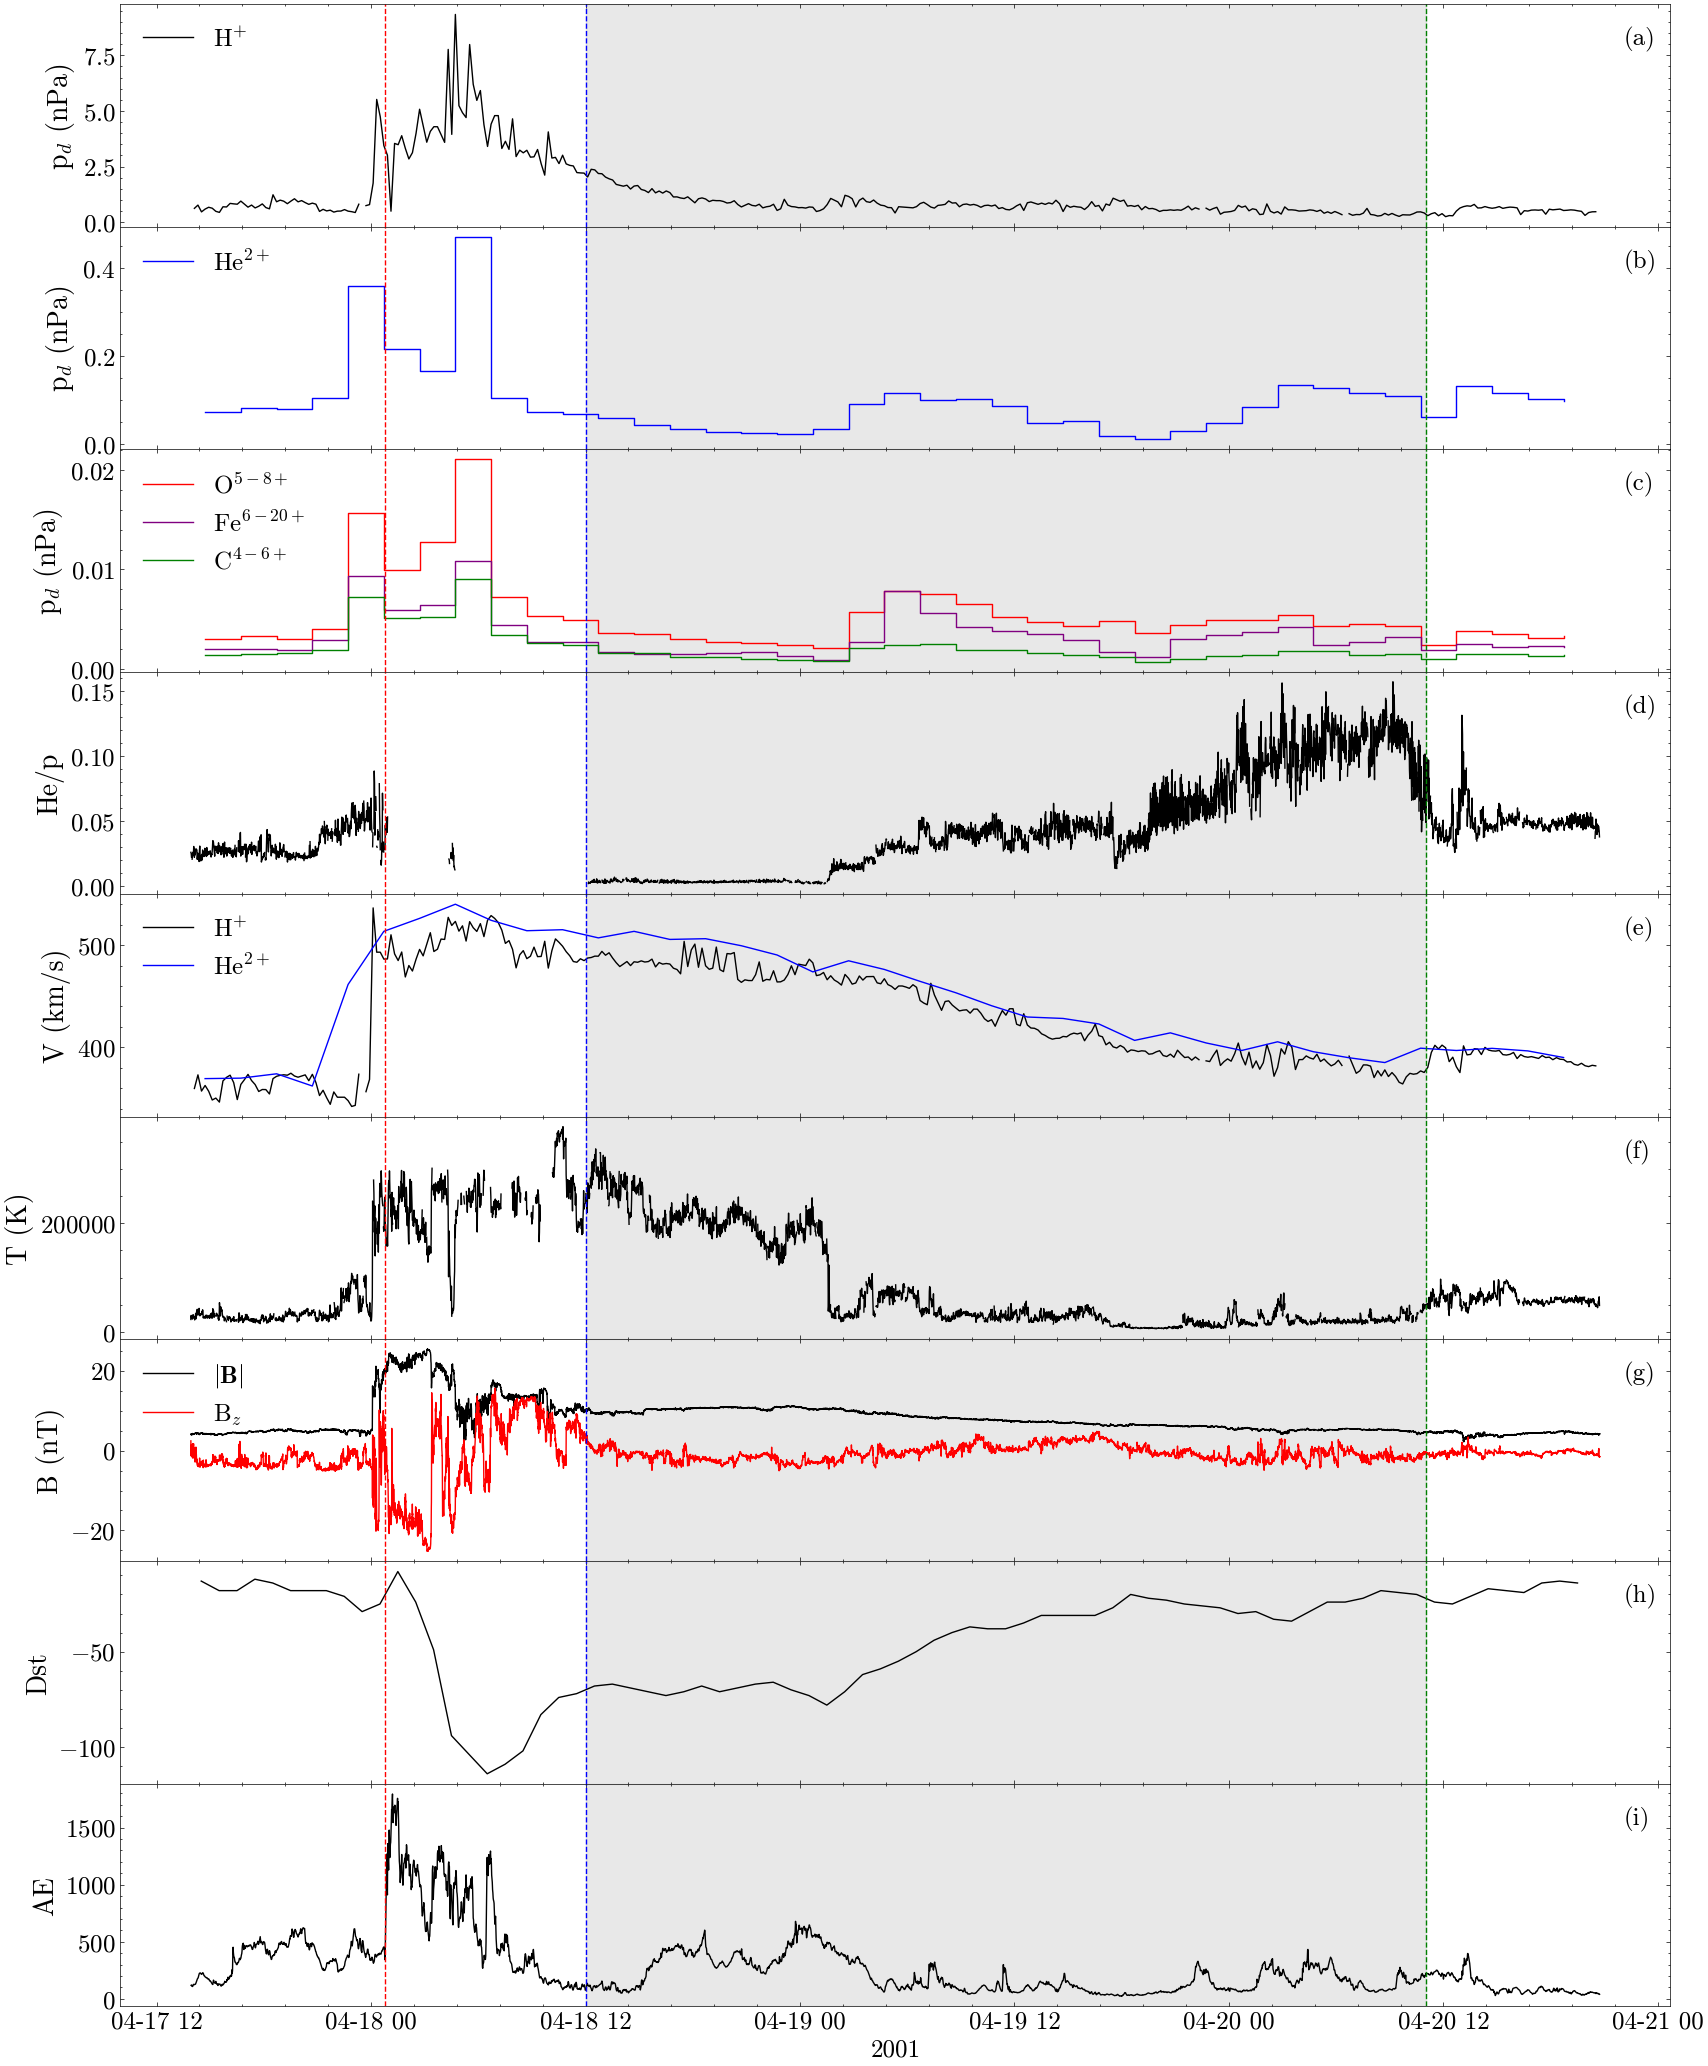

In [39]:
def plot_densities(begin_time, end_time, save_path=None, dpi=300):
    """
    Plots the various densities within a specific time range and saves the plot if a save path is provided.
    begin_time: Start time for the plot range.
    end_time: End time for the plot range.
    save_path: Optional; path to save the plot image.
    """
    
    # Convert decimal years to datetime
    begin_time_dt = decimal_year_to_datetime(begin_time)
    end_time_dt = decimal_year_to_datetime(end_time)
    
    # Get ICME dates dynamically within the time range
    vertical_lines_dates = [date for date in adjusted_days_1999_2005 if begin_time <= date <= end_time]
    vertical_lines_plasma_start = [date for date in adjusted_plasma_start_1999_2005 if begin_time <= date <= end_time]
    vertical_lines_plasma_end = [date for date in adjusted_plasma_end_1999_2005 if begin_time <= date <= end_time]
    
    # Calculate the indices based on the new time parameters
    start_idx_heavy_elements = df_heavy_elements.index[df_heavy_elements.iloc[:, 0] >= begin_time].tolist()[0]
    end_idx_heavy_elements = df_heavy_elements.index[df_heavy_elements.iloc[:, 0] <= end_time].tolist()[-1]
    
    start_idx_proton = df_proton.index[df_proton.iloc[:, 0] >= begin_time].tolist()[0]
    end_idx_proton = df_proton.index[df_proton.iloc[:, 0] <= end_time].tolist()[-1]
    
    start_idx_OMNI = df_OMNI.index[df_OMNI.iloc[:, 12] >= begin_time].tolist()[0]
    end_idx_OMNI = df_OMNI.index[df_OMNI.iloc[:, 12] <= end_time].tolist()[-1]
    
    start_idx_OMNI_1MIN = OMNI_1MIN_updated.index[OMNI_1MIN_updated.iloc[:, 14] >= begin_time].tolist()[0]
    end_idx_OMNI_1MIN = OMNI_1MIN_updated.index[OMNI_1MIN_updated.iloc[:, 14] <= end_time].tolist()[-1]
    
    start_idx_MAG = MAG.index[MAG.iloc[:, 0] >= begin_time].tolist()[0]
    end_idx_MAG = MAG.index[MAG.iloc[:, 0] <= end_time].tolist()[-1]
    
    start_idx_SWEPAM = SWEPAM.index[SWEPAM.iloc[:, 0] >= begin_time].tolist()[0]
    end_idx_SWEPAM = SWEPAM.index[SWEPAM.iloc[:, 0] <= end_time].tolist()[-1]
    
    # Define the time ranges
    time_range_proton = df_proton.iloc[start_idx_proton:end_idx_proton, 0].apply(decimal_year_to_datetime)
    time_range_heavy_elements = df_heavy_elements.iloc[start_idx_heavy_elements:end_idx_heavy_elements, 0].apply(decimal_year_to_datetime)
    time_range_OMNI = df_OMNI.iloc[start_idx_OMNI:end_idx_OMNI, 12].apply(decimal_year_to_datetime)
    time_range_OMNI_AE = OMNI_1MIN_updated.iloc[start_idx_OMNI_1MIN:end_idx_OMNI_1MIN, 14].apply(decimal_year_to_datetime)
    time_range_MAG = MAG.iloc[start_idx_MAG:end_idx_MAG, 0].apply(decimal_year_to_datetime)
    time_range_SWEPAM = SWEPAM.iloc[start_idx_SWEPAM: end_idx_SWEPAM, 0].apply(decimal_year_to_datetime)

    fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9) = plt.subplots(9, 1, sharex=True, figsize=(20, 26))
    
    # Panel 1
    ax1.plot(time_range_proton, proton_dyn_pressure[start_idx_proton:end_idx_proton] / 1e-9, color='black', label = r'H$^{+}$')
    ax1.set_ylabel(r'p$_d$ (nPa)', fontsize = 20)
    ax1.legend(fontsize=18, loc = 'upper left')
    ax1.text(0.97, 0.9, '(a)', transform=ax1.transAxes, fontsize=18, verticalalignment='top')
    
    # Panel 2
    ax2.plot(time_range_heavy_elements, 
             He_dyn_pressure[start_idx_heavy_elements:end_idx_heavy_elements] / 1e-9, 
             color='blue', 
             label = r'He$^{2+}$', 
             drawstyle='steps-post')
    ax2.set_ylabel(r'p$_d$ (nPa)', fontsize = 20)
    ax2.legend(fontsize=18, loc = 'upper left')
    ax2.text(0.97, 0.9, '(b)', transform=ax2.transAxes, fontsize=18, verticalalignment='top')

    
    # Panel 3
    ax3.plot(time_range_heavy_elements, 
             O_dyn_pressure[start_idx_heavy_elements:end_idx_heavy_elements] / 1e-9, 
             label=r'O$^{5-8+}$', color='red', drawstyle='steps-post')
    ax3.plot(time_range_heavy_elements, 
             Fe_dyn_pressure[start_idx_heavy_elements:end_idx_heavy_elements] / 1e-9, 
             label=r'Fe$^{6-20+}$', color='purple', drawstyle='steps-post')
    ax3.plot(time_range_heavy_elements, 
             C_dyn_pressure[start_idx_heavy_elements:end_idx_heavy_elements] / 1e-9, 
             label=r'C$^{4-6+}$', color='green', drawstyle='steps-post')
    ax3.set_ylabel(r'p$_d$ (nPa)', fontsize=20)
    ax3.legend(fontsize=18, loc = 'upper left')
    ax3.text(0.97, 0.9, '(c)', transform=ax3.transAxes, fontsize=18, verticalalignment='top')
    
    # Panel 4
    ax4.plot(time_range_SWEPAM, SWEPAM_he_proton[start_idx_SWEPAM:end_idx_SWEPAM], color='black')
    ax4.set_ylabel('He/p', fontsize=20)
    ax4.text(0.97, 0.9, '(d)', transform=ax4.transAxes, fontsize=18, verticalalignment='top')
    
    # Panel 5
    ax5.plot(time_range_proton, df_proton.iloc[start_idx_proton:end_idx_proton, 2], label=r'H$^{+}$', color='black')
    ax5.plot(time_range_heavy_elements, df_heavy_elements.iloc[start_idx_heavy_elements:end_idx_heavy_elements, 2], label=r'He$^{2+}$', color='blue')
    ax5.set_ylabel('V (km/s)', fontsize=20)
    ax5.legend(fontsize=18, loc = 'upper left')
    ax5.text(0.97, 0.9, '(e)', transform=ax5.transAxes, fontsize=18, verticalalignment='top')
    
    # Panel 6
    ax6.plot(time_range_SWEPAM, SWEPAM_proton_temp[start_idx_SWEPAM:end_idx_SWEPAM], color='black')
    ax6.set_ylabel('T (K)', fontsize=20)
    ax6.text(0.97, 0.9, '(f)', transform=ax6.transAxes, fontsize=18, verticalalignment='top')
            
    # Panel 7
    ax7.plot(time_range_MAG, MAG_Bmag[start_idx_MAG:end_idx_MAG] / 1e-9, color='black', label=r'$|\mathbf{B}|$')
    ax7.plot(time_range_MAG, MAG_Bgsm_z[start_idx_MAG:end_idx_MAG] / 1e-9, color='red', label=r'B$_z$')
    ax7.set_ylabel('B (nT)', fontsize=20)
    ax7.text(0.97, 0.9, '(g)', transform=ax7.transAxes, fontsize=18, verticalalignment='top')
    ax7.legend(fontsize=18, loc = 'upper left')
    
    # Panel 8
    ax8.plot(time_range_OMNI, df_OMNI.iloc[start_idx_OMNI:end_idx_OMNI, 10], color='black')
    ax8.set_ylabel('Dst', fontsize=20)
    ax8.text(0.97, 0.9, '(h)', transform=ax8.transAxes, fontsize=18, verticalalignment='top')
    
    # Panel 9
    ax9.plot(time_range_OMNI_AE, OMNI_1MIN_updated.iloc[start_idx_OMNI_1MIN:end_idx_OMNI_1MIN, 11], color='black')
    ax9.set_ylabel('AE', fontsize=20)
    ax9.text(0.97, 0.9, '(i)', transform=ax9.transAxes, fontsize=18, verticalalignment='top')
    ax9.set_xlabel('2001', fontsize=18)
    
    # Add vertical lines and shaded regions for all plots
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
        for date in vertical_lines_dates:
            ax.axvline(x=decimal_year_to_datetime(date), color='red', linestyle='--')
        
        for date in vertical_lines_plasma_start:
            ax.axvline(x=decimal_year_to_datetime(date), color='blue', linestyle='--')
        
        for date in vertical_lines_plasma_end:
            ax.axvline(x=decimal_year_to_datetime(date), color='green', linestyle='--')
        
        for start_date, end_date in zip(vertical_lines_plasma_start, vertical_lines_plasma_end):
            ax.axvspan(decimal_year_to_datetime(start_date), decimal_year_to_datetime(end_date), color='lightgray', alpha=0.5)
    
    # plt.tight_layout()
    
    plt.subplots_adjust(hspace=0.0)  # Remove vertical space between subplots
    
    # Save the plot if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=dpi)
        
    plt.show()

# Example of plotting for a given time range and saving the plot
plot_densities(2001.292, 2001.301)#, save_path='./Plots/Example ICME (histograms).png', dpi=300)

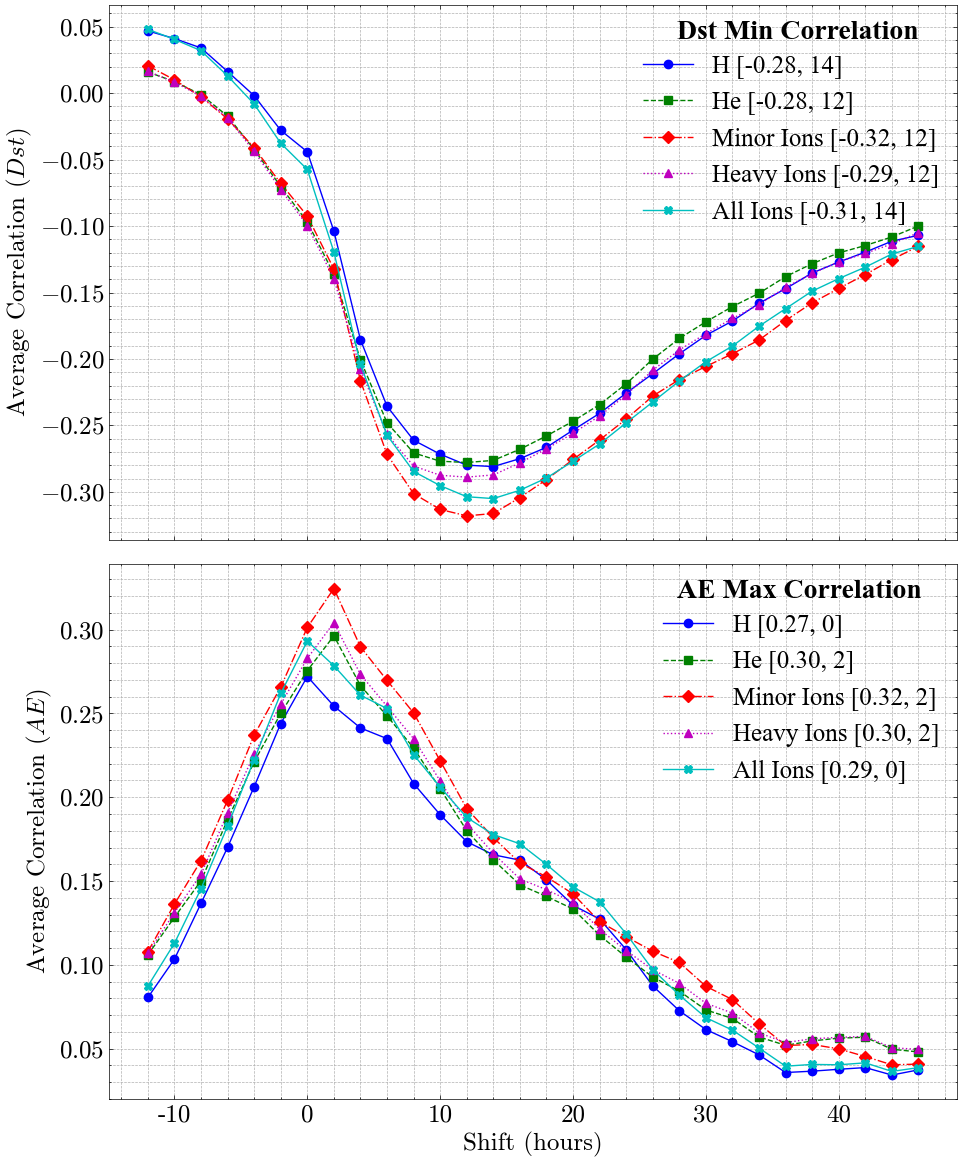

In [40]:
# Convert OMNI_Dst to a pandas Series with float index
interp_OMNI_Dst = np.interp(time_in_days, df_OMNI.iloc[:, 12], OMNI_Dst)
interp_OMNI_Dst_pd = pd.Series(interp_OMNI_Dst, index=(time_in_days))

# Convert OMNI_AE to a pandas Series with float index
interp_OMNI_AE = np.interp(time_in_days, OMNI_1MIN_updated['Decimal_Year'], OMNI_1MIN_updated['1-M_AE'])
interp_OMNI_AE_pd = pd.Series(interp_OMNI_AE, index=(time_in_days))

# Define the variables and their names for iteration
variables = [
    ('H', interp_proton_dyn_pressure),
    ('He', He_dyn_pressure),
    ('Minor Ions', heavy_elements_dyn_pressure - He_dyn_pressure),
    ('Heavy Ions', heavy_elements_dyn_pressure),
    ('All Ions', all_elements_dyn_pressure),
]

# Define the shifting window range
shift_range = range(-6, 24, 1)  # from -12 to +48 hours with 1-hour steps

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot formatting options
line_styles = ['-', '--', '-.', ':', '-']
markers = ['o', 's', 'D', '^', 'X']        
colors = ['b', 'g', 'r', 'm', 'c']    
font = {'family': 'Times New Roman', 'size': 16}

plt.rc('font', **font)

# Loop through each variable for Dst index
for i, (var_name, var_data) in enumerate(variables):
    # Convert variable data to a pandas Series with float index
    var_series = pd.Series(var_data, index=time_in_days)
    
    # Store the correlation results
    correlations = []

    # Calculate correlation for each shift
    for shift in shift_range:
        shifted_var_series = var_series.shift(shift)
        for icme_time in adjusted_days_1999_2005:
            window_start = icme_time - 12 * 0.000114
            window_end = icme_time + 48 * 0.00114
            var_window = shifted_var_series[window_start:window_end]
            dst_window = interp_OMNI_Dst_pd[window_start:window_end]
            var_window = var_window.dropna()
            dst_window = dst_window.dropna()
            common_valid_index = var_window.index.intersection(dst_window.index)
            var_window = var_window[common_valid_index]
            dst_window = dst_window[common_valid_index]
            if len(var_window) > 1 and len(dst_window) > 1:
                corr, _ = pearsonr(var_window, dst_window)
                correlations.append((shift, corr))
    
    # Convert results to DataFrame for plotting
    correlation_df = pd.DataFrame(correlations, columns=['Shift', 'Correlation'])
    average_correlations = correlation_df.groupby('Shift')['Correlation'].mean()
    
    # Find the shift with maximum absolute correlation
    max_corr_shift = average_correlations.abs().idxmax()
    max_corr_value = average_correlations[max_corr_shift]
    
    # Plotting the average correlation with label including max correlation and delay time
    label = f'{var_name} [{max_corr_value:.2f}, {2*max_corr_shift}]'
    ax1.plot(average_correlations.index, average_correlations.values, linestyle=line_styles[i % len(line_styles)], 
             marker=markers[i % len(markers)], color=colors[i % len(colors)], label=label)

ax1.set_ylabel(r'Average Correlation ($Dst$)')
# ax1.set_title('Cross Correlation with Dst Index')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend(loc='upper right', bbox_to_anchor=(1, 0.95))

# Loop through each variable for AE index
for i, (var_name, var_data) in enumerate(variables):
    # Convert variable data to a pandas Series with float index
    var_series = pd.Series(var_data, index=time_in_days)
    
    # Store the correlation results
    correlations = []

    # Calculate correlation for each shift
    for shift in shift_range:
        shifted_var_series = var_series.shift(shift)
        for icme_time in adjusted_days_1999_2005:
            window_start = icme_time - 12 * 0.000114
            window_end = icme_time + 48 * 0.00114
            var_window = shifted_var_series[window_start:window_end]
            AE_window = interp_OMNI_AE_pd[window_start:window_end]
            var_window = var_window.dropna()
            AE_window = AE_window.dropna()
            common_valid_index = var_window.index.intersection(AE_window.index)
            var_window = var_window[common_valid_index]
            AE_window = AE_window[common_valid_index]
            if len(var_window) > 1 and len(AE_window) > 1:
                corr, _ = pearsonr(var_window, AE_window)
                correlations.append((shift, corr))
    
    # Convert results to DataFrame for plotting
    correlation_df = pd.DataFrame(correlations, columns=['Shift', 'Correlation'])
    average_correlations = correlation_df.groupby('Shift')['Correlation'].mean()
    
    # Find the shift with maximum absolute correlation
    max_corr_shift = average_correlations.abs().idxmax()
    max_corr_value = average_correlations[max_corr_shift]
    
    # Plotting the average correlation with label including max correlation and delay time
    label = f'{var_name} [{max_corr_value:.2f}, {2*max_corr_shift}]'
    ax2.plot(average_correlations.index, average_correlations.values, linestyle=line_styles[i % len(line_styles)], 
             marker=markers[i % len(markers)], color=colors[i % len(colors)], label=label)

ax2.set_xlabel('Shift (hours)')
ax2.set_ylabel(r'Average Correlation ($AE$)')
# ax2.set_title('Cross Correlation with AE Index')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.95))

# Label the Dst
ax1.text(
    0.67, 0.97, #coords x,y        
    "Dst Min Correlation",                
    transform=ax1.transAxes,
    fontsize=20,
    fontweight="semibold",
    color="black",
    verticalalignment="top"
)

# Label the AE
ax2.text(
    0.67, 0.97, #coords x,y
    "AE Max Correlation",
    transform=ax2.transAxes,
    fontsize=20,
    fontweight="semibold",
    color="black",
    verticalalignment="top"
)

legend_kws = dict(
    loc="upper right",      
    bbox_to_anchor=(1.0, 0.94), 
    borderaxespad=0.3,      
    frameon=False,          
    alignment="left",       
    prop={'size': 18}       
)

ax1.legend(**legend_kws)
ax2.legend(**legend_kws)

# Format the x-axis to show values multiplied by 2
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x * 2:.0f}'))

plt.tight_layout()

# Saving figure
plt.savefig("./Plots/Time Delayed Plots.png", format="png", dpi=300)

plt.show()

In [41]:
### AVERAGE of magnetopause standoff distance across the ENTIRE time range 1999-2005 (NOT JUST ICMEs) ###

# List to store combined magnetopause distances
combined_L_mp_distances = []

# List to store proton-only magnetopause distances
proton_only_L_mp_distances = []

# Defining time_in_days into an array with proper indices
time_in_days_indices_array = list(range(len(time_in_days)))

for idx in time_in_days_indices_array:
    heavy_element_total_dens = He_mass_dens[idx] + C_mass_dens[idx] + O_mass_dens[idx] + Ne_mass_dens[idx] + Mg_mass_dens[idx] + Si_mass_dens[idx] + Fe_mass_dens[idx]
    heavy_element_vel = He_bulk_vel[idx]
    
    proton_mass_dens_val = interpolated_proton_mass_dens[idx]
    proton_vel = interpolated_proton_velocity[idx]
    
    # Check if any of the values are NaN, and skip this iteration if they are
    if np.isnan(heavy_element_total_dens) or np.isnan(heavy_element_vel) or np.isnan(proton_mass_dens_val) or np.isnan(proton_vel):
        continue
    
    total_mass_dens = proton_mass_dens_val + heavy_element_total_dens
    avg_velocity = (proton_mass_dens_val * proton_vel + heavy_element_total_dens * heavy_element_vel) / total_mass_dens
    
    # Calculate combined magnetopause distance
    L_mp = L_mp_equation(total_mass_dens, avg_velocity)
    combined_L_mp_distances.append(L_mp)    
    
    # Calculate proton-only magnetopause distance
    L_mp_proton_only = L_mp_equation(proton_mass_dens_val, proton_vel)
    proton_only_L_mp_distances.append(L_mp_proton_only)
    
# Calculate average combined magnetopause distance
average_L_mp = np.mean(combined_L_mp_distances)
print('Average Combined Magnetopause Distance (1999-2005) (r_earth):', average_L_mp)
          
# Calculate average proton-only magnetopause distance
average_L_mp_proton_only = np.mean(proton_only_L_mp_distances)
print('Average Proton-Only Magnetopause Distance (1999-2005) (r_earth):', average_L_mp_proton_only)

# Calculate the standard deviation of combined_L_mp_distances
std_combined_L_mp = np.std(combined_L_mp_distances)
print('Standard Deviation of Combined Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth):', std_combined_L_mp)

# Calculate the standard deviation of proton_only_L_mp_distances
std_proton_only_L_mp = np.std(proton_only_L_mp_distances)
print('Standard Deviation of Proton-Only Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth):', std_proton_only_L_mp)

# Calculate the decrease in magnetopause distance
decrease = average_L_mp_proton_only - average_L_mp
percentage_decrease = (decrease / average_L_mp_proton_only) * 100
print(f'Decrease in Magnetopause Distance when Including Heavy Ions: {decrease:.3f} r_earth')
print(f'Percentage Decrease: {percentage_decrease:.2f}%')

print(len(combined_L_mp_distances))

Average Combined Magnetopause Distance (1999-2005) (r_earth): 10.925541470387357
Average Proton-Only Magnetopause Distance (1999-2005) (r_earth): 11.263705399981006
Standard Deviation of Combined Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth): 1.225237334289651
Standard Deviation of Proton-Only Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth): 1.3144083251058853
Decrease in Magnetopause Distance when Including Heavy Ions: 0.338 r_earth
Percentage Decrease: 3.00%
29249


In [42]:
# Converting the lists to NumPy arrays
combined_L_mp_distances = np.array(combined_L_mp_distances)
proton_only_L_mp_distances = np.array(proton_only_L_mp_distances)

# Perform the paired t-test
t_stat, p_value = stats.ttest_rel(proton_only_L_mp_distances, combined_L_mp_distances)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

# Interpret the result
alpha = 0.05  # Typical significance level
if p_value < alpha:
    print("The decrease in magnetopause distance is statistically significant.")
else:
    print("The decrease in magnetopause distance is not statistically significant.")
    
# Calculate the 95% confidence interval for the mean difference
mean_diff = np.mean(proton_only_L_mp_distances) - np.mean(combined_L_mp_distances)
standard_error = np.std(proton_only_L_mp_distances - combined_L_mp_distances, ddof=1) / np.sqrt(len(proton_only_L_mp_distances))
confidence_interval = stats.t.interval(0.95, len(proton_only_L_mp_distances)-1, loc=mean_diff, scale=standard_error)

print(f'95% Confidence Interval for Mean Difference: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})')

T-statistic: 245.5979
P-value: 0.0000
The decrease in magnetopause distance is statistically significant.
95% Confidence Interval for Mean Difference: (0.3355, 0.3409)


In [43]:
# Set the seed for reproducibility
np.random.seed(48)

# Take a random sample of the data (e.g., 50% of the data)
sample_size = int(len(combined_L_mp_distances) * 0.001)  # Modify the proportion as needed

# Select random indices
random_indices = np.random.choice(len(combined_L_mp_distances), sample_size, replace=False)

# Create random samples of combined and proton-only magnetopause distances
sample_combined_L_mp = combined_L_mp_distances[random_indices]
sample_proton_only_L_mp = proton_only_L_mp_distances[random_indices]

# Perform the paired t-test on the random sample
t_stat, p_value = stats.ttest_rel(sample_proton_only_L_mp, sample_combined_L_mp)

print(f'T-statistic (Random Sample): {t_stat:.4f}')
print(f'P-value (Random Sample): {p_value:.4f}')

# Interpret the result
alpha = 0.05  # Typical significance level
if p_value < alpha:
    print("The decrease in magnetopause distance in the random sample is statistically significant.")
else:
    print("The decrease in magnetopause distance in the random sample is not statistically significant.")

# Calculate the 95% confidence interval for the mean difference in the random sample
mean_diff_sample = np.mean(sample_proton_only_L_mp) - np.mean(sample_combined_L_mp)
standard_error_sample = np.std(sample_proton_only_L_mp - sample_combined_L_mp, ddof=1) / np.sqrt(len(sample_proton_only_L_mp))
confidence_interval_sample = stats.t.interval(0.95, len(sample_proton_only_L_mp) - 1, loc=mean_diff_sample, scale=standard_error_sample)

print(f'95% Confidence Interval for Mean Difference (Random Sample): ({confidence_interval_sample[0]:.4f}, {confidence_interval_sample[1]:.4f})')

T-statistic (Random Sample): 7.0337
P-value (Random Sample): 0.0000
The decrease in magnetopause distance in the random sample is statistically significant.
95% Confidence Interval for Mean Difference (Random Sample): (0.2571, 0.4684)


In [44]:
### Magnetopause Distance Calculation for ALL ICMEs ###

# Ensure all cleaned arrays have the same length
num_events = len(Fe_ICMEs_mass_dens_clean)
print(f"Number of events: {num_events}")

# Lists to store magnetopause distances
combined_L_mp_distances_ICMEs = []
proton_only_L_mp_distances_ICMEs = []

for idx in range(num_events):
    heavy_element_total_dens = (
        He_ICMEs_mass_dens_clean[idx] + Fe_ICMEs_mass_dens_clean[idx] + 
        O_ICMEs_mass_dens_clean[idx] + C_ICMEs_mass_dens_clean[idx] + 
        Mg_ICMEs_mass_dens_clean[idx] + Si_ICMEs_mass_dens_clean[idx] + 
        Ne_ICMEs_mass_dens_clean[idx]
    )
    heavy_element_vel = He_ICMEs_vel_clean[idx]
    
    proton_mass_dens_val = proton_ICMEs_mass_dens_clean[idx]
    proton_vel = proton_ICMEs_vel_clean[idx]
    
    total_mass_dens = proton_mass_dens_val + heavy_element_total_dens
    avg_velocity = (proton_mass_dens_val * proton_vel + heavy_element_total_dens * heavy_element_vel) / total_mass_dens
    
    # Calculate combined magnetopause distance
    L_mp = L_mp_equation(total_mass_dens, avg_velocity)
    combined_L_mp_distances_ICMEs.append(L_mp)
    
    # Calculate proton-only magnetopause distance
    L_mp_proton_only = L_mp_equation(proton_mass_dens_val, proton_vel)
    proton_only_L_mp_distances_ICMEs.append(L_mp_proton_only)

    # Debugging statements to track progress and values
    #print(f"Event {idx + 1}/{num_events}: L_mp = {L_mp}, L_mp_proton_only = {L_mp_proton_only}")

# Final lengths of the lists
# print(f"Final number of combined L_mp distances: {len(combined_L_mp_distances)}")
# print(f"Final number of proton-only L_mp distances: {len(proton_only_L_mp_distances)}")

# Calculate average combined magnetopause distance
average_L_mp_ICMEs = np.mean(combined_L_mp_distances_ICMEs)
print('Average Combined Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth):', average_L_mp_ICMEs)

# Calculate average proton-only magnetopause distance
average_L_mp_proton_only_ICMEs = np.mean(proton_only_L_mp_distances_ICMEs)
print('Average Proton-Only Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth):', average_L_mp_proton_only_ICMEs)

# Calculate the standard deviation of combined_L_mp_distances
std_combined_L_mp = np.std(combined_L_mp_distances_ICMEs)
print('Standard Deviation of Combined Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth):', std_combined_L_mp)

# Calculate the standard deviation of proton_only_L_mp_distances
std_proton_only_L_mp = np.std(proton_only_L_mp_distances_ICMEs)
print('Standard Deviation of Proton-Only Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth):', std_proton_only_L_mp)

# Calculate the decrease in magnetopause distance
decrease = average_L_mp_proton_only_ICMEs - average_L_mp_ICMEs
percentage_decrease = (decrease / average_L_mp_proton_only_ICMEs) * 100
print(f'Decrease in Magnetopause Distance when Including Heavy Ions: {decrease:.3f} r_earth')
print(f'Percentage Decrease: {percentage_decrease:.2f}%')

Number of events: 207
Average Combined Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth): 9.890132223622958
Average Proton-Only Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth): 10.255839023914495
Standard Deviation of Combined Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth): 1.614246596003826
Standard Deviation of Proton-Only Magnetopause Distance for ALL ICMEs (1999-2005) (r_earth): 1.7896084507736345
Decrease in Magnetopause Distance when Including Heavy Ions: 0.366 r_earth
Percentage Decrease: 3.57%


In [45]:
# Converting the lists to NumPy arrays
combined_L_mp_distances_ICMEs = np.array(combined_L_mp_distances_ICMEs)
proton_only_L_mp_distances_ICMEs = np.array(proton_only_L_mp_distances_ICMEs)

# Perform the paired t-test
t_stat, p_value = stats.ttest_rel(proton_only_L_mp_distances_ICMEs, combined_L_mp_distances_ICMEs)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

# Interpret the result
alpha = 0.05  # Typical significance level
if p_value < alpha:
    print("The decrease in magnetopause distance is statistically significant.")
else:
    print("The decrease in magnetopause distance is not statistically significant.")
    
# Calculate the 95% confidence interval for the mean difference
mean_diff = np.mean(proton_only_L_mp_distances_ICMEs) - np.mean(combined_L_mp_distances_ICMEs)
standard_error = np.std(proton_only_L_mp_distances_ICMEs - combined_L_mp_distances_ICMEs, ddof=1) / np.sqrt(len(proton_only_L_mp_distances_ICMEs))
confidence_interval = stats.t.interval(0.95, len(proton_only_L_mp_distances_ICMEs)-1, loc=mean_diff, scale=standard_error)

print(f'95% Confidence Interval for Mean Difference: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})')

T-statistic: 11.4367
P-value: 0.0000
The decrease in magnetopause distance is statistically significant.
95% Confidence Interval for Mean Difference: (0.3027, 0.4288)


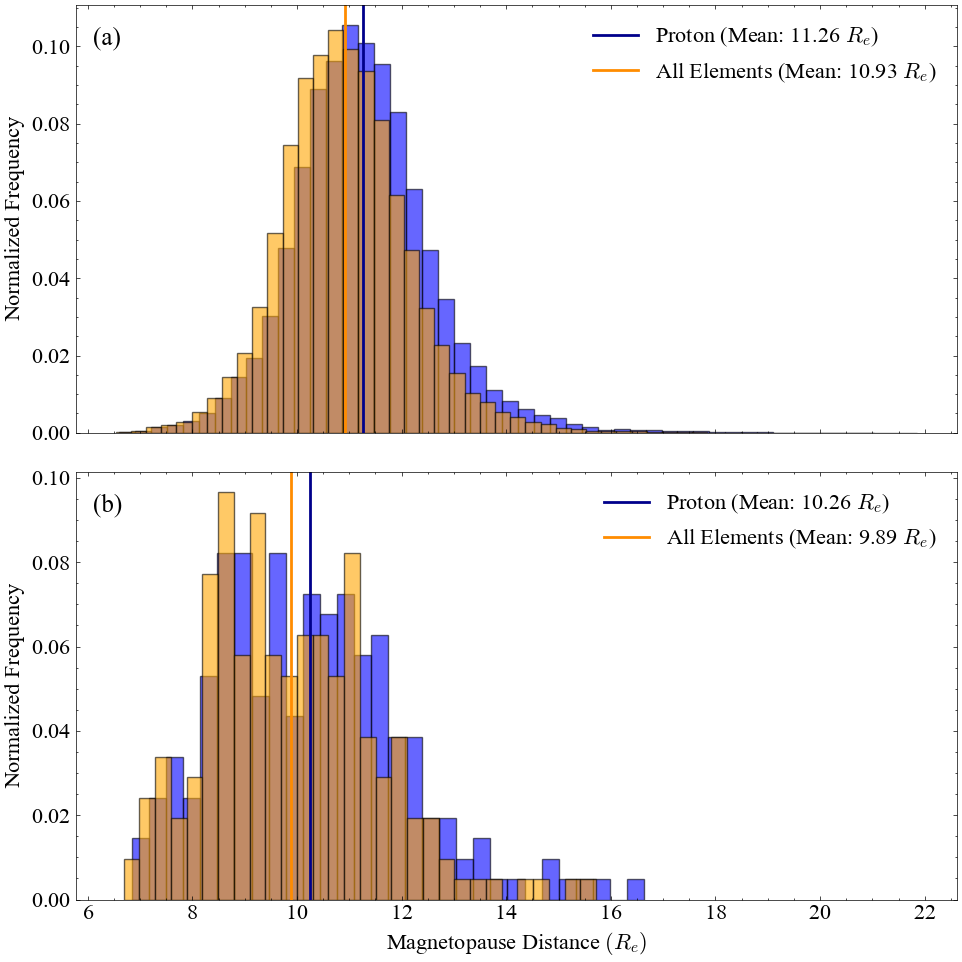

In [46]:
# Calculating the means
mean_proton_only = np.mean(proton_only_L_mp_distances)
mean_combined = np.mean(combined_L_mp_distances)
mean_proton_only_ICMEs = np.mean(proton_only_L_mp_distances_ICMEs)
mean_combined_ICMEs = np.mean(combined_L_mp_distances_ICMEs)

# Normalizing weights
weights_proton_only = np.ones_like(proton_only_L_mp_distances) / len(proton_only_L_mp_distances)
weights_combined = np.ones_like(combined_L_mp_distances) / len(combined_L_mp_distances)
weights_proton_only_ICMEs = np.ones_like(proton_only_L_mp_distances_ICMEs) / len(proton_only_L_mp_distances_ICMEs)
weights_combined_ICMEs = np.ones_like(combined_L_mp_distances_ICMEs) / len(combined_L_mp_distances_ICMEs)

# Plotting the histograms
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Subplot 1: Entire Time Range (1999-2005)
ax1.hist(proton_only_L_mp_distances, bins=50, alpha=0.6, color='blue', edgecolor='black', weights=weights_proton_only)
ax1.hist(combined_L_mp_distances, bins=50, alpha=0.6, color='orange', edgecolor='black', weights=weights_combined)

# vertical lines for the means
ax1.axvline(mean_proton_only, color='darkblue', linestyle='-', linewidth=2, label=f'Proton (Mean: {mean_proton_only:.2f} $R_e$)')
ax1.axvline(mean_combined, color='darkorange', linestyle='-', linewidth=2, label=f'All Elements (Mean: {mean_combined:.2f} $R_e$)')

# Adding labels and title
ax1.set_ylabel('Normalized Frequency', fontsize=16)
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, fontsize=18, verticalalignment='top')
ax1.legend(loc='upper right', fontsize=16)
# ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Subplot 2: ICMEs (1999-2005)
ax2.hist(proton_only_L_mp_distances_ICMEs, bins=30, alpha=0.6, color='blue', edgecolor='black', weights=weights_proton_only_ICMEs)
ax2.hist(combined_L_mp_distances_ICMEs, bins=30, alpha=0.6, color='orange', edgecolor='black', weights=weights_combined_ICMEs)

# vertical lines for the means
ax2.axvline(mean_proton_only_ICMEs, color='darkblue', linestyle='-', linewidth=2, label=f'Proton (Mean: {mean_proton_only_ICMEs:.2f} $R_e$)')
ax2.axvline(mean_combined_ICMEs, color='darkorange', linestyle='-', linewidth=2, label=f'All Elements (Mean: {mean_combined_ICMEs:.2f} $R_e$)')

# Adding labels and title
ax2.set_xlabel(r'Magnetopause Distance $(R_e)$', fontsize=16)
ax2.set_ylabel('Normalized Frequency', fontsize=16)
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, fontsize=18, verticalalignment='top')
ax2.legend(loc='upper right', fontsize=16)
# ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust layout
plt.tight_layout()

# Saving figure
# plt.savefig("./Plots/Combined_Magnetopause_Distances.png", format="png", dpi=300)

# Show the plot
plt.show()

C:\Users\firet\anaconda3\Lib\site-packages\spacepy\seapy.py:82: UserWarning: Input time not contiguous; results are unlikely to be valid.
  warnings.warn('Input time not {}; results are unlikely to be valid.'.format(
C:\Users\firet\anaconda3\Lib\site-packages\spacepy\seapy.py:103: UserWarning: Window size changed to 240.0 (points) to fit resolution (2.28311e-05)
  warnings.warn(


time is serial
sea(): 1 out-of-range epochs moved to badepochs attribute
sea(): datacube added as new attribute
Superposed epoch analysis complete


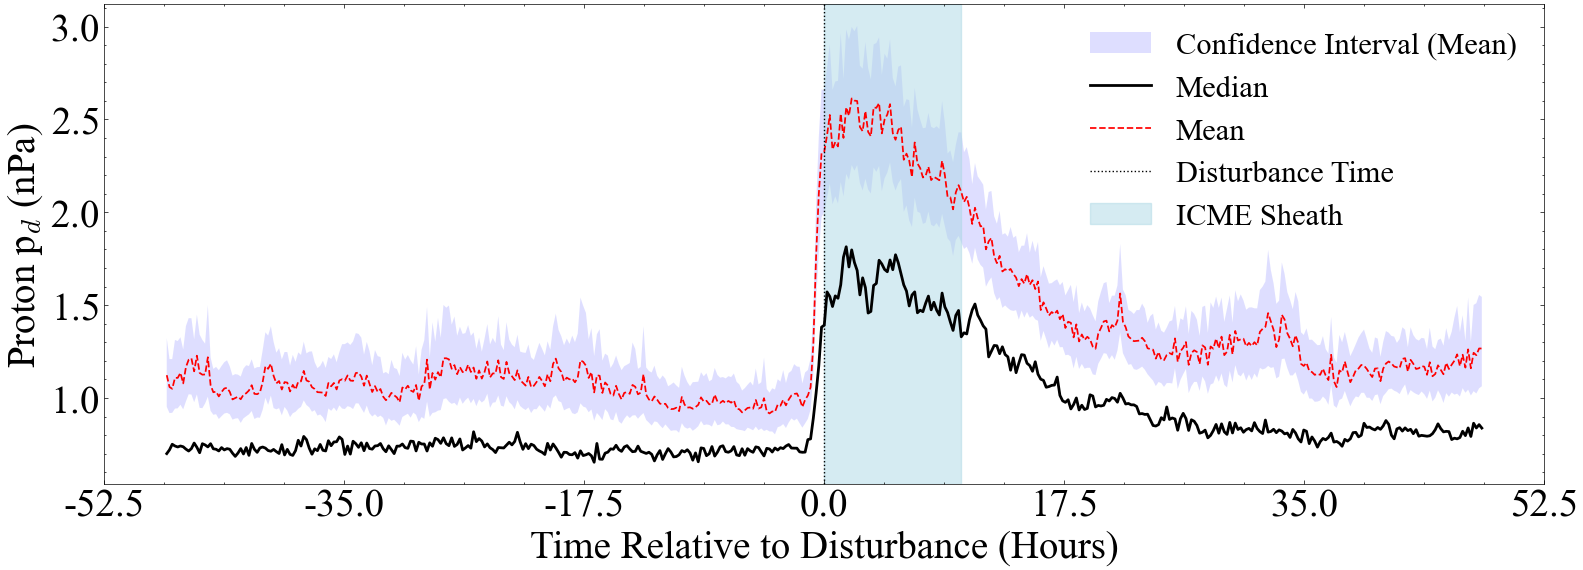

In [47]:
# Extract times and data
times = proton_info_1999_2005[:, 0]
data = proton_dyn_pressure / 1e-9

# Create Sea object
sea_obj = seapy.Sea(data, times, adjusted_days_1999_2005, window=48*0.000114, delta=0.0000228311) # delta = 12 min

# Perform SEA with quartiles and confidence intervals
sea_obj.sea(quartiles=True, ci=True, ci_quan='mean')

# Plot 
sea_obj.plot(xquan='Time Relative to Disturbance (Hours)', yquan=r'Proton p$_d$ (nPa)', epochline=True, figsize=(18, 6), show=False)

# Set the x-axis ticks and labels to hours
ax = plt.gca()
original_ticks = ax.get_xticks()  # Get the current tick positions in original units (days)
new_ticks = original_ticks / 0.000114255  # Convert these positions to hours
ax.set_xticks(original_ticks)
ax.set_xticklabels([f'{tick:.1f}' for tick in new_ticks])  # Format the labels to one decimal place

# print(sea_obj.x)

# Ensure the limits of the plot include all relevant data
ax.set_xlim([original_ticks[1], original_ticks[-2]])

ax.axvspan(0*.000114, 10*.000114, color='lightblue', alpha=0.5, label = 'ICME Sheath')
# ax.axvline(x=-2*.000114, color = 'black', linestyle = '--')
# ax.axvline(x=8*.000114, color = 'black', linestyle = '--')

ax.set_ylabel(r'Proton p$_d$ (nPa)', fontsize=28)
ax.set_xlabel(r'Time Relative to Disturbance (Hours)', fontsize=28)
ax.tick_params(axis='both', labelsize=28)

# Adjust plot margins if necessary to prevent cutting off
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Add legend
plt.legend(['Confidence Interval (Mean)', 'Median', 'Mean', 'Disturbance Time', 'ICME Sheath'], loc='best', fontsize = 22)

plt.savefig("./Plots/Superposed Proton Dynamic Pressure.png", format="png", dpi=300)

# Show plot
plt.show()

In [48]:
# Extract the times and averaged SEA data from the Sea object
plot_times = sea_obj.x / 0.000114255  # Convert x-values to hours
plot_data = sea_obj.semean  # Averaged proton dynamic pressure (y-axis)

# Find the maximum value in the SEA plot data
max_value = np.max(plot_data)

# Calculate the half maximum
half_max = max_value / 2.0

# Find indices where data crosses half max
indices_above = np.where(plot_data >= half_max)[0]
indices_below = np.where(plot_data <= half_max)[0]

# Modify the left_index to get the last index before the jump to a higher index
left_index = indices_below[np.where(indices_below < indices_above[0])][-1]

# Modify the right_index to get the first index where a significant jump occurs
# Look for the first significant "jump" to a much lower value
for i in range(1, len(indices_above)):
    if indices_above[i] - indices_above[i-1] > 1:  # Detect a jump
        right_index = indices_above[i-1]
        break

# Debugging prints
# print(indices_below)
# print(indices_above)
# print(left_index)
# print(right_index)

# Interpolate to find precise x-values where y equals half max
left_interp_func = interp1d(plot_data[left_index:left_index + 2], plot_times[left_index:left_index + 2], kind='linear')
right_interp_func = interp1d(plot_data[right_index:right_index + 2], plot_times[right_index:right_index + 2], kind='linear')

left_half_max_time = left_interp_func(half_max)
right_half_max_time = right_interp_func(half_max)

# Print the interpolated times
print(f"Left half-max time: {left_half_max_time}")
print(f"Right half-max time: {right_half_max_time}")

# Calculate FWHM
fwhm = right_half_max_time - left_half_max_time

print(f"The FWHM is {fwhm} hours.")

# Double-check: Print the interpolated values at the half-max times
left_half_max_value = np.interp(left_half_max_time, plot_times, plot_data)
right_half_max_value = np.interp(right_half_max_time, plot_times, plot_data)

print(f"Max Value: {max_value}")
print(f"Interpolated value at left half-max time: {left_half_max_value}")
print(f"Interpolated value at right half-max time: {right_half_max_value}")

Left half-max time: -0.7925425400625128
Right half-max time: 18.58021145424928
The FWHM is 19.372753994311793 hours.
Max Value: 2.6125743241894797
Interpolated value at left half-max time: 1.30628716209474
Interpolated value at right half-max time: 1.3062871620947396


time is serial
sea(): 1 out-of-range epochs moved to badepochs attribute


C:\Users\firet\anaconda3\Lib\site-packages\spacepy\seapy.py:82: UserWarning: Input time not contiguous; results are unlikely to be valid.
  warnings.warn('Input time not {}; results are unlikely to be valid.'.format(
C:\Users\firet\anaconda3\Lib\site-packages\spacepy\seapy.py:103: UserWarning: Window size changed to 24.0 (points) to fit resolution (0.000228311)
  warnings.warn(


sea(): datacube added as new attribute
Superposed epoch analysis complete


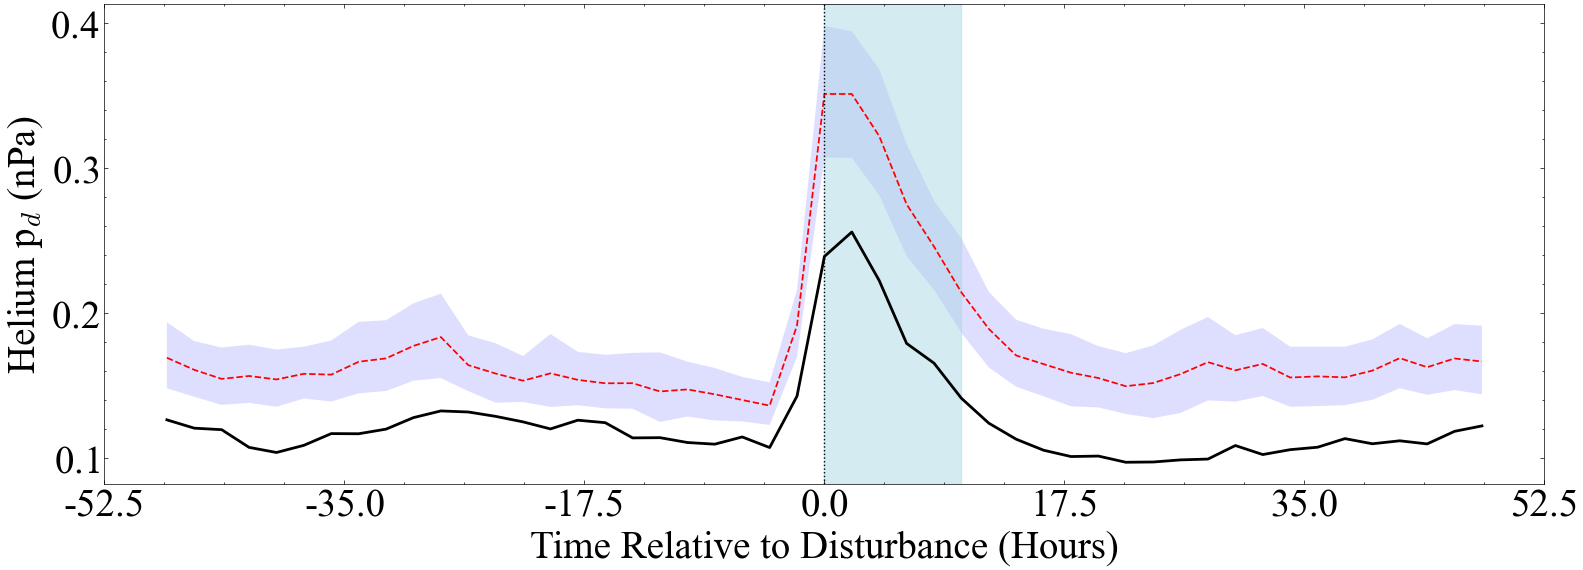

In [49]:
# Extract times and data
times = ace_data_1999_2005[:,0]
data = He_dyn_pressure / 1e-9

# Create Sea object
sea_obj = seapy.Sea(data, times, adjusted_days_1999_2005, window=48*0.000114, delta=0.000228311) # delta = 2 hrs

# Perform SEA with quartiles and confidence intervals
sea_obj.sea(quartiles=True, ci=True, ci_quan='mean')

# Plot with additional customizations
sea_obj.plot(xquan='Time Relative to Disturbance', yquan=r'Helium p$_d$ (nPa)', epochline=True, figsize=(18, 6), show=False)

# Set the x-axis ticks and labels to hours
ax = plt.gca()
original_ticks = ax.get_xticks()  # Get the current tick positions in original units (days)
new_ticks = original_ticks / 0.000114255  # Convert these positions to hours
ax.set_xticks(original_ticks)
ax.set_xticklabels([f'{tick:.1f}' for tick in new_ticks])  # Format the labels to one decimal place

# Ensure the limits of the plot include all relevant data
ax.set_xlim([original_ticks[1], original_ticks[-2]])

ax.axvspan(0*.000114, 10*.000114, color='lightblue', alpha=0.5, label = 'ICME Sheath')

ax.set_ylabel(r'Helium p$_d$ (nPa)', fontsize=28)
ax.set_xlabel(r'Time Relative to Disturbance (Hours)', fontsize=28)
ax.tick_params(axis='both', labelsize=28)

# Adjust plot margins if necessary to prevent cutting off
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Add legend
# plt.legend(['Confidence Interval (Mean)', 'Median', 'Mean', 'Disturbance Time'])

plt.savefig("./Plots/Superposed He Dynamic Pressure.png", format="png", dpi = 300)

# Show plot
plt.show()

In [50]:
# Extract the times and averaged SEA data from the Sea object
plot_times = sea_obj.x / 0.000114255  # Convert x-values to hours
plot_data = sea_obj.semean  # Averageddynamic pressure (y-axis)

# Find the maximum value in the SEA plot data
max_value = np.max(plot_data)

# Calculate the half maximum
half_max = max_value / 2.0

# Find indices where data crosses half max
indices_above = np.where(plot_data >= half_max)[0]
indices_below = np.where(plot_data <= half_max)[0]

# Modify the left_index to get the last index before the jump to a higher index
left_index = indices_below[np.where(indices_below < indices_above[0])][-1]

# Modify the right_index to get the first index where a significant jump occurs
# Look for the first significant "jump" to a much lower value
for i in range(1, len(indices_above)):
    if indices_above[i] - indices_above[i-1] > 1:  # Detect a jump
        right_index = indices_above[i-1]
        break
        
left_index = 22 # Doing this manually
right_index = 30

# Debugging prints
# print(indices_below)
# print(indices_above)
# print(left_index)
# print(right_index)

# Interpolate to find precise x-values where y equals half max
left_interp_func = interp1d(plot_data[left_index:left_index + 2], plot_times[left_index:left_index + 2], kind='linear')
right_interp_func = interp1d(plot_data[right_index:right_index + 2], plot_times[right_index:right_index + 2], kind='linear')

left_half_max_time = left_interp_func(half_max)
right_half_max_time = right_interp_func(half_max)

# Print the interpolated times
print(f"Left half-max time: {left_half_max_time}")
print(f"Right half-max time: {right_half_max_time}")

# Calculate FWHM
fwhm = right_half_max_time - left_half_max_time

print(f"The FWHM is {fwhm} hours.")

# Double-check: Print the interpolated values at the half-max times
left_half_max_value = np.interp(left_half_max_time, plot_times, plot_data)
right_half_max_value = np.interp(right_half_max_time, plot_times, plot_data)

print(f"Max Value: {max_value}")
print(f"Interpolated value at left half-max time: {left_half_max_value}")
print(f"Interpolated value at right half-max time: {right_half_max_value}")

Left half-max time: -2.569510666604586
Right half-max time: 13.456859396943784
The FWHM is 16.02637006354837 hours.
Max Value: 0.3510161282714897
Interpolated value at left half-max time: 0.17550806413574485
Interpolated value at right half-max time: 0.17550806413574485


time is serial
sea(): 1 out-of-range epochs moved to badepochs attribute


C:\Users\firet\anaconda3\Lib\site-packages\spacepy\seapy.py:82: UserWarning: Input time not contiguous; results are unlikely to be valid.
  warnings.warn('Input time not {}; results are unlikely to be valid.'.format(
C:\Users\firet\anaconda3\Lib\site-packages\spacepy\seapy.py:103: UserWarning: Window size changed to 24.0 (points) to fit resolution (0.000228311)
  warnings.warn(


sea(): datacube added as new attribute
Superposed epoch analysis complete


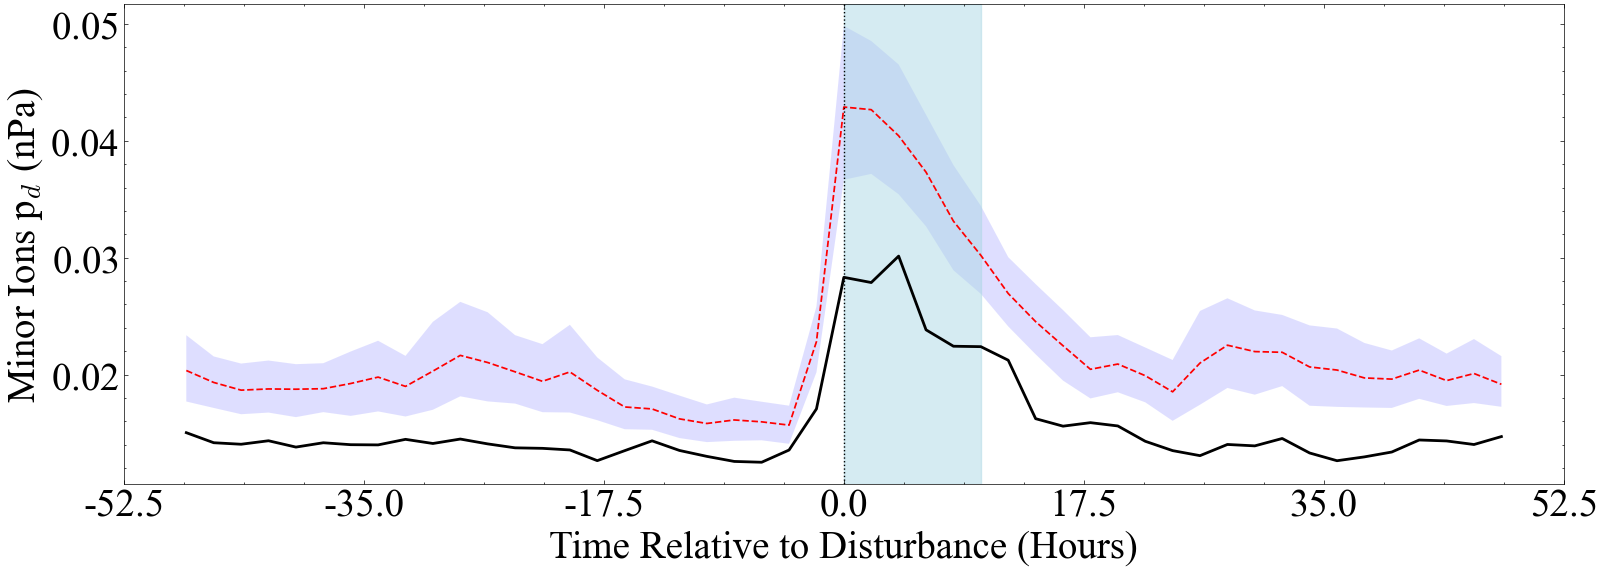

In [51]:
# Extract times and data
times = ace_data_1999_2005[:,0]
data = (heavy_elements_dyn_pressure - He_dyn_pressure) / 1e-9

# Create Sea object
sea_obj = seapy.Sea(data, times, adjusted_days_1999_2005, window=48*0.000114, delta=0.000228311) # delta = 2 hrs

# Perform SEA with quartiles and confidence intervals
sea_obj.sea(quartiles=True, ci=True, ci_quan='mean')

# Plot with additional customizations
sea_obj.plot(xquan='Time Relative to Disturbance', yquan=r'Minor Ions p$_d$ (nPa)', epochline=True, figsize=(18, 6), show=False)

# Set the x-axis ticks and labels to hours
ax = plt.gca()
original_ticks = ax.get_xticks()  # Get the current tick positions in original units (days)
new_ticks = original_ticks / 0.000114255  # Convert these positions to hours
ax.set_xticks(original_ticks)
ax.set_xticklabels([f'{tick:.1f}' for tick in new_ticks])  # Format the labels to one decimal place

# Ensure the limits of the plot include all relevant data
ax.set_xlim([original_ticks[1], original_ticks[-2]])

ax.axvspan(0*.000114, 10*.000114, color='lightblue', alpha=0.5, label = 'ICME Sheath')

ax.set_ylabel(r'Minor Ions p$_d$ (nPa)', fontsize=28)
ax.set_xlabel(r'Time Relative to Disturbance (Hours)', fontsize=28)
ax.tick_params(axis='both', labelsize=28)

# Adjust plot margins if necessary to prevent cutting off
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Add legend
# plt.legend(['Confidence Interval (Mean)', 'Median', 'Mean', 'Disturbance Time'])

plt.savefig("./Plots/Superposed Heavy Element Dynamic Pressure.png", format="png", dpi = 300)

# Show plot
plt.show()

In [52]:
# Sheath Calculations
interp_proton_dyn_pressure_sheath_array = np.concatenate(interp_proton_ICMEs_dyn_pressure_clean_sheath_values)
He_dyn_pressure_sheath_array = np.concatenate(He_ICMEs_dyn_pressure_clean_sheath_values)
heavy_ion_dyn_pressure_sheath_array = np.concatenate(heavy_ion_ICMEs_dyn_pressure_clean_sheath_values)

he_proton_dyn_pressure_ratio_sheath = He_ICMEs_dyn_pressure_clean_sheath_values/interp_proton_ICMEs_dyn_pressure_clean_sheath_values
he_proton_dyn_pressure_ratio_sheath_array = np.concatenate(he_proton_dyn_pressure_ratio_sheath)

heavy_ion_proton_dyn_pressure_ratio_sheath = (heavy_ion_ICMEs_dyn_pressure_clean_sheath_values - He_ICMEs_dyn_pressure_clean_sheath_values)/interp_proton_ICMEs_dyn_pressure_clean_sheath_values
heavy_ion_proton_dyn_pressure_ratio_sheath_array = np.concatenate(heavy_ion_proton_dyn_pressure_ratio_sheath)

# Non-Sheath Calculations
interp_proton_dyn_pressure_non_sheath_array = np.concatenate(interp_proton_ICMEs_dyn_pressure_clean_non_sheath_values)
He_dyn_pressure_non_sheath_array = np.concatenate(He_ICMEs_dyn_pressure_clean_non_sheath_values)
heavy_ion_dyn_pressure_non_sheath_array = np.concatenate(heavy_ion_ICMEs_dyn_pressure_clean_non_sheath_values)

he_proton_dyn_pressure_ratio_non_sheath = He_ICMEs_dyn_pressure_clean_non_sheath_values / interp_proton_ICMEs_dyn_pressure_clean_non_sheath_values
he_proton_dyn_pressure_ratio_non_sheath_array = np.concatenate(he_proton_dyn_pressure_ratio_non_sheath)

heavy_ion_proton_dyn_pressure_ratio_non_sheath = (heavy_ion_ICMEs_dyn_pressure_clean_non_sheath_values - He_ICMEs_dyn_pressure_clean_non_sheath_values) / interp_proton_ICMEs_dyn_pressure_clean_non_sheath_values
heavy_ion_proton_dyn_pressure_ratio_non_sheath_array = np.concatenate(heavy_ion_proton_dyn_pressure_ratio_non_sheath)

# Non-ICME calculations
interp_proton_dyn_pressure_non_icme_array = np.concatenate(interp_proton_ICMEs_dyn_pressure_clean_non_icme_values)
He_dyn_pressure_non_icme_array = np.concatenate(He_ICMEs_dyn_pressure_clean_non_icme_values)
heavy_ion_dyn_pressure_non_icme_array = np.concatenate(heavy_ion_ICMEs_dyn_pressure_clean_non_icme_values)

he_proton_dyn_pressure_ratio_non_icme = He_ICMEs_dyn_pressure_clean_non_icme_values / interp_proton_ICMEs_dyn_pressure_clean_non_icme_values
he_proton_dyn_pressure_ratio_non_icme_array = np.concatenate(he_proton_dyn_pressure_ratio_non_icme)

heavy_ion_proton_dyn_pressure_ratio_non_icme = (heavy_ion_ICMEs_dyn_pressure_clean_non_icme_values - He_ICMEs_dyn_pressure_clean_non_icme_values) / interp_proton_ICMEs_dyn_pressure_clean_non_icme_values
heavy_ion_proton_dyn_pressure_ratio_non_icme_array = np.concatenate(heavy_ion_proton_dyn_pressure_ratio_non_icme)

In [53]:
# Function to normalize histograms and handle NaNs
def normalize_hist(array, bins):
    # Remove NaN values
    array = array[~np.isnan(array)]
    counts, bin_edges = np.histogram(array, bins=bins)
    return counts / counts.sum(), bin_edges

In [54]:
interp_proton_ICMEs_dyn_pressure_sheath_array = np.concatenate(interp_proton_ICMEs_dyn_pressure_clean_sheath_values)
heavy_ion_ICMEs_dyn_pressure_sheath_array = np.concatenate(heavy_ion_ICMEs_dyn_pressure_clean_sheath_values)

interp_proton_ICMEs_dyn_pressure_non_sheath_array = np.concatenate(interp_proton_ICMEs_dyn_pressure_clean_non_sheath_values)
heavy_ion_ICMEs_dyn_pressure_non_sheath_array = np.concatenate(heavy_ion_ICMEs_dyn_pressure_clean_non_sheath_values)

interp_proton_ICMEs_dyn_pressure_non_icme_array = np.concatenate(interp_proton_ICMEs_dyn_pressure_clean_non_icme_values)
heavy_ion_ICMEs_dyn_pressure_non_icme_array = np.concatenate(heavy_ion_ICMEs_dyn_pressure_clean_non_icme_values)

In [55]:
def calculate_magnetopause_distances(label, proton_array, heavy_ion_array):
    combined_distances = []
    proton_only_distances = []
    indices_array = list(range(len(proton_array)))
    
    for idx in indices_array:
        combined_distances.append(L_mp_equation_dyn_pressure(proton_array + heavy_ion_array))
        proton_only_distances.append(L_mp_equation_dyn_pressure(proton_array))
    
    avg_combined = np.nanmean(combined_distances)
    avg_proton_only = np.nanmean(proton_only_distances)
    std_combined = np.nanstd(combined_distances)
    std_proton_only = np.nanstd(proton_only_distances)
    decrease = avg_proton_only - avg_combined
    percentage_decrease = (decrease / avg_proton_only) * 100
    
    print(f'Average Combined Magnetopause Distance ({label}) (r_earth):', avg_combined)
    print(f'Average Proton-Only Magnetopause Distance ({label}) (r_earth):', avg_proton_only)
    print(f'Standard Deviation of Combined Magnetopause Distance ({label}) (r_earth):', std_combined)
    print(f'Standard Deviation of Proton-Only Magnetopause Distance ({label}) (r_earth):', std_proton_only)
    print(f'Decrease in Magnetopause Distance when Including Heavy Ions: {decrease:.3f} r_earth')
    print(f'Percentage Decrease: {percentage_decrease:.2f}%')
    print(len(combined_distances))

    return np.array(combined_distances), np.array(proton_only_distances)

# Calling the function for different conditions
sheath_combined, sheath_proton_only = calculate_magnetopause_distances("1999-2005 Sheath", interp_proton_ICMEs_dyn_pressure_sheath_array, heavy_ion_ICMEs_dyn_pressure_sheath_array)
non_sheath_combined, non_sheath_proton_only = calculate_magnetopause_distances("1999-2005 Non-Sheath", interp_proton_ICMEs_dyn_pressure_non_sheath_array, heavy_ion_ICMEs_dyn_pressure_non_sheath_array)
non_icme_combined, non_icme_proton_only = calculate_magnetopause_distances("1999-2005 Non-ICME", interp_proton_ICMEs_dyn_pressure_non_icme_array, heavy_ion_ICMEs_dyn_pressure_non_icme_array)

Average Combined Magnetopause Distance (1999-2005 Sheath) (r_earth): 9.619566536335208
Average Proton-Only Magnetopause Distance (1999-2005 Sheath) (r_earth): 9.942450376640458
Standard Deviation of Combined Magnetopause Distance (1999-2005 Sheath) (r_earth): 1.357565392268939
Standard Deviation of Proton-Only Magnetopause Distance (1999-2005 Sheath) (r_earth): 1.50670159797932
Decrease in Magnetopause Distance when Including Heavy Ions: 0.323 r_earth
Percentage Decrease: 3.25%
866
Average Combined Magnetopause Distance (1999-2005 Non-Sheath) (r_earth): 10.809163797666917
Average Proton-Only Magnetopause Distance (1999-2005 Non-Sheath) (r_earth): 11.122650819273362
Standard Deviation of Combined Magnetopause Distance (1999-2005 Non-Sheath) (r_earth): 1.558292934064469
Standard Deviation of Proton-Only Magnetopause Distance (1999-2005 Non-Sheath) (r_earth): 1.76106331067761
Decrease in Magnetopause Distance when Including Heavy Ions: 0.313 r_earth
Percentage Decrease: 2.82%
3402
Average

7054
7054


C:\Users\firet\AppData\Local\Temp\ipykernel_8408\3745929442.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


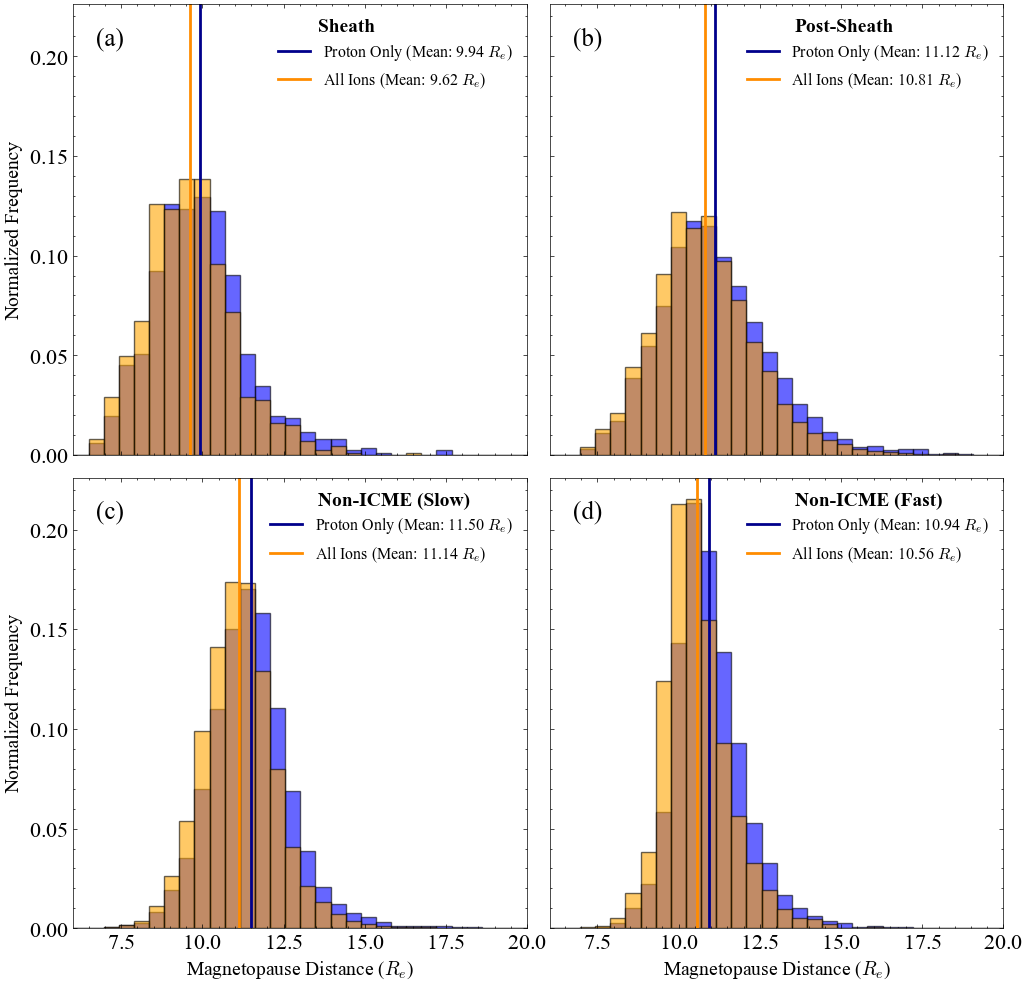

In [56]:
# Sheath
mean_proton_only_sheath = np.nanmean(sheath_proton_only[0])
mean_combined_sheath = np.nanmean(sheath_combined[0])
weights_proton_only_sheath = np.ones_like(sheath_proton_only[0]) / len(sheath_proton_only[0])
weights_combined_sheath = np.ones_like(sheath_combined[0]) / len(sheath_combined[0])

# Post-sheath
mean_proton_only_non_sheath = np.nanmean(non_sheath_proton_only[0])
mean_combined_non_sheath = np.nanmean(non_sheath_combined[0])
weights_proton_only_non_sheath = np.ones_like(non_sheath_proton_only[0]) / len(non_sheath_proton_only[0])
weights_combined_non_sheath = np.ones_like(non_sheath_combined[0]) / len(non_sheath_combined[0])

# Non-ICME Split
speed_threshold = 500000  # m/s
slow_mask = proton_interp_ICMEs_vel_clean_non_icme_values[0] < speed_threshold
fast_mask = proton_interp_ICMEs_vel_clean_non_icme_values[0] >= speed_threshold

non_icme_proton_only_slow = non_icme_proton_only[0][slow_mask]
non_icme_proton_only_fast = non_icme_proton_only[0][fast_mask]
non_icme_combined_slow = non_icme_combined[0][slow_mask]
non_icme_combined_fast = non_icme_combined[0][fast_mask]

mean_proton_only_slow = np.nanmean(non_icme_proton_only_slow)
mean_proton_only_fast = np.nanmean(non_icme_proton_only_fast)
mean_combined_slow = np.nanmean(non_icme_combined_slow)
mean_combined_fast = np.nanmean(non_icme_combined_fast)

weights_proton_only_slow = np.ones_like(non_icme_proton_only_slow) / len(non_icme_proton_only_slow)
weights_combined_slow = np.ones_like(non_icme_combined_slow) / len(non_icme_combined_slow)
weights_proton_only_fast = np.ones_like(non_icme_proton_only_fast) / len(non_icme_proton_only_fast)
weights_combined_fast = np.ones_like(non_icme_combined_fast) / len(non_icme_combined_fast)

# --- Gather all data to find global x limits ---
all_values = np.concatenate([
    sheath_proton_only[0], sheath_combined[0],
    non_sheath_proton_only[0], non_sheath_combined[0],
    non_icme_proton_only_slow, non_icme_combined_slow,
    non_icme_proton_only_fast, non_icme_combined_fast
])

x_min, x_max = np.nanmin(all_values), np.nanmax(all_values)
x_pad = 0.5
x_lim = (x_min - x_pad, 20)
bins = np.linspace(x_lim[0], x_lim[1], 31)  # 30 uniform bins

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True,
                         gridspec_kw={'hspace': 0.05, 'wspace': 0.05})

subplot_labels = ['(a)', '(b)', '(c)', '(d)']
data_groups = [
    (sheath_proton_only[0], sheath_combined[0], weights_proton_only_sheath, weights_combined_sheath, mean_proton_only_sheath, mean_combined_sheath),
    (non_sheath_proton_only[0], non_sheath_combined[0], weights_proton_only_non_sheath, weights_combined_non_sheath, mean_proton_only_non_sheath, mean_combined_non_sheath),
    (non_icme_proton_only_slow, non_icme_combined_slow, weights_proton_only_slow, weights_combined_slow, mean_proton_only_slow, mean_combined_slow),
    (non_icme_proton_only_fast, non_icme_combined_fast, weights_proton_only_fast, weights_combined_fast, mean_proton_only_fast, mean_combined_fast),
]

for i, ax in enumerate(axes.flat):
    p_data, c_data, p_weights, c_weights, p_mean, c_mean = data_groups[i]

    ax.hist(p_data, bins=bins, alpha=0.6, color='blue', edgecolor='black', weights=p_weights)
    ax.hist(c_data, bins=bins, alpha=0.6, color='orange', edgecolor='black', weights=c_weights)

    ax.axvline(p_mean, color='darkblue', linestyle='-', linewidth=2,
               label=f'Proton Only (Mean: {p_mean:.2f} $R_e$)')
    ax.axvline(c_mean, color='darkorange', linestyle='-', linewidth=2,
               label=f'All Ions (Mean: {c_mean:.2f} $R_e$)')

    ax.text(0.05, 0.95, subplot_labels[i], transform=ax.transAxes,
            fontsize=18, verticalalignment='top')

    ax.set_xlim(x_lim)

    # Add region label (sheath, post-sheath, etc.)
    region_labels = ["Sheath", "Post-Sheath", "Non-ICME (Slow)", "Non-ICME (Fast)"]
    ax.text(0.54, 0.97, region_labels[i],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='semibold',
            color='black',
            verticalalignment='top')

    if i in [2, 3]:
        ax.set_xlabel('Magnetopause Distance ($R_e$)', fontsize=14)
    if i in [0, 2]:
        ax.set_ylabel('Normalized Frequency', fontsize=14)
    ax.legend(loc='upper right', bbox_to_anchor=(1, 0.95), fontsize=11.5)

print(len(non_icme_proton_only_fast))
print(len(non_icme_combined_fast))

plt.tight_layout()
plt.savefig("./Plots/Dynamic_Pressure_Ratio_Histograms_Updated.png", format="png", dpi=300)
plt.show()

In [57]:
percentage_decreases = []
for group in data_groups:
    p_mean = group[4]
    c_mean = group[5]
    percent_decrease = ((p_mean - c_mean) / p_mean) * 100
    percentage_decreases.append(percent_decrease)

labels = ['Sheath', 'Post-sheath', 'Non-ICME (Slow)', 'Non-ICME (Fast)']

for label, percent in zip(labels, percentage_decreases):
    print(f"{label}: {percent:.2f}% decrease in mean magnetopause distance")

Sheath: 3.25% decrease in mean magnetopause distance
Post-sheath: 2.82% decrease in mean magnetopause distance
Non-ICME (Slow): 3.13% decrease in mean magnetopause distance
Non-ICME (Fast): 3.55% decrease in mean magnetopause distance


In [59]:
# --- Gather every value in ONE array per population -------------------------
all_proton_only = np.concatenate([
    sheath_proton_only[0],
    non_sheath_proton_only[0],
    non_icme_proton_only_slow,
    non_icme_proton_only_fast
])

all_all_ions = np.concatenate([
    sheath_combined[0],
    non_sheath_combined[0],
    non_icme_combined_slow,
    non_icme_combined_fast
])

# --- Global means (NaNs ignored) --------------------------------------------
global_mean_proton_only = np.nanmean(all_proton_only)
global_mean_all_ions   = np.nanmean(all_all_ions)

print(f"Global mean – Proton only : {global_mean_proton_only:.3f} R_e")
print(f"Global mean – All ions    : {global_mean_all_ions:.3f} R_e")

Global mean – Proton only : 11.283 R_e
Global mean – All ions    : 10.921 R_e


In [69]:
# ------------------- configurable parameters -------------------
np.random.seed(48)       # for reproducibility
sample_frac = 0.50       # 0 < sample_frac ≤ 1  (1.0 → use every pair)
alpha       = 0.05       # significance level
# ---------------------------------------------------------------

regions = {
    "Sheath"           : (sheath_proton_only[0]      , sheath_combined[0]),
    "Post-Sheath"      : (non_sheath_proton_only[0]  , non_sheath_combined[0]),
    "Non-ICME (Slow)"  : (non_icme_proton_only_slow  , non_icme_combined_slow),
    "Non-ICME (Fast)"  : (non_icme_proton_only_fast  , non_icme_combined_fast),
}

results = []

for name, (p_only, combined) in regions.items():
    # 1. Remove any rows where either series is NaN (keeps pairs aligned)
    mask          = (~np.isnan(p_only)) & (~np.isnan(combined))
    p_only_clean  = p_only[mask]
    comb_clean    = combined[mask]

    # 2. Optional random subsample
    if 0 < sample_frac < 1.0:
        n          = len(p_only_clean)
        k          = int(np.floor(sample_frac * n))
        idx        = np.random.choice(n, k, replace=False)
        p_only_used = p_only_clean[idx]
        comb_used   = comb_clean[idx]
    else:
        p_only_used = p_only_clean
        comb_used   = comb_clean

    # 3. Paired t-test
    t_stat, p_val = stats.ttest_rel(p_only_used, comb_used)

    # 4. Mean difference & 95 % CI
    diff        = p_only_used - comb_used
    mean_diff   = np.mean(diff)
    se_diff     = stats.sem(diff)
    conf_int    = stats.t.interval(
        0.95, len(diff)-1, loc=mean_diff, scale=se_diff
    )

    # 6. Append to summary
    results.append({
        "Region"         : name,
        "N pairs"        : len(diff),
        "t-stat"         : f"{t_stat:.3f}",
        "p-value"        : f"{p_val:.3e}",
        "Mean Δ (Rₑ)"    : f"{mean_diff:.3f}",
        "95 % CI Δ"      : f"({conf_int[0]:.3f}, {conf_int[1]:.3f})",
        "Significant?"   : "Yes" if p_val < alpha else "No"
    })

# Print summary
summary = pd.DataFrame(results)
print("\nPaired t-test results (Proton-Only minus All-Ions):")
print(summary.to_string(index=False))


Paired t-test results (Proton-Only minus All-Ions):
         Region  N pairs  t-stat    p-value Mean Δ (Rₑ)      95 % CI Δ Significant?
         Sheath      412  21.839  9.543e-71       0.321 (0.292, 0.349)          Yes
    Post-Sheath     1596  38.490 8.656e-230       0.299 (0.284, 0.315)          Yes
Non-ICME (Slow)     9145 140.994  0.000e+00       0.333 (0.328, 0.338)          Yes
Non-ICME (Fast)     3503 100.893  0.000e+00       0.379 (0.372, 0.386)          Yes
